# Atopic Dermatitis: DEG Cleaning, Annotation & Meta-Analysis
## Cross-Species Transcriptomics Pipeline · Notebook 1+2 (Merged)

| Step | What happens |
|---|---|
| 0 | Mount Google Drive |
| 1 | Install libraries · configure paths & colours |
| 2 | Gene symbol filtering rules |
| 3 | Ensembl ID → Gene Symbol annotation (MyGene + Ensembl REST) |
| 4 | File reader · column standardisation · FC→log2FC conversion |
| 5 | Main ingestion loop (all 4 comparison folders, all file formats) |
| 6 | Save cleaned per-comparison CSVs + master table + Supplementary S1 (2-tab) |
| 7 | Per-dataset figures (Figs 1–6: counts, volcano, distribution, overlap) |
| 8 | Build wide-format p-value + log2FC matrices (in memory) |
| 9 | Vote-count meta-summary (Figs 7–10: heatmap, confidence, bubble, consistency) |
| 10 | **Fisher + Stouffer meta-analysis** (all 4 comparisons) |
| 11 | Meta-analysis figures (Figs 11–14: meta-volcano, ranked dots, forest, cross-species) |
| 12 | Save all meta results + final 5-tab Supplementary Excel |

**Expected Drive structure:**
```
My Drive/Research/Atopic Dermatitis/Research Paper/
├── Input Data/
│   ├── H_L_N/    ← Human Lesional vs Normal        (≥2 datasets)
│   ├── H_NL_N/   ← Human Non-Lesional vs Normal    (≥2 datasets)
│   ├── H_L_NL/   ← Human Lesional vs Non-Lesional  (≥2 datasets)
│   └── C_L_N/    ← Canine AD vs Healthy            (≥2 datasets)
└── Results/
    ├── cleaned_data/ · combined_data/ · meta_summary/ · figures/
```


## **Step 0 - Mount Google Drive**


In [9]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted successfully.')


Mounted at /content/drive
Google Drive mounted successfully.


## **Step 1 - Install Libraries, Configure Paths & Global Colours**

`mygene` → Ensembl annotation | `upsetplot` → UpSet diagrams | `scipy` / `statsmodels` → meta-analysis statistics

> **Only change `BASE`** if you move your data folder.


In [10]:
!pip install mygene upsetplot scipy statsmodels scikit-learn --quiet


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.9 MB/s eta 0:00:00


In [11]:
import pandas as pd
import numpy as np
import os, re, warnings, requests, time
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from collections import defaultdict
from scipy import stats
from statsmodels.stats.multitest import multipletests
import mygene
from upsetplot import from_memberships, plot as upset_plot

warnings.filterwarnings('ignore')

# ── Publication-quality figure defaults ──────────────────────
matplotlib.rcParams.update({
    'figure.dpi'       : 150,    # inline preview (lighter on Colab)
    'savefig.dpi'      : 300,    # all saved PNGs are 300 DPI
    'font.family'      : 'sans-serif',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 12,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# ── Colour palettes ───────────────────────────────────────────
PALETTE = {
    'Upregulated'  : '#D7263D',
    'Downregulated': '#1A85FF',
}
COMP_COLORS = {
    'Human_Lesional_vs_Normal'      : '#E63946',
    'Human_Nonlesional_vs_Normal'   : '#F4A261',
    'Human_Lesional_vs_Nonlesional' : '#2A9D8F',
    'Canine_AD_vs_Healthy'          : '#457B9D',
}
CONF_COLORS = {
    'High-confidence'    : '#1B4332',
    'Moderate-confidence': '#52B788',
    'Dataset-specific'   : '#95D5B2',
    'Conflicting'        : '#D62828',
    'Not-significant'    : '#cccccc',
}
TIER_ORDER = ['High-confidence','Moderate-confidence','Conflicting',
              'Not-significant','Dataset-specific']

# ── Paths ─────────────────────────────────────────────────────
BASE         = '/content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper'
IN_DIR       = os.path.join(BASE, 'Input Data')
RES          = os.path.join(BASE, 'Results')
DIR_CLEAN    = os.path.join(RES, 'cleaned_data')
DIR_COMBINED = os.path.join(RES, 'combined_data')
DIR_META     = os.path.join(RES, 'meta_summary')
# ── NB01 subfolder structure ──────────────────────────────────
NB01         = os.path.join(RES, 'NB01')
NB01_FIG     = os.path.join(NB01, 'Figures')
NB01_TAB     = os.path.join(NB01, 'Tables')
NB01_SUP     = os.path.join(NB01, 'Supplementary_Files')
# Legacy aliases (used by save_fig and other cells)
DIR_FIG      = NB01_FIG
DIR_CLEAN    = NB01_TAB
DIR_COMBINED = NB01_TAB
DIR_META     = os.path.join(RES, 'meta_summary')   # Shared intermediate — NOT inside NB01

for d in [RES, NB01_FIG, NB01_TAB, NB01_SUP, DIR_META]:
    os.makedirs(d, exist_ok=True)

# ── Comparison definitions ────────────────────────────────────
COMPARISONS = {
    'Human_Lesional_vs_Normal'      : {
        'folder': 'H_L_N',  'species': 'Homo sapiens',
        'short' : 'Human LN',
        'out'   : 'human_lesional_vs_normal_cleaned_DEGs.csv'},
    'Human_Nonlesional_vs_Normal'   : {
        'folder': 'H_NL_N', 'species': 'Homo sapiens',
        'short' : 'Human NLN',
        'out'   : 'human_nonlesional_vs_normal_cleaned_DEGs.csv'},
    'Human_Lesional_vs_Nonlesional' : {
        'folder': 'H_L_NL', 'species': 'Homo sapiens',
        'short' : 'Human LNL',
        'out'   : 'human_lesional_vs_nonlesional_cleaned_DEGs.csv'},
    'Canine_AD_vs_Healthy'          : {
        'folder': 'C_L_N',  'species': 'Canis lupus familiaris',
        'short' : 'Canine AD',
        'out'   : 'canine_AD_vs_healthy_cleaned_DEGs.csv'},
}

print('Paths configured:')
for k, v in COMPARISONS.items():
    fpath  = os.path.join(IN_DIR, v['folder'])
    exists = os.path.isdir(fpath)
    n_files= len([f for f in os.listdir(fpath)
                  if os.path.splitext(f)[1].lower() in
                  {'.txt','.csv','.tsv','.xlsx','.xls'}]) if exists else 0
    print(f"  {'✓' if exists else '✗ MISSING'} {k:<44} → {n_files} file(s)")
print('\nOutput subfolders ready under Results/')


Paths configured:
  ✓ Human_Lesional_vs_Normal                     → 8 file(s)
  ✓ Human_Nonlesional_vs_Normal                  → 2 file(s)
  ✓ Human_Lesional_vs_Nonlesional                → 8 file(s)
  ✓ Canine_AD_vs_Healthy                         → 7 file(s)

Output subfolders ready under Results/


## **Step 2 - Gene Symbol Filtering Rules**

- **Fully removed:** Excel date artefacts (`1-Mar`), multi-probe entries (`///`),
  Affymetrix controls (`AFFX-`), pure numeric IDs, StringTie loci (`XLOC`)
- **Kept in tables, excluded from all figures:** `LOC` genes, numbered ncRNAs (`LINC`, `MIR`, `SNOR`)
- **Ensembl IDs** (`ENSG...`): annotation attempted → annotated ones get their gene symbol;
  unannotated ones are kept in tables but excluded from figures


In [12]:
REMOVE_PATTERNS = [
    r'^\d{1,2}-[A-Za-z]{3}$',  # Excel date artefacts: 1-Mar, 14-Sep
    r'///',                       # Multi-probe: Gene1 /// Gene2
    r'^XLOC',                     # StringTie generic loci
    r'^G-\d',                   # Generic probe IDs
    r'^cOR',                      # Canine ORF entries
    r'^Cfa',                      # Canine array probe IDs
    r'^AFFX',                     # Affymetrix control probes
    r'^\d+$',                   # Pure numeric IDs
]

VIZ_EXCLUDE_PATTERNS = [
    r'^LOC\d',   # Uncharacterised loci — kept in data tables
    r'^LINC\d',  # Numbered long intergenic ncRNAs
    r'^MIR\d',   # Numbered microRNAs
    r'^SNOR\d',  # Small nucleolar RNAs
]

def is_removable(g):
    """Returns True if the gene symbol should be completely discarded."""
    g = str(g).strip()
    if not g or g.lower() in ('nan','none','n/a','na','','gene_symbol','symbol','gene'):
        return True
    for pat in REMOVE_PATTERNS:
        if re.search(pat, g, re.IGNORECASE):
            return True
    return False

def is_ensembl(g):
    """Returns True if the symbol looks like an Ensembl Gene ID."""
    return bool(re.match(r'^ENS[A-Z]*G\d{11}', str(g).strip(), re.IGNORECASE))

def exclude_from_viz(g):
    """Returns True if the gene should be excluded from visualizations only."""
    g = str(g).strip()
    if is_ensembl(g):
        return True
    for pat in VIZ_EXCLUDE_PATTERNS:
        if re.search(pat, g, re.IGNORECASE):
            return True
    return False

print('Gene filtering rules defined.')
print(f'  Full-removal patterns   : {len(REMOVE_PATTERNS)}')
print(f'  Viz-exclusion patterns  : {len(VIZ_EXCLUDE_PATTERNS)}')
print('  Ensembl IDs: annotation attempted; unannotated kept in tables only')


Gene filtering rules defined.
  Full-removal patterns   : 8
  Viz-exclusion patterns  : 4
  Ensembl IDs: annotation attempted; unannotated kept in tables only


## **Step 3 - Ensembl ID → Gene Symbol Annotation**

**Pass 1:** MyGene.info (fast batch, human + canine)  
**Pass 2:** Ensembl REST API fallback (batches of 200)  
Unresolved IDs are kept as-is and flagged `exclude_viz = True`.


In [13]:
mg = mygene.MyGeneInfo()

def annotate_ensembl_ids(ensembl_list, species='human'):
    """
    Map a list of Ensembl Gene IDs to gene symbols.
    Returns dict {ensembl_id: gene_symbol}.
    Unresolved IDs map to themselves (original ID preserved).
    """
    if not ensembl_list:
        return {}

    mapping   = {}
    remaining = list(set(ensembl_list))

    # Pass 1 — MyGene.info
    print(f'    MyGene: querying {len(remaining)} Ensembl IDs ({species})...')
    try:
        results = mg.querymany(
            remaining, scopes='ensembl.gene', fields='symbol',
            species=species, returnall=True, verbose=False)
        for hit in results.get('out', []):
            eid = hit.get('query', '')
            sym = hit.get('symbol', None)
            if sym and eid:
                mapping[eid] = sym.upper()
    except Exception as e:
        print(f'    MyGene failed: {e}')

    # Pass 2 — Ensembl REST API for anything still unmapped
    remaining2 = [e for e in remaining if e not in mapping]
    if remaining2:
        print(f'    Ensembl REST fallback: {len(remaining2)} IDs...')
        SERVER = 'https://rest.ensembl.org'
        for i in range(0, len(remaining2), 200):
            chunk = remaining2[i:i+200]
            try:
                r = requests.post(
                    f'{SERVER}/lookup/id',
                    headers={'Content-Type':'application/json','Accept':'application/json'},
                    json={'ids': chunk}, timeout=30)
                if r.status_code == 200:
                    for eid, info in r.json().items():
                        if isinstance(info, dict):
                            sym = info.get('display_name') or info.get('external_name')
                            if sym:
                                mapping[eid] = sym.upper()
                time.sleep(0.3)
            except Exception as e:
                print(f'    REST chunk failed: {e}')

    # Any still unmapped → preserve original ID
    for eid in remaining:
        if eid not in mapping:
            mapping[eid] = eid

    n_res   = sum(1 for k,v in mapping.items() if v != k)
    n_unres = sum(1 for k,v in mapping.items() if v == k)
    print(f'    Resolved: {n_res}  |  Kept as-is (unannotated): {n_unres}')
    return mapping

print('Ensembl annotation function defined.')


Ensembl annotation function defined.


## **Step 4 - File Reader, Column Standardisation & FC Conversion**

- Auto-detects `.txt`, `.csv`, `.tsv`, `.xlsx`, `.xls`
- Sniffs separator (tab vs comma) by peeking at the first line
- Maps any column name variant to `Gene_Symbol`, `log2FC`, `p_value`
- If >30% of |log2FC| values exceed 4 → assumed linear FC → converted to log2

> **If a file shows "MISSING COLS"**: look at the printed column list and add the exact
> column name as a new alias in `COL_ALIASES` below, then re-run from Step 4.


In [14]:
COL_ALIASES = {
    'Gene_Symbol' : ['gene_symbol','symbol','gene','genesymbol','gene_name','genename',
                     'id','gene_id','name','hgnc_symbol','mgi_symbol','gene.symbol',
                     'geneid','external_gene_name','gene_symbols','genes'],
    'log2FC'      : ['log2fc','log2_fc','logfc','log_fc','log2foldchange',
                     'log2fold_change','log2_fold_change','lfc','fc',
                     'fold_change','foldchange','log2.fold.change','logfoldchanges',
                     'avg_log2fc','avg_logfc','log2_ratio'],
    'p_value'     : ['p_value','p.value','pvalue','pval','p','pvalues','p.val', 'p-value'],
    'adj_p_value' : ['adj_p_value','padj','p_adj','fdr','bh','q_value','qvalue',
                     'adj.p.val','adjusted_p_value','p_val_adj','fdr_bh'],
}

def _sniff_separator(filepath):
    """Peek at first line to decide tab vs comma separator."""
    try:
        with open(filepath, 'r', encoding='utf-8', errors='replace') as fh:
            first = fh.readline()
        return '\t' if first.count('\t') >= first.count(',') else ','
    except Exception:
        return '\t'

print("Column aliases and separator utilities loaded.")

Column aliases and separator utilities loaded.


## **Step 5 - Main Data Ingestion Loop**

For every comparison folder:
1. Auto-discovers all supported files
2. Reads + standardises each file
3. Filters junk gene symbols
4. Annotates Ensembl IDs (API — may take 1–2 min if many IDs present)
5. Deduplicates (keep lowest p-value per gene per dataset)
6. Adds metadata: `species · comparison · dataset · direction · exclude_viz`

The summary table at the end flags any file that could not be loaded.


In [15]:
def standardise_columns(df):
    """
    Standardises column names to Gene_Symbol, log2FC, p_value, adj_p_value.
    Returns (DataFrame, dict of renames).
    """
    df      = df.copy()
    renames = {}
    for standard_col, aliases in COL_ALIASES.items():
        for alias in aliases:
            if alias in df.columns and standard_col not in df.columns:
                df.rename(columns={alias: standard_col}, inplace=True)
                renames[alias] = standard_col
                break # Move to next standard_col
    return df, renames

def convert_fc_to_log2(df):
    """
    If fold change (FC) column is detected (values > 4 in >30% rows),
    convert to log2FC. Returns (DataFrame, bool_converted).
    """
    if 'log2FC' not in df.columns:
        return df, False

    fc_values = df['log2FC'].dropna().abs()
    # If more than 30% of absolute values are > 4, assume linear FC
    if len(fc_values) > 0 and (fc_values > 4).sum() / len(fc_values) > 0.3:
        df['log2FC'] = np.log2(df['log2FC'])
        return df, True
    return df, False

def read_deg_file(filepath):
    """
    Read a DEG file and return a raw DataFrame.
    Supports: .txt (tab or comma), .csv, .tsv, .xlsx, .xls
    Auto-detects separator for text files.
    """
    ext = os.path.splitext(filepath)[1].lower()

    if ext in ('.xlsx', '.xls'):
        df = pd.read_excel(filepath)

    elif ext == '.tsv':
        df = pd.read_csv(filepath, sep='\t', encoding='utf-8')

    elif ext in ('.txt', '.csv'):
        sep = _sniff_separator(filepath)
        df  = pd.read_csv(filepath, sep=sep, encoding='utf-8')
        # Safety check: if we only got 1 column, try the other separator
        if df.shape[1] == 1:
            other_sep = ',' if sep == '\t' else '\t'
            df = pd.read_csv(filepath, sep=other_sep, encoding='utf-8')

    else:
        # Unknown extension — try tab first, then comma
        sep = _sniff_separator(filepath)
        df  = pd.read_csv(filepath, sep=sep, encoding='utf-8')

    # Strip leading/trailing whitespace from all column names
    df.columns = [str(c).strip() for c in df.columns]
    return df

SUPPORTED_EXTS = {'.csv', '.tsv', '.xlsx', '.xls', '.txt'}

all_cleaned   = {}   # key = comparison name, value = cleaned DataFrame
load_summary  = []   # for the summary table at the end

for comp_name, meta in COMPARISONS.items():
    folder_path = os.path.join(IN_DIR, meta['folder'])
    species     = meta['species']
    mg_species  = 'human' if 'Homo' in species else 'dog'

    print(f'\n══════════════════════════════════════════════════════')
    print(f'  Comparison : {comp_name}')
    print(f'  Folder     : {folder_path}')

    if not os.path.isdir(folder_path):
        print(f'  ⚠ Folder not found — skipping.')
        continue

    # Discover all supported files
    files = sorted([
        f for f in os.listdir(folder_path)
        if os.path.splitext(f)[1].lower() in SUPPORTED_EXTS
    ])
    print(f'  Files found: {len(files)}')

    if not files:
        print('  ⚠ No supported files found.')
        continue

    comp_frames = []

    for fname in files:
        fpath    = os.path.join(folder_path, fname)
        ds_name  = os.path.splitext(fname)[0]   # dataset name = filename without extension
        print(f'\n  ── {fname}')

        # --- Read file ---
        try:
            df = read_deg_file(fpath)
        except Exception as e:
            print(f'     ✗ Could not read file: {e}')
            load_summary.append({'comparison': comp_name, 'file': fname, 'status': f'READ ERROR: {e}',
                                  'raw': 0, 'final': 0})
            continue

        n_raw = len(df)
        print(f'     Raw rows: {n_raw} | Columns: {list(df.columns)}')

        # --- Standardise columns ---
        df, renames = standardise_columns(df)
        if renames:
            print(f'     Renamed: {renames}')

        # Check required columns exist
        missing_required = [c for c in ['Gene_Symbol', 'log2FC', 'p_value'] if c not in df.columns]
        if missing_required:
            print(f'     ✗ Missing required columns after renaming: {missing_required}')
            print(f'     Available columns: {list(df.columns)}')
            print(f'     TIP: Add the correct column alias to COL_ALIASES in Step 4')
            load_summary.append({'comparison': comp_name, 'file': fname,
                                  'status': f'MISSING COLS: {missing_required}',
                                  'raw': n_raw, 'final': 0})
            continue

        # --- Convert FC to log2 if needed ---
        df['log2FC'] = pd.to_numeric(df['log2FC'], errors='coerce')
        df, converted = convert_fc_to_log2(df)
        if converted:
            print('     ℹ  Raw fold change detected → converted to log2FC')

        # --- Filter junk gene symbols ---
        df['Gene_Symbol'] = df['Gene_Symbol'].astype(str).str.strip()
        df = df[~df['Gene_Symbol'].apply(is_removable)].copy()
        print(f'     After junk filter: {len(df)} rows')

        # --- Annotate Ensembl IDs ---
        ensembl_mask  = df['Gene_Symbol'].apply(is_ensembl)
        ensembl_ids   = df.loc[ensembl_mask, 'Gene_Symbol'].unique().tolist()
        if ensembl_ids:
            print(f'     Ensembl IDs found: {len(ensembl_ids)} — attempting annotation...')
            ens_map = annotate_ensembl_ids(ensembl_ids, species=mg_species)
            df.loc[ensembl_mask, 'Gene_Symbol'] = df.loc[ensembl_mask, 'Gene_Symbol'].map(ens_map)
        else:
            ens_map = {}

        # --- Standardise gene symbols ---
        df['Gene_Symbol'] = df['Gene_Symbol'].str.strip().str.upper()

        # --- Numeric coercion and cleaning ---
        df['p_value'] = pd.to_numeric(df['p_value'], errors='coerce').clip(lower=1e-300, upper=1)
        df['log2FC']  = pd.to_numeric(df['log2FC'],  errors='coerce')
        if 'adj_p_value' in df.columns:
            df['adj_p_value'] = pd.to_numeric(df['adj_p_value'], errors='coerce').clip(lower=1e-300, upper=1)

        # Drop rows missing any of the three core values
        df = df.dropna(subset=['Gene_Symbol', 'p_value', 'log2FC'])
        df = df[df['Gene_Symbol'] != '']

        # --- Deduplicate: keep most significant p-value per gene ---
        df = df.sort_values('p_value').drop_duplicates(subset='Gene_Symbol', keep='first')

        # --- Add metadata columns ---
        df['species']    = species
        df['comparison'] = comp_name
        df['dataset']    = ds_name
        df['direction']  = np.where(df['log2FC'] > 0, 'Upregulated', 'Downregulated')
        df['exclude_viz']= df['Gene_Symbol'].apply(exclude_from_viz)  # flag for viz filtering

        # Reorder columns cleanly
        base_cols = ['Gene_Symbol', 'log2FC', 'p_value']
        if 'adj_p_value' in df.columns:
            base_cols.append('adj_p_value')
        meta_cols = ['species', 'comparison', 'dataset', 'direction', 'exclude_viz']
        df = df[base_cols + meta_cols].reset_index(drop=True)

        n_final = len(df)
        n_up    = (df['direction'] == 'Upregulated').sum()
        n_dn    = (df['direction'] == 'Downregulated').sum()
        print(f'     Final: {n_final} genes | ↑ {n_up} | ↓ {n_dn}')

        comp_frames.append(df)
        load_summary.append({'comparison': comp_name, 'file': fname, 'status': 'OK',
                              'raw': n_raw, 'final': n_final,
                              'up': n_up, 'down': n_dn})

    if comp_frames:
        all_cleaned[comp_name] = pd.concat(comp_frames, ignore_index=True)
        print(f'\n  ✓ Total genes loaded for {comp_name}: {len(all_cleaned[comp_name])}')

# ── Print loading summary table ──────────────────────────────────────────────
print('\n\n' + '='*80)
print('LOADING SUMMARY')
print('='*80)
summary_df = pd.DataFrame(load_summary)
print(summary_df.to_string(index=False))


══════════════════════════════════════════════════════
  Comparison : Human_Lesional_vs_Normal
  Folder     : /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Input Data/H_L_N
  Files found: 8

  ── GSE121212_L.txt
     Raw rows: 645 | Columns: ['Gene_Symbol', 'log2FC', 'p-value']
     Renamed: {'p-value': 'p_value'}
     After junk filter: 619 rows
     Final: 619 genes | ↑ 424 | ↓ 195

  ── GSE140227_L.txt
     Raw rows: 60 | Columns: ['Gene_Symbol', 'log2FC', 'p-value']
     Renamed: {'p-value': 'p_value'}
     After junk filter: 59 rows
     Final: 43 genes | ↑ 32 | ↓ 11

  ── GSE16161_L.txt
     Raw rows: 93 | Columns: ['Gene_Symbol', 'log2FC', 'p-value']
     Renamed: {'p-value': 'p_value'}
     After junk filter: 93 rows
     Final: 93 genes | ↑ 28 | ↓ 65

  ── GSE32924_L.txt
     Raw rows: 39 | Columns: ['Gene_Symbol', 'log2FC', 'p-value']
     Renamed: {'p-value': 'p_value'}
     After junk filter: 39 rows
     Final: 39 genes | ↑ 13 | ↓ 26

  ── GSE5667_L.txt

## **Step 6 - Save Cleaned Files, Master Table & Supplementary S1**

- One cleaned CSV per comparison → `Results/cleaned_data/`
- Long-format master table (all datasets, all comparisons) → `Results/combined_data/`
- **Supplementary Table S1** (2-tab Excel: Human | Canine) → `Results/combined_data/`
  *(a richer 5-tab version is saved at the end after meta-analysis)*


In [16]:
# ── Per-comparison cleaned CSVs ───────────────────────────────
print('Saving per-comparison cleaned DEG files...\n')
for comp_name, meta in COMPARISONS.items():
    if comp_name not in all_cleaned:
        print(f'  ⚠  {comp_name}: no data to save')
        continue
    out_path = os.path.join(NB01_TAB, meta['out'])
    all_cleaned[comp_name].to_csv(out_path, index=False)
    n = len(all_cleaned[comp_name])
    print(f'  ✓  {n:>6,} rows → {meta["out"]}')
print('\nAll cleaned files saved to Results/NB01/Tables/')


Saving per-comparison cleaned DEG files...

  ✓   1,568 rows → human_lesional_vs_normal_cleaned_DEGs.csv
  ✓     157 rows → human_nonlesional_vs_normal_cleaned_DEGs.csv
  ✓     457 rows → human_lesional_vs_nonlesional_cleaned_DEGs.csv
  ✓     369 rows → canine_AD_vs_healthy_cleaned_DEGs.csv

All cleaned files saved to Results/NB01/Tables/


In [17]:
# ── Master long-format table ──────────────────────────────────
master_df   = pd.concat(all_cleaned.values(), ignore_index=True)
master_path = os.path.join(NB01_TAB, 'master_DEG_table_all_comparisons.csv')
master_df.to_csv(master_path, index=False)

print(f'Master DEG table: {len(master_df):,} rows × {master_df.shape[1]} columns')
print(f'Comparisons : {master_df["comparison"].nunique()}')
print(f'Datasets    : {master_df["dataset"].nunique()}')
print()
print(master_df.groupby(['comparison','direction']).size().unstack(fill_value=0))


Master DEG table: 2,551 rows × 8 columns
Comparisons : 4
Datasets    : 24

direction                      Downregulated  Upregulated
comparison                                               
Canine_AD_vs_Healthy                      66          303
Human_Lesional_vs_Nonlesional              7          450
Human_Lesional_vs_Normal                 330         1238
Human_Nonlesional_vs_Normal                0          157


In [18]:
# ── Quick supplementary preview (full version saved at end) ─────────
master_df = pd.concat(all_cleaned.values(), ignore_index=True)
human_df  = master_df[master_df['species']=='Homo sapiens'].copy()
canine_df = master_df[master_df['species']=='Canis lupus familiaris'].copy()
print(f'Master DEG table: {len(master_df):,} rows × {master_df.shape[1]} columns')
print(f'Comparisons : {master_df["comparison"].nunique()}')
print(f'Datasets    : {master_df["dataset"].nunique()}')
print()
print(master_df.groupby(['comparison','direction']).size().unstack(fill_value=0))
print('\n(Supplementary_File_1.xlsx will be saved in the final cell)')


Master DEG table: 2,551 rows × 8 columns
Comparisons : 4
Datasets    : 24

direction                      Downregulated  Upregulated
comparison                                               
Canine_AD_vs_Healthy                      66          303
Human_Lesional_vs_Nonlesional              7          450
Human_Lesional_vs_Normal                 330         1238
Human_Nonlesional_vs_Normal                0          157

(Supplementary_File_1.xlsx will be saved in the final cell)


## **Step 7 - Per-Dataset Visualizations**

All figures are **displayed inline** and **saved at 300 DPI** to `Results/figures/`.  
Genes with `exclude_viz = True` (unannotated Ensembl IDs, LOC genes, numbered ncRNAs)
are excluded from all figures but remain in every saved data file.


In [19]:
def save_fig(fig, filename):
    """Save at 300 DPI to figures/ and display inline."""
    path = os.path.join(DIR_FIG, filename)
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'  Figure saved → figures/{filename}')
    plt.show()

viz_data  = master_df[~master_df['exclude_viz']].copy()
ds_counts = (viz_data.groupby(['dataset','comparison'])
             .size().reset_index(name='n_DEGs')
             .sort_values(['comparison','n_DEGs'], ascending=[True,False]))

print(f'Viz-eligible genes (excl. LOC/Ensembl/ncRNA): {len(viz_data):,}')
print(f'Excluded from viz only (kept in tables)     : {master_df["exclude_viz"].sum():,}')


Viz-eligible genes (excl. LOC/Ensembl/ncRNA): 2,292
Excluded from viz only (kept in tables)     : 259


### **Figure 1 - Number of DEGs per Dataset**


  Figure saved → figures/Fig01_DEGs_per_dataset.png


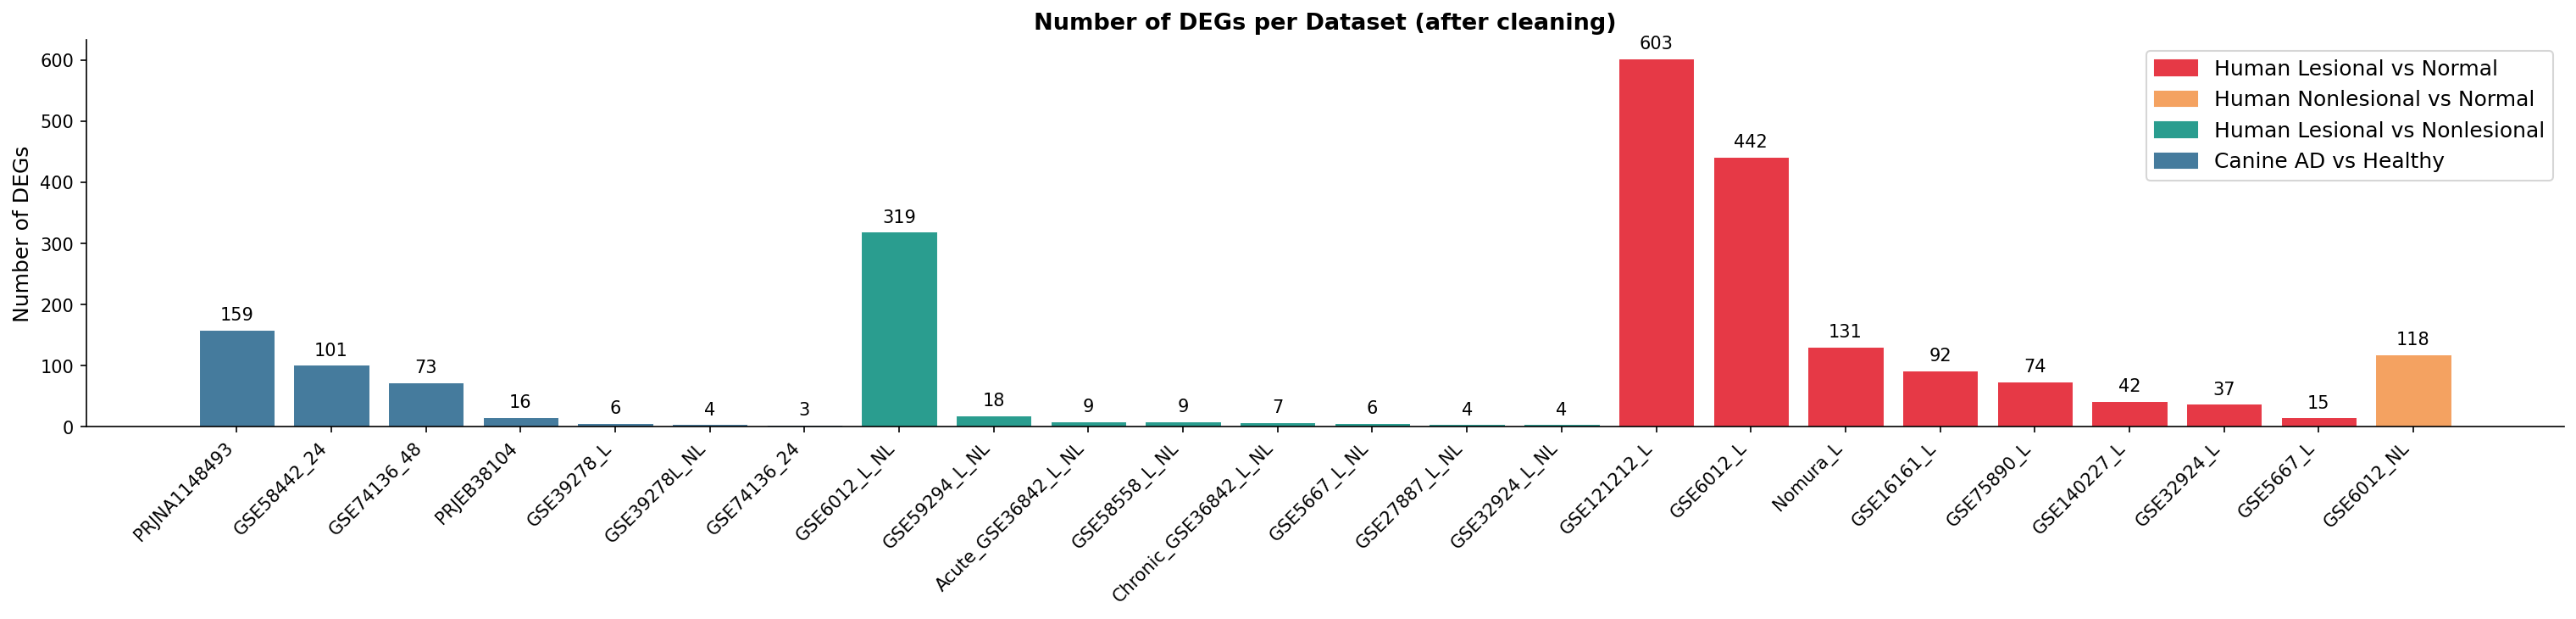

  Figure saved → figures/Fig01_DEGs_per_dataset.pdf


In [49]:
bar_colors = [COMP_COLORS.get(c,'#999') for c in ds_counts['comparison']]

fig, ax = plt.subplots(figsize=(max(10, len(ds_counts)*0.85), 5))
bars = ax.bar(range(len(ds_counts)), ds_counts['n_DEGs'],
              color=bar_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, ds_counts['n_DEGs']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            str(val), ha='center', va='bottom', fontsize=10)
ax.set_xticks(range(len(ds_counts)))
ax.set_xticklabels(ds_counts['dataset'], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Number of DEGs')
ax.set_title('Number of DEGs per Dataset (after cleaning)', fontweight='bold')
patches = [mpatches.Patch(color=v, label=k.replace('_',' '))
           for k,v in COMP_COLORS.items()]
ax.legend(handles=patches, loc='upper right', framealpha=0.8, fontsize=12)
fig.tight_layout()
save_fig(fig, 'Fig01_DEGs_per_dataset.png')

# Save as PDF
pdf_filename = 'Fig01_DEGs_per_dataset.pdf'
pdf_path = os.path.join(DIR_FIG, pdf_filename)
fig.savefig(pdf_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f'  Figure saved → figures/{pdf_filename}')
plt.close(fig) # Close the figure to free up memory

### **Figure 2 - Upregulated vs Downregulated per Dataset**


  Figure saved → figures/Fig02_Up_vs_Down_per_dataset.png


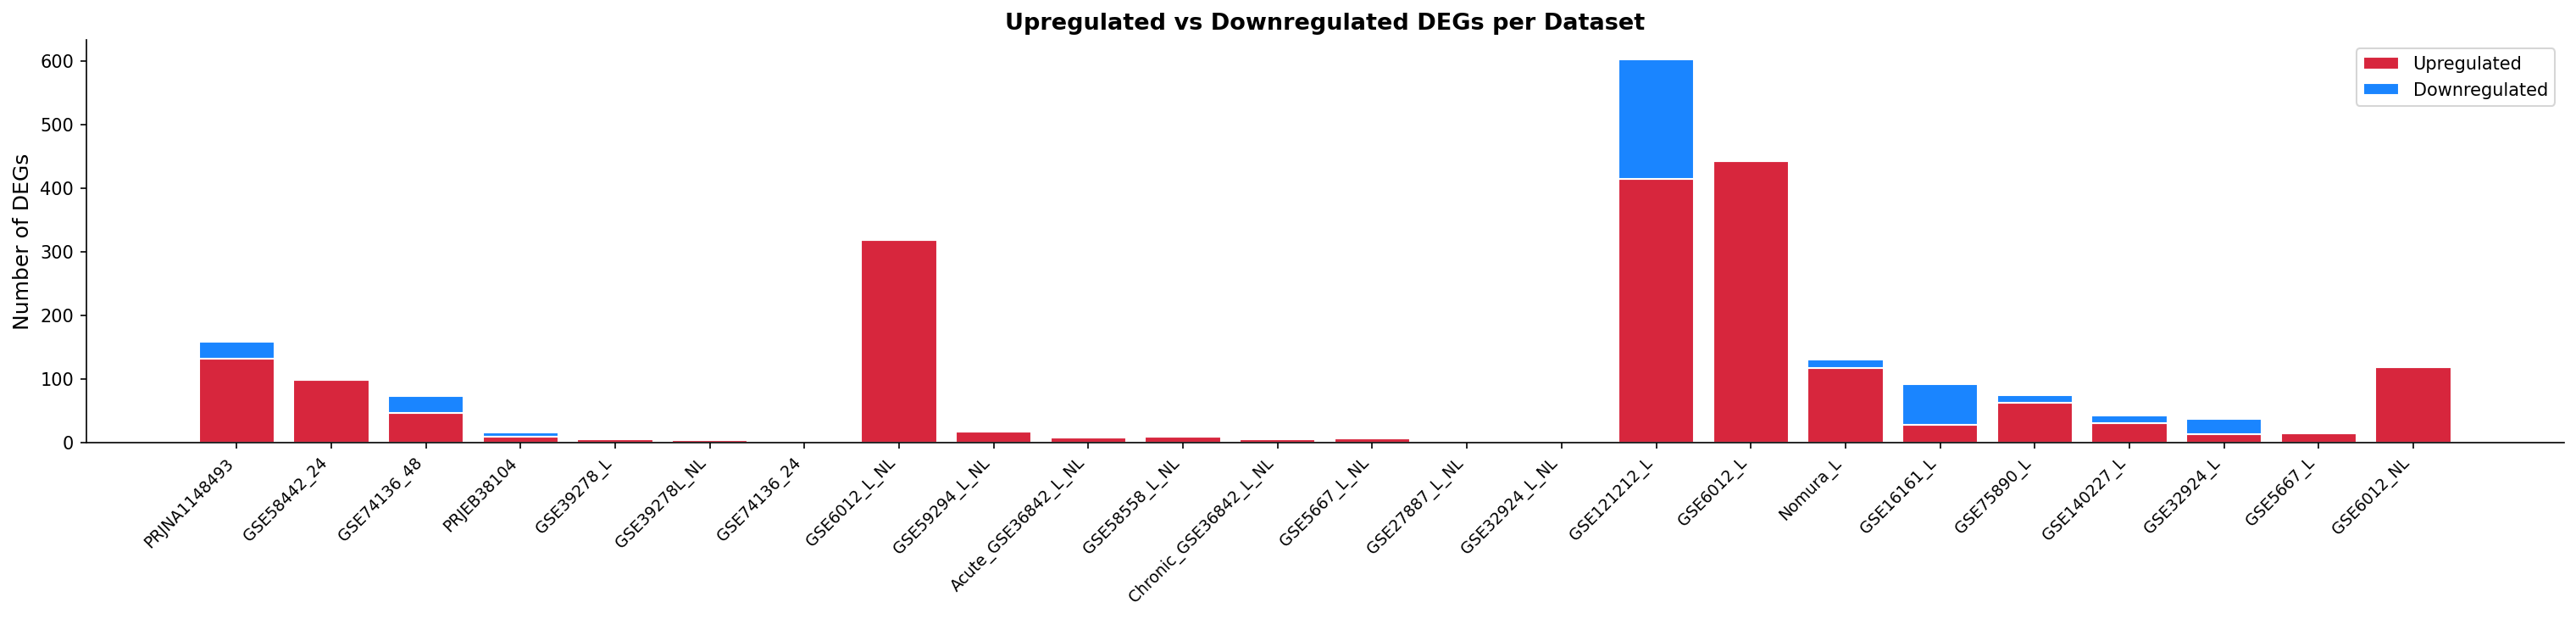

In [21]:
dir_counts = (viz_data.groupby(['dataset','direction'])
              .size().unstack(fill_value=0).reset_index())
dir_counts = dir_counts.reindex(
    columns=['dataset','Upregulated','Downregulated'], fill_value=0)
dir_counts = (dir_counts.set_index('dataset')
              .loc[ds_counts['dataset']].reset_index())

fig, ax = plt.subplots(figsize=(max(10, len(dir_counts)*0.85), 5))
x = range(len(dir_counts))
ax.bar(x, dir_counts['Upregulated'],   color=PALETTE['Upregulated'],
       label='Upregulated',   edgecolor='white')
ax.bar(x, dir_counts['Downregulated'], color=PALETTE['Downregulated'],
       label='Downregulated', edgecolor='white',
       bottom=dir_counts['Upregulated'])
ax.set_xticks(list(x))
ax.set_xticklabels(dir_counts['dataset'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of DEGs')
ax.set_title('Upregulated vs Downregulated DEGs per Dataset', fontweight='bold')
ax.legend(framealpha=0.8)
fig.tight_layout()
save_fig(fig, 'Fig02_Up_vs_Down_per_dataset.png')


### **Figure 3 - Volcano Plots per Dataset**


  Figure saved → figures/Fig03_Volcano_plots_all_datasets.png


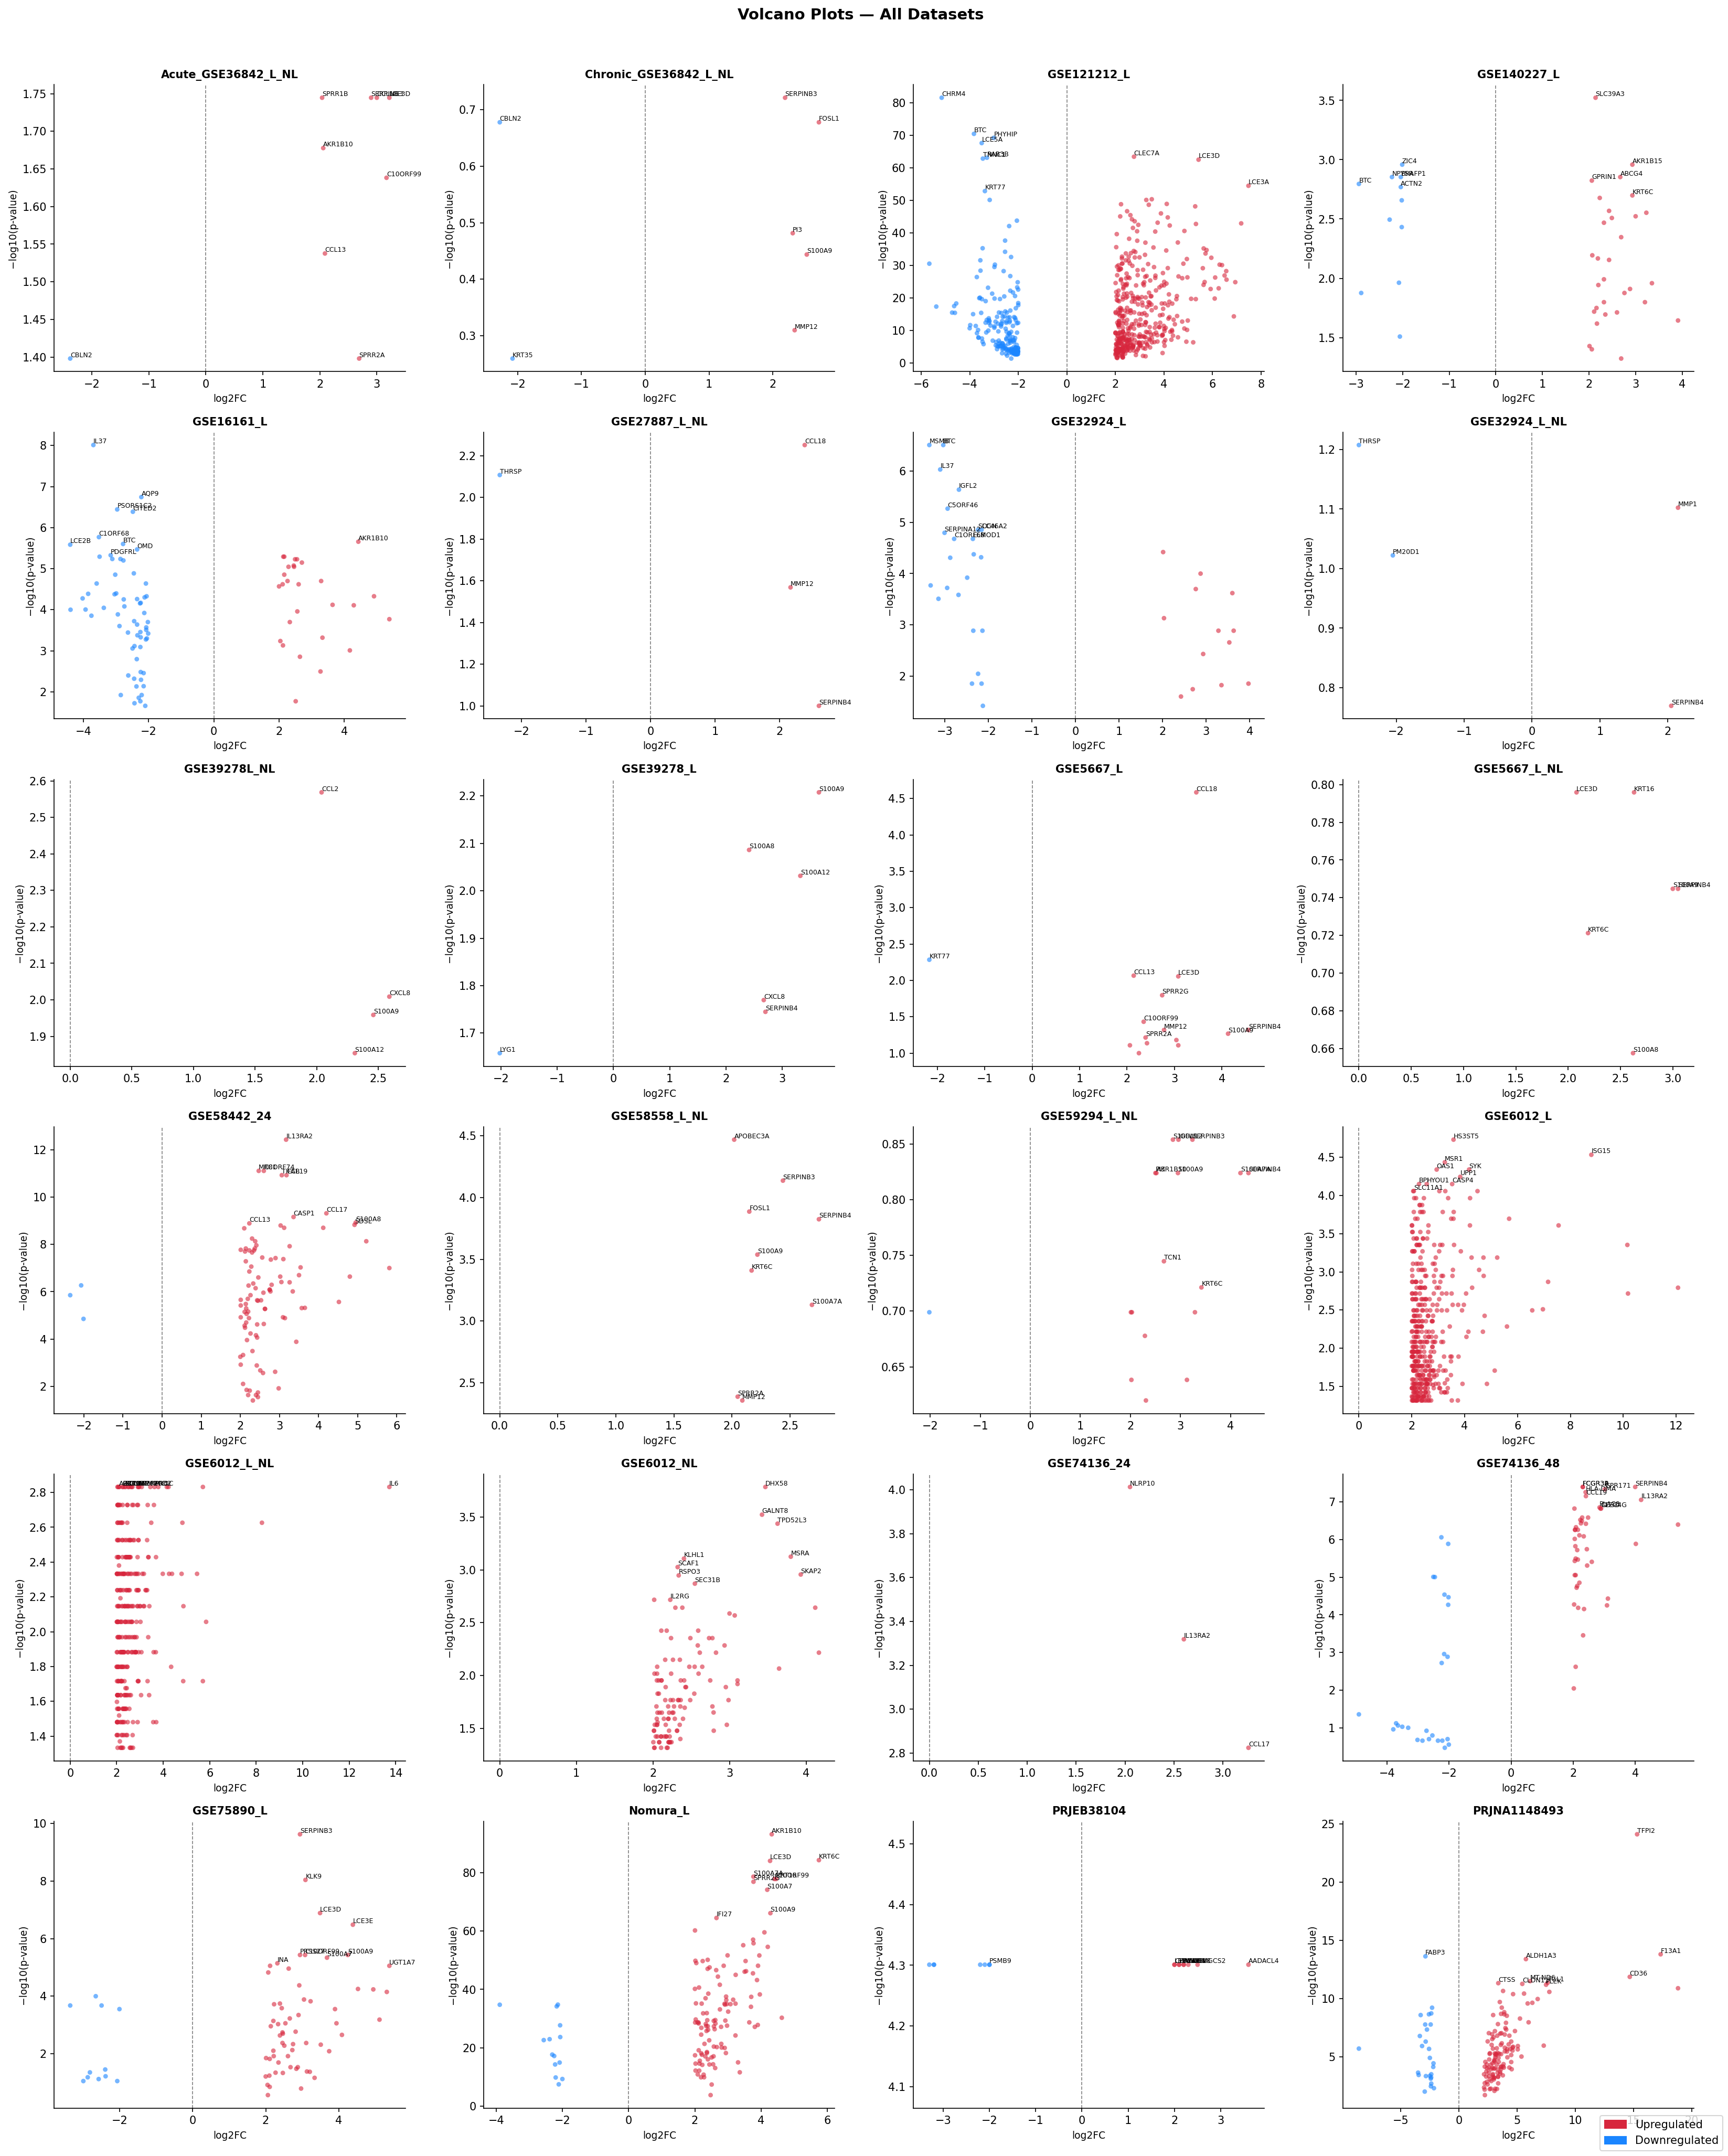

In [22]:
datasets_list = sorted(viz_data['dataset'].unique())
n_ds   = len(datasets_list)
ncols  = 4
nrows  = int(np.ceil(n_ds / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5.5, nrows*4.5))
axes_flat  = axes.flatten() if n_ds > 1 else [axes]

for i, ds in enumerate(datasets_list):
    ax  = axes_flat[i]
    ddf = viz_data[viz_data['dataset']==ds].copy()
    ddf['neg_log10p'] = -np.log10(ddf['p_value'].clip(lower=1e-300))
    colors = [PALETTE[d] for d in ddf['direction']]
    ax.scatter(ddf['log2FC'], ddf['neg_log10p'],
               c=colors, alpha=0.6, s=18, linewidths=0)
    top10 = ddf.nsmallest(10, 'p_value')
    for _, row in top10.iterrows():
        ax.text(row['log2FC'], row['neg_log10p'], row['Gene_Symbol'],
                fontsize=6, ha='left', va='bottom', color='black')
    ax.axvline(0, color='grey', lw=0.8, linestyle='--')
    ax.set_title(ds, fontsize=10, fontweight='bold')
    ax.set_xlabel('log2FC', fontsize=9)
    ax.set_ylabel('−log10(p-value)', fontsize=9)

for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

patches = [mpatches.Patch(color=v, label=k) for k,v in PALETTE.items()]
fig.legend(handles=patches, loc='lower right', fontsize=10, framealpha=0.8)
fig.suptitle('Volcano Plots — All Datasets', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
save_fig(fig, 'Fig03_Volcano_plots_all_datasets.png')


### **Figure 4 - log2FC Distribution per Dataset**


  Figure saved → figures/Fig04_log2FC_distributions.png


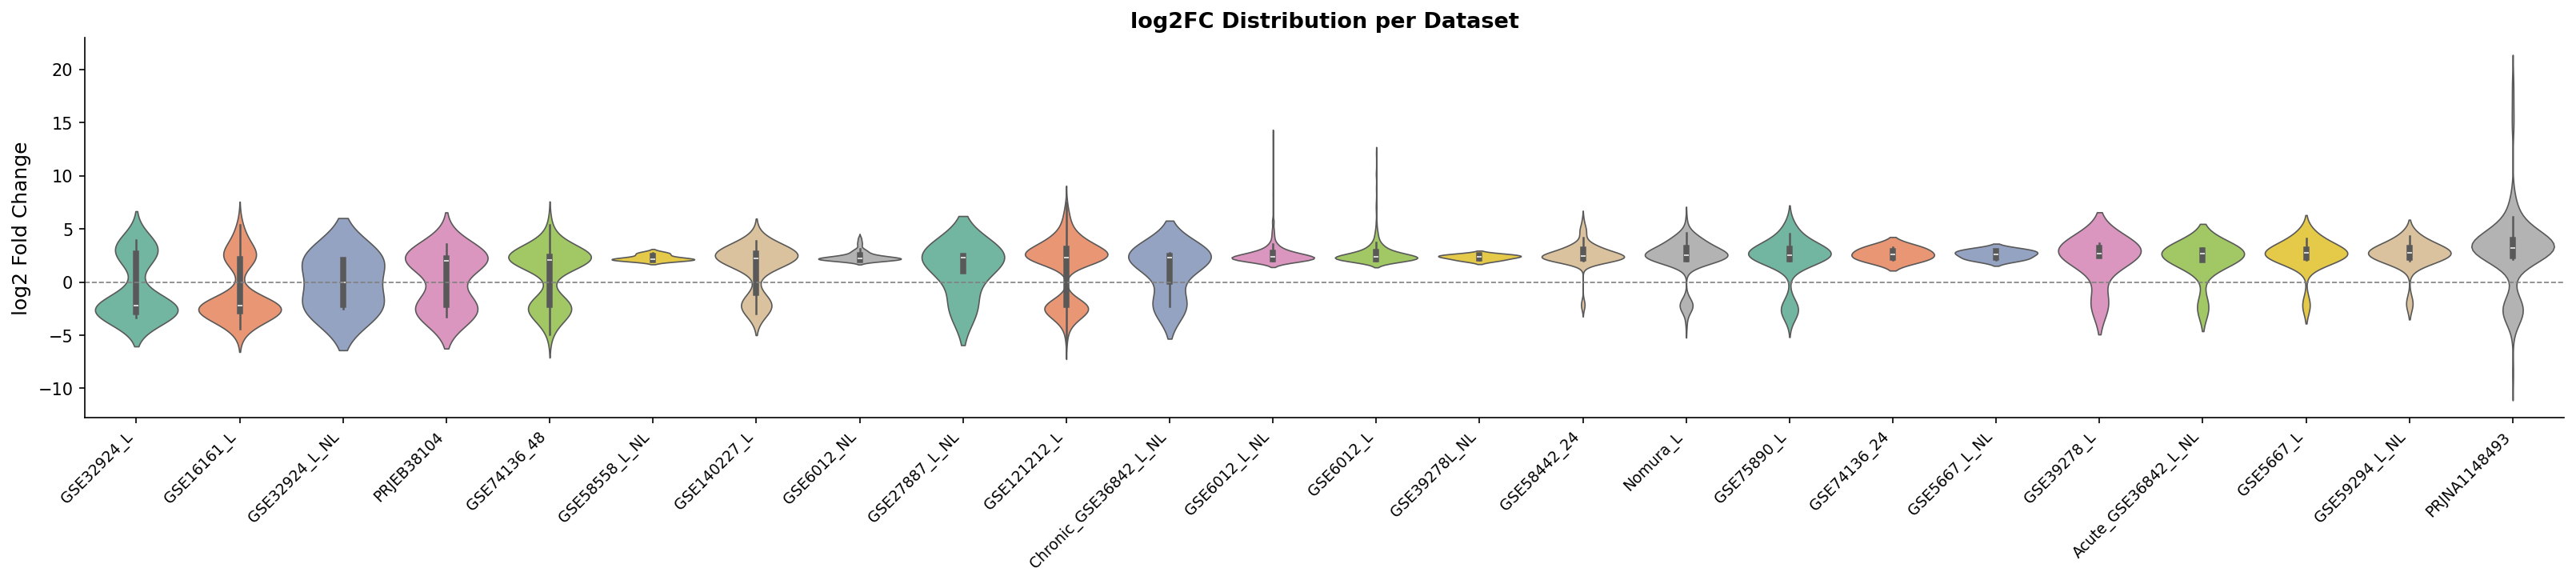

In [23]:
order = (viz_data.groupby('dataset')['log2FC']
         .median().sort_values().index.tolist())
fig, ax = plt.subplots(figsize=(max(10, n_ds*0.9), 5))
sns.violinplot(data=viz_data, x='dataset', y='log2FC', order=order,
               inner='box', palette='Set2', linewidth=0.8, ax=ax)
ax.axhline(0, color='grey', lw=0.8, linestyle='--')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_xlabel('')
ax.set_ylabel('log2 Fold Change')
ax.set_title('log2FC Distribution per Dataset', fontweight='bold')
fig.tight_layout()
save_fig(fig, 'Fig04_log2FC_distributions.png')


### **Figure 5 - Gene Presence/Absence Heatmap per Comparison**


  Figure saved → figures/Fig05_presence_absence_Human_Lesional_vs_Normal.png


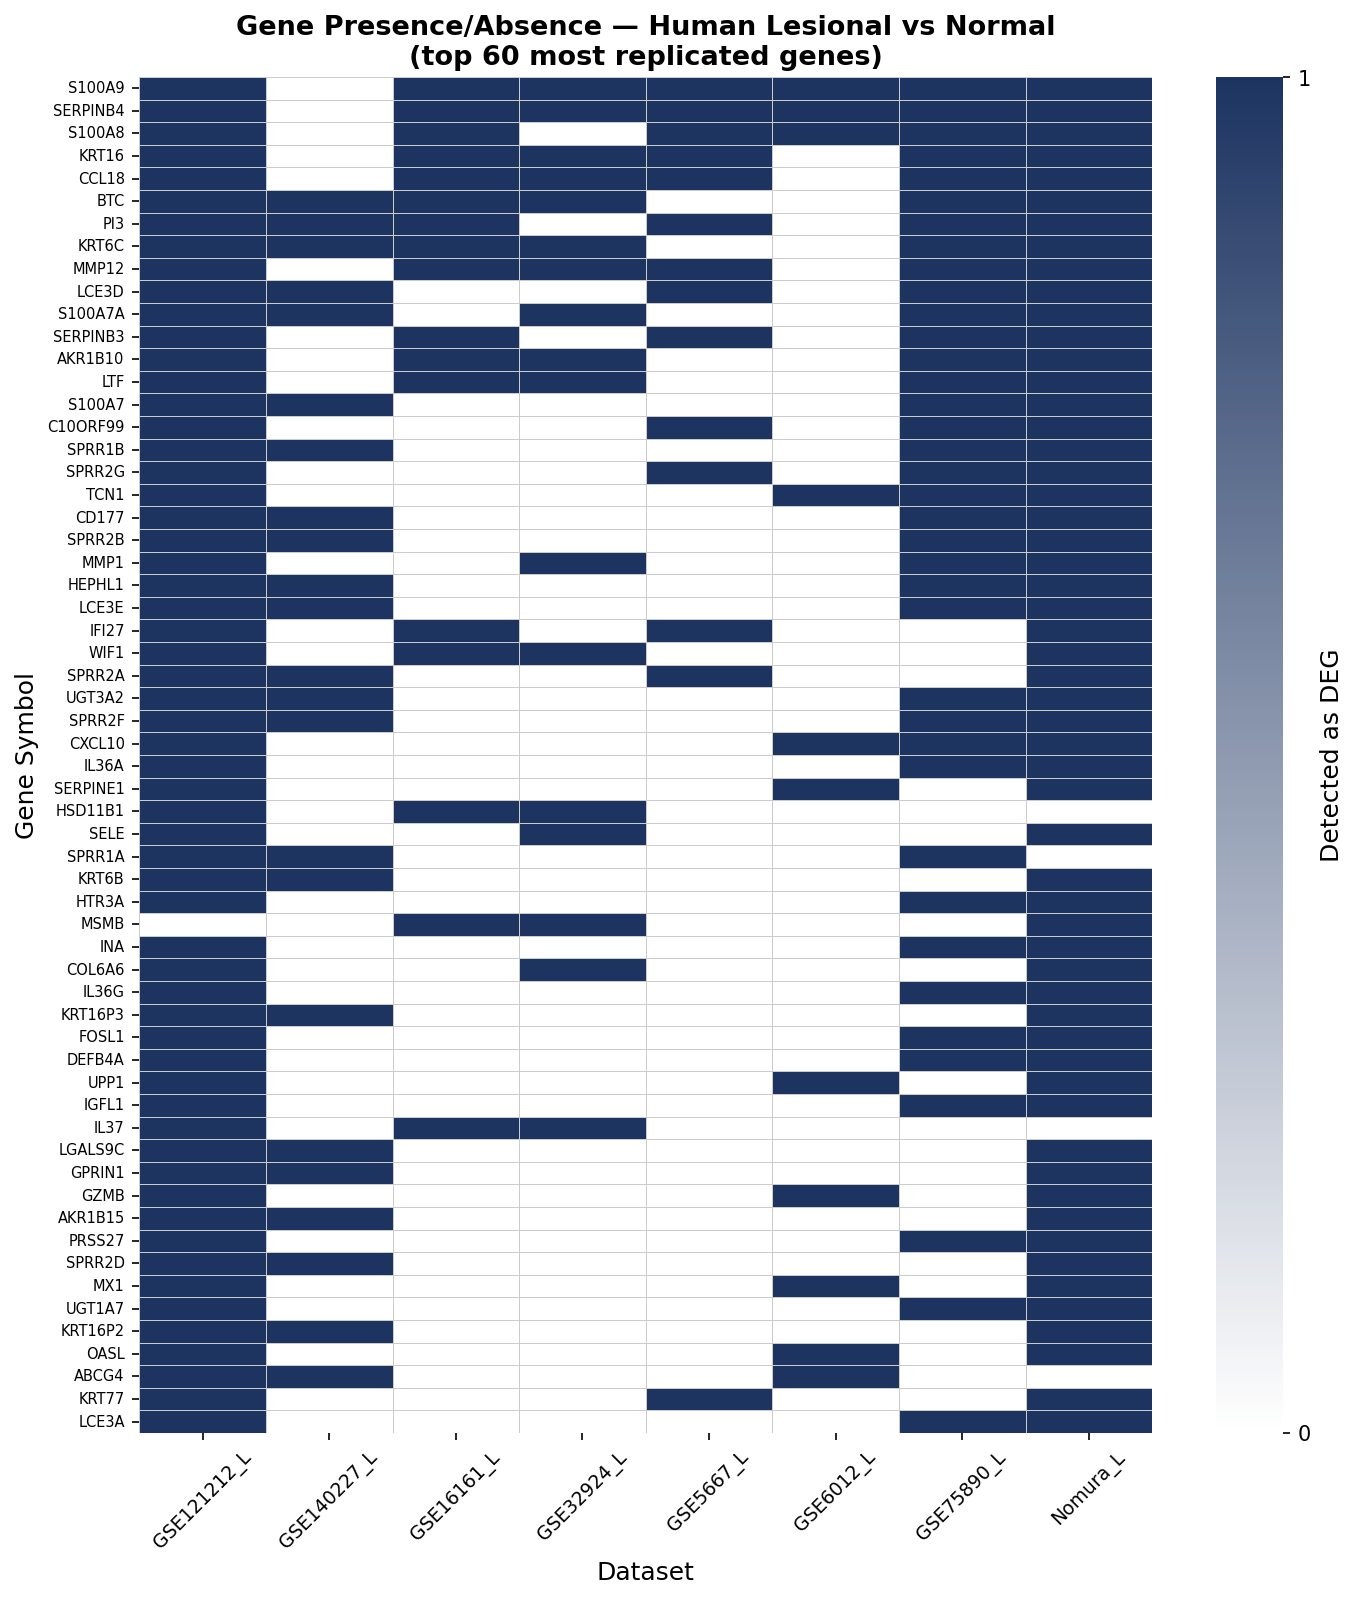

  Skipping presence/absence for Human_Nonlesional_vs_Normal (only 1 dataset)
  Figure saved → figures/Fig05_presence_absence_Human_Lesional_vs_Nonlesional.png


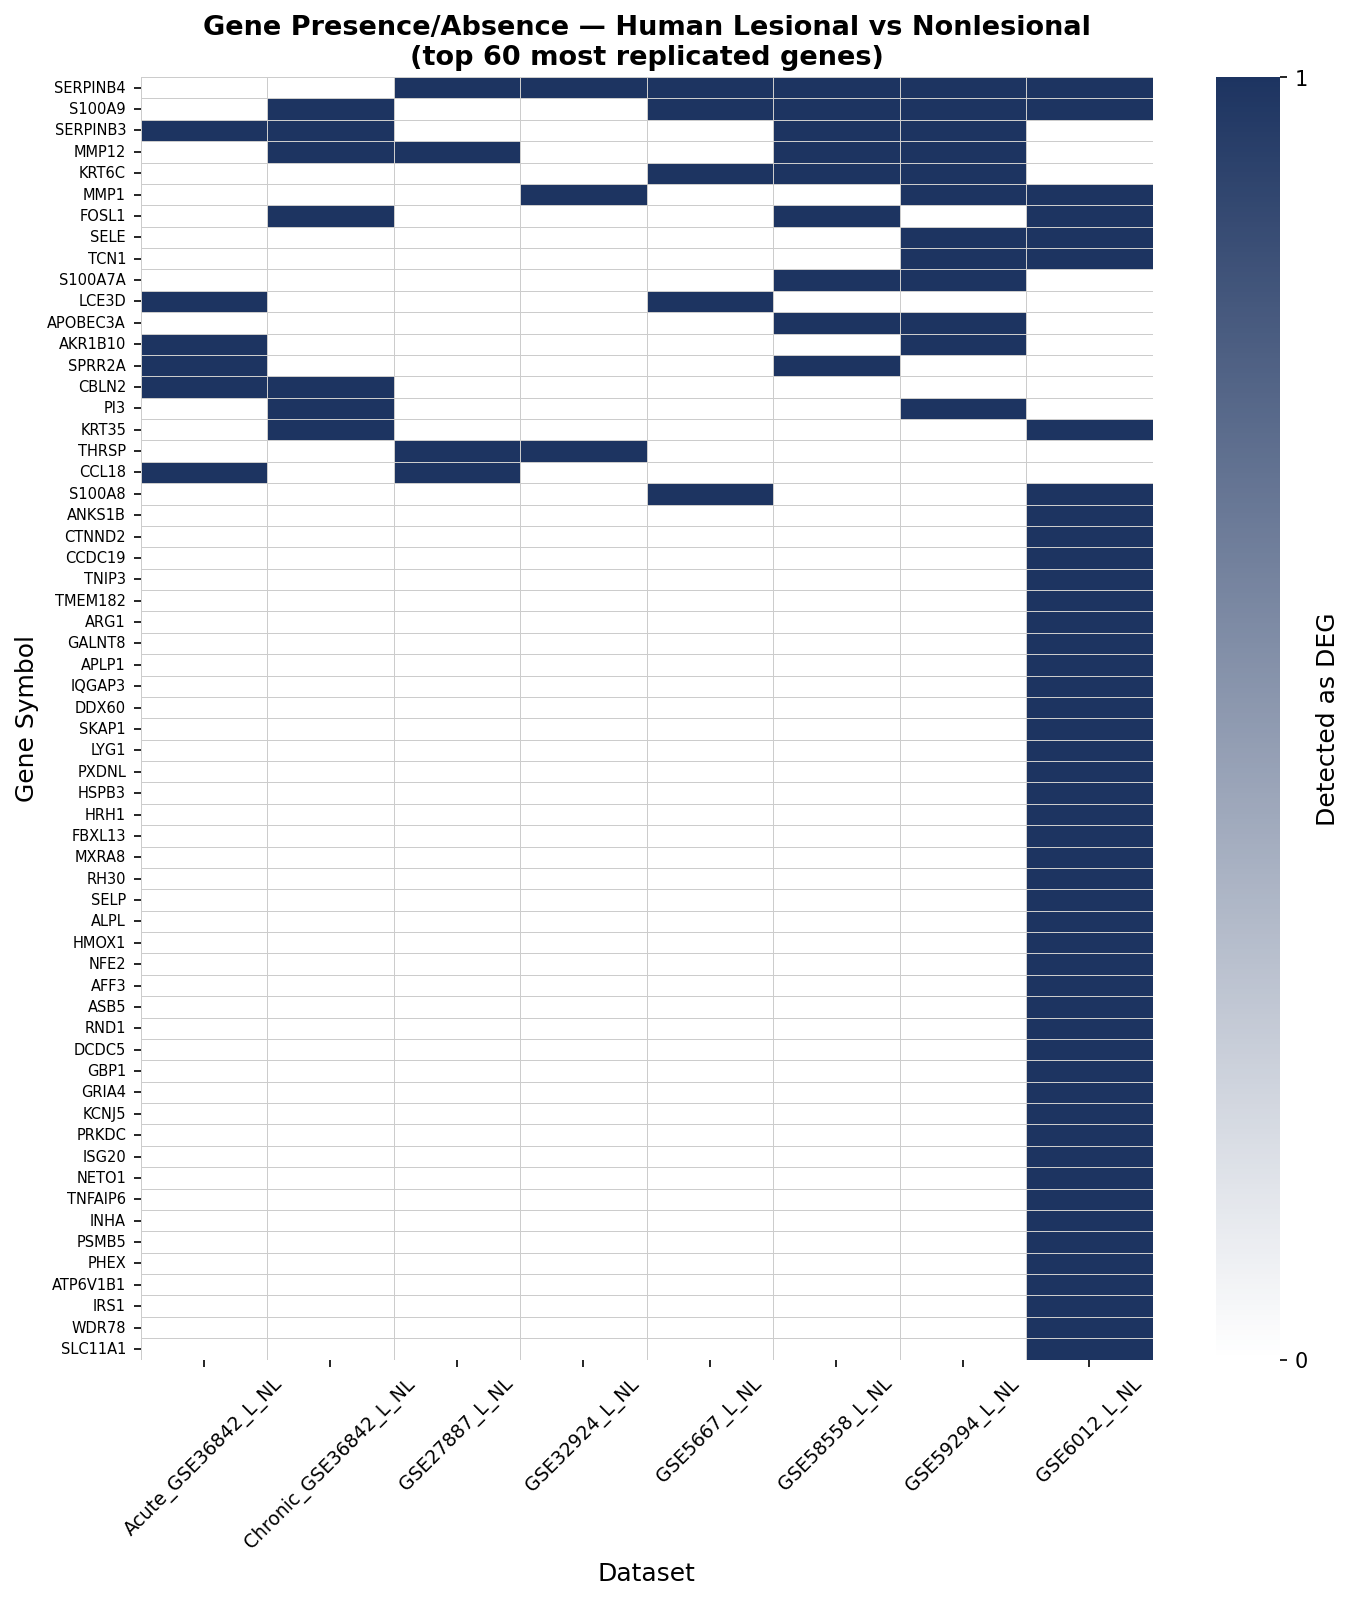

  Figure saved → figures/Fig05_presence_absence_Canine_AD_vs_Healthy.png


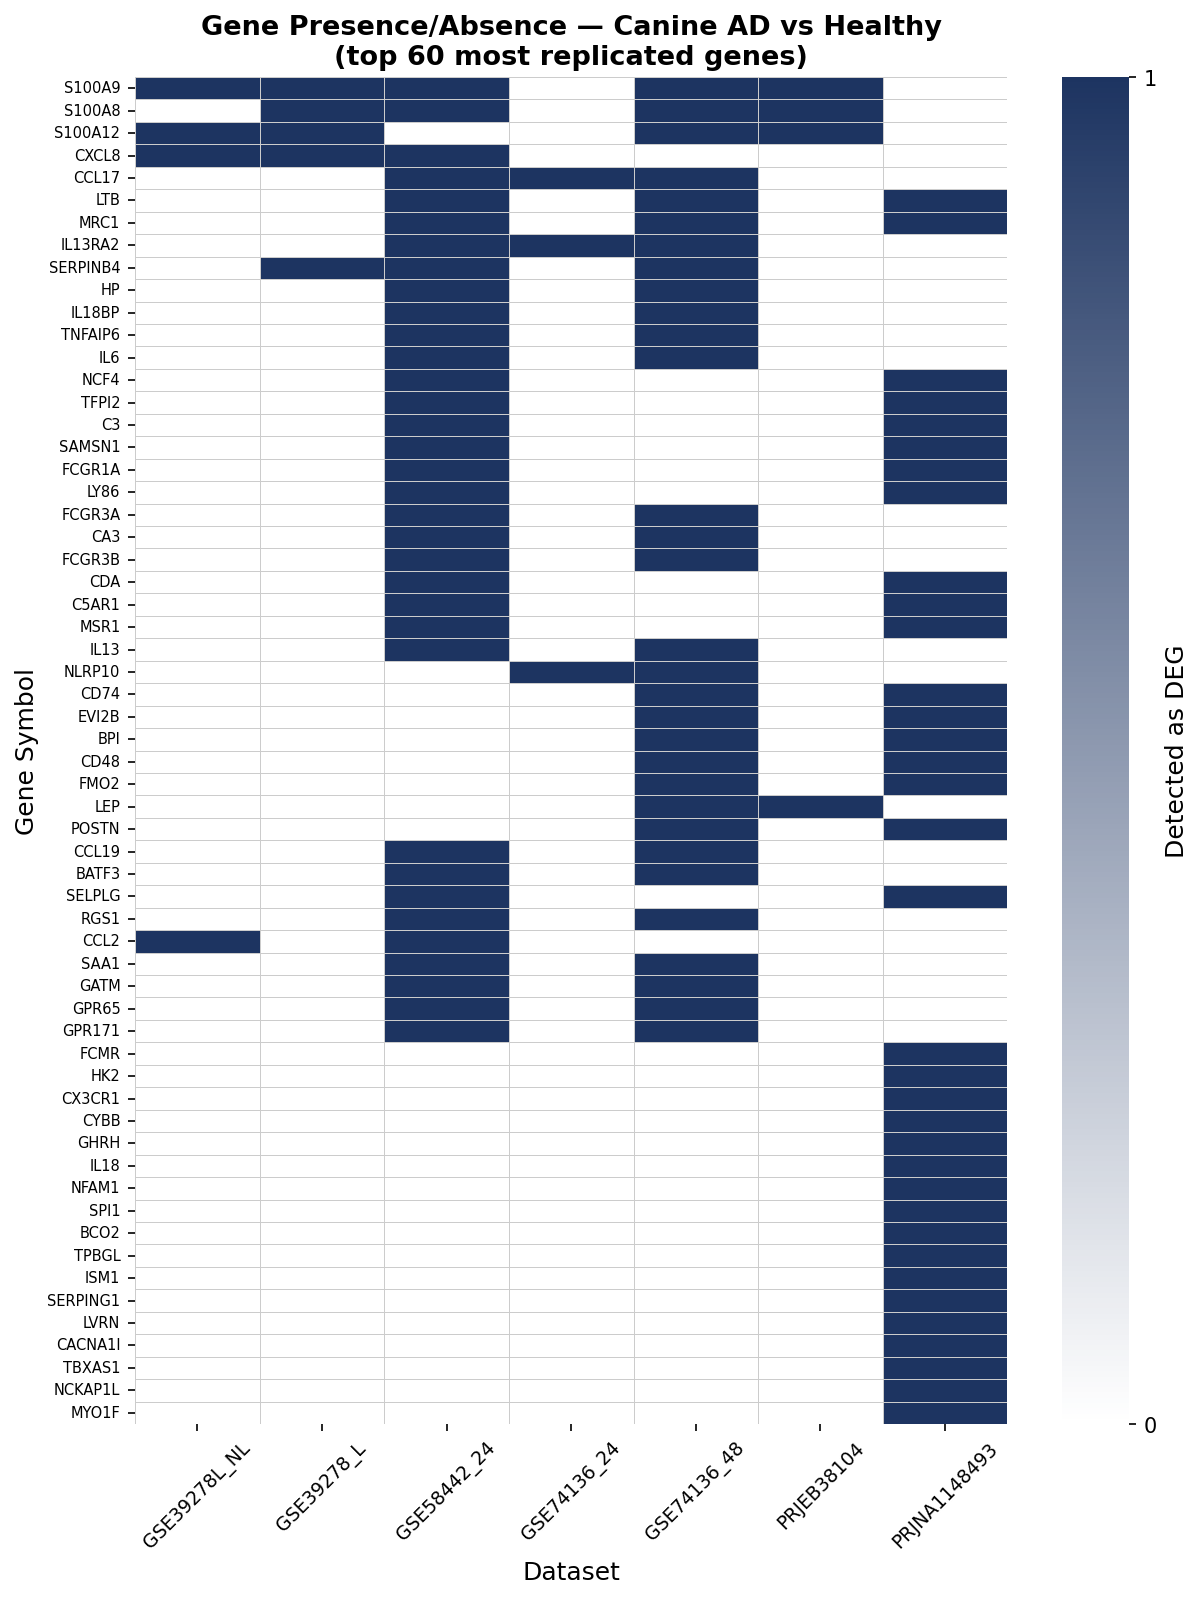

In [24]:
for comp_name, comp_df in all_cleaned.items():
    cdf      = comp_df[~comp_df['exclude_viz']].copy()
    datasets = sorted(cdf['dataset'].unique())
    if len(datasets) < 2:
        print(f'  Skipping presence/absence for {comp_name} (only 1 dataset)')
        continue

    genes = cdf['Gene_Symbol'].unique()
    mat   = pd.DataFrame(0, index=genes, columns=datasets)
    for ds in datasets:
        present = cdf[cdf['dataset']==ds]['Gene_Symbol'].values
        mat.loc[np.intersect1d(present, mat.index), ds] = 1

    mat['_n'] = mat.sum(axis=1)
    mat = mat.sort_values('_n', ascending=False).drop(columns='_n').head(60)

    fig_h = max(6, len(mat)*0.18)
    fig_w = max(5, len(datasets)*1.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    cmap2   = LinearSegmentedColormap.from_list('pa', ['white','#1D3461'])
    sns.heatmap(mat, cmap=cmap2, linewidths=0.3, linecolor='#cccccc',
                cbar_kws={'label':'Detected as DEG','ticks':[0,1]},
                ax=ax, yticklabels=True)
    ax.set_title(
        f'Gene Presence/Absence — {comp_name.replace("_"," ")}\n'
        f'(top 60 most replicated genes)', fontweight='bold')
    ax.set_xlabel('Dataset')
    ax.set_ylabel('Gene Symbol')
    ax.tick_params(axis='y', labelsize=7)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    fig.tight_layout()
    save_fig(fig, f'Fig05_presence_absence_{comp_name}.png')


### **Figure 6 - UpSet Plots (Dataset Overlap per Comparison)**


In [25]:
for comp_name, comp_df in all_cleaned.items():
    cdf      = comp_df[~comp_df['exclude_viz']]
    datasets = sorted(cdf['dataset'].unique())
    if len(datasets) < 2:
        print(f'  Skipping UpSet for {comp_name} (only 1 dataset)')
        continue

    gene_sets = defaultdict(set)
    for ds in datasets:
        for g in cdf[cdf['dataset']==ds]['Gene_Symbol']:
            gene_sets[g].add(ds)

    try:
        upset_data = from_memberships(list(gene_sets.values()))
        fig = plt.figure(figsize=(max(8, len(datasets)*1.5), 5))
        upset_plot(upset_data, fig=fig, show_counts=True, totals_plot_elements=2)
        fig.suptitle(f'DEG Overlap — {comp_name.replace("_"," ")}',
                     fontweight='bold', y=1.02)
        save_fig(fig, f'Fig06_UpSet_{comp_name}.png')
    except Exception as e:
        print(f'  UpSet plot failed for {comp_name}: {e}')


  UpSet plot failed for Human_Lesional_vs_Normal: subset_size="auto" cannot be used for a Series with non-unique groups.
  Skipping UpSet for Human_Nonlesional_vs_Normal (only 1 dataset)
  UpSet plot failed for Human_Lesional_vs_Nonlesional: subset_size="auto" cannot be used for a Series with non-unique groups.
  UpSet plot failed for Canine_AD_vs_Healthy: subset_size="auto" cannot be used for a Series with non-unique groups.


<Figure size 1800x750 with 0 Axes>

<Figure size 1800x750 with 0 Axes>

<Figure size 1575x750 with 0 Axes>

## **Step 8 - Build Wide-Format Matrices**

One **p-value matrix** and one **log2FC matrix** per comparison (genes × datasets).
NaN = gene not detected in that dataset.
These feed directly into the meta-analysis below and are also saved for external use.


In [26]:
matrices = {}   # comp_name → {'pvalue': df, 'log2FC': df}
print('Building matrices...\n')

for comp_name, comp_df in all_cleaned.items():
    datasets  = sorted(comp_df['dataset'].unique())
    all_genes = sorted(comp_df['Gene_Symbol'].unique())

    pmat  = pd.DataFrame(np.nan, index=all_genes, columns=datasets)
    fcmat = pd.DataFrame(np.nan, index=all_genes, columns=datasets)

    for ds in datasets:
        dsdf       = comp_df[comp_df['dataset']==ds].set_index('Gene_Symbol')
        pmat[ds]   = dsdf['p_value'].reindex(all_genes)
        fcmat[ds]  = dsdf['log2FC'].reindex(all_genes)

    pmat.index.name  = 'Gene_Symbol'
    fcmat.index.name = 'Gene_Symbol'
    matrices[comp_name] = {'pvalue': pmat, 'log2FC': fcmat}

    n2 = (pmat.notna().sum(axis=1) >= 2).sum()
    print(f'  {comp_name}')
    print(f'    {len(all_genes):,} genes | {len(datasets)} datasets | '
          f'genes in ≥2 datasets: {n2:,}')

    safe = comp_name.replace(' ','_')
    pmat.to_csv(os.path.join(DIR_COMBINED, f'{safe}_pvalue_matrix.csv'))
    fcmat.to_csv(os.path.join(DIR_COMBINED, f'{safe}_log2FC_matrix.csv'))
    print(f'    Saved: {safe}_pvalue_matrix.csv  &  {safe}_log2FC_matrix.csv\n')

print('All matrices built and saved → Results/combined_data/')


Building matrices...

  Human_Lesional_vs_Normal
    1,271 genes | 8 datasets | genes in ≥2 datasets: 181
    Saved: Human_Lesional_vs_Normal_pvalue_matrix.csv  &  Human_Lesional_vs_Normal_log2FC_matrix.csv

  Human_Nonlesional_vs_Normal
    157 genes | 1 datasets | genes in ≥2 datasets: 0
    Saved: Human_Nonlesional_vs_Normal_pvalue_matrix.csv  &  Human_Nonlesional_vs_Normal_log2FC_matrix.csv

  Human_Lesional_vs_Nonlesional
    423 genes | 8 datasets | genes in ≥2 datasets: 20
    Saved: Human_Lesional_vs_Nonlesional_pvalue_matrix.csv  &  Human_Lesional_vs_Nonlesional_log2FC_matrix.csv

  Canine_AD_vs_Healthy
    313 genes | 7 datasets | genes in ≥2 datasets: 43
    Saved: Canine_AD_vs_Healthy_pvalue_matrix.csv  &  Canine_AD_vs_Healthy_log2FC_matrix.csv

All matrices built and saved → Results/combined_data/


## **Step 9 - Vote-Count Meta-Summary**

Before running formal statistics we compute a transparent gene-level summary
that counts how many datasets support each gene. This provides the initial
confidence tiers and the supporting figures (Figs 7–10).
These tiers are later refined by the Fisher/Stouffer p-values in Step 10.


In [27]:
meta_summaries = {}

def compute_meta_summary(comp_df, comp_name):
    datasets_in_comp = comp_df['dataset'].unique()
    total_datasets   = len(datasets_in_comp)
    records = []

    for gene, gdf in comp_df.groupby('Gene_Symbol'):
        n_det  = gdf['dataset'].nunique()
        n_up   = int((gdf['direction']=='Upregulated').sum())
        n_dn   = int((gdf['direction']=='Downregulated').sum())
        majority    = max(n_up, n_dn)
        consistency = majority / n_det if n_det > 0 else 0

        if n_up > n_dn:
            consensus = 'Upregulated'
        elif n_dn > n_up:
            consensus = 'Downregulated'
        else:
            consensus = 'Conflicting'

        if n_det >= 2 and consistency >= 0.8:
            confidence = 'High-confidence'
        elif n_det >= 2 and consistency >= 0.6:
            confidence = 'Moderate-confidence'
        elif n_det >= 2 and consistency < 0.6:
            confidence = 'Conflicting'
        else:
            confidence = 'Dataset-specific'

        records.append({
            'Gene_Symbol'           : gene,
            'n_datasets_detected'   : n_det,
            'total_datasets'        : total_datasets,
            'pct_datasets'          : round(100*n_det/total_datasets, 1),
            'n_up'                  : n_up,
            'n_down'                : n_dn,
            'consensus_direction'   : consensus,
            'median_log2FC'         : round(float(gdf['log2FC'].median()), 4),
            'mean_log2FC'           : round(float(gdf['log2FC'].mean()),   4),
            'min_p_value'           : float(gdf['p_value'].min()),
            'median_p_value'        : float(gdf['p_value'].median()),
            'direction_consistency' : round(consistency, 3),
            'DEG_confidence'        : confidence,
            'exclude_viz'           : bool(gdf['exclude_viz'].any()),
        })

    return (pd.DataFrame(records)
              .sort_values(['n_datasets_detected','min_p_value'],
                           ascending=[False,True])
              .reset_index(drop=True))

print('Computing vote-count meta-summaries...\n')
for comp_name, comp_df in all_cleaned.items():
    summary = compute_meta_summary(comp_df, comp_name)
    meta_summaries[comp_name] = summary
    out_path = os.path.join(DIR_META, f'{comp_name}_vote_summary.csv')
    summary.to_csv(out_path, index=False)
    cc = summary['DEG_confidence'].value_counts()
    print(f'  {comp_name}')
    print(f'    Total unique genes : {len(summary):,}')
    for tier in ['High-confidence','Moderate-confidence','Conflicting','Dataset-specific']:
        print(f'    {tier:<25}: {cc.get(tier,0):>5}')
    print(f'    Saved → {comp_name}_vote_summary.csv\n')


Computing vote-count meta-summaries...

  Human_Lesional_vs_Normal
    Total unique genes : 1,271
    High-confidence          :   175
    Moderate-confidence      :     0
    Conflicting              :     6
    Dataset-specific         :  1090
    Saved → Human_Lesional_vs_Normal_vote_summary.csv

  Human_Nonlesional_vs_Normal
    Total unique genes : 157
    High-confidence          :     0
    Moderate-confidence      :     0
    Conflicting              :     0
    Dataset-specific         :   157
    Saved → Human_Nonlesional_vs_Normal_vote_summary.csv

  Human_Lesional_vs_Nonlesional
    Total unique genes : 423
    High-confidence          :    19
    Moderate-confidence      :     0
    Conflicting              :     1
    Dataset-specific         :   403
    Saved → Human_Lesional_vs_Nonlesional_vote_summary.csv

  Canine_AD_vs_Healthy
    Total unique genes : 313
    High-confidence          :    39
    Moderate-confidence      :     2
    Conflicting              :     2
  

### **Figure 7 - log2FC Heatmap: Top High-Confidence Genes (vote-count)**


  Figure saved → figures/Fig07_log2FC_heatmap_highconf_Human_Lesional_vs_Normal.png


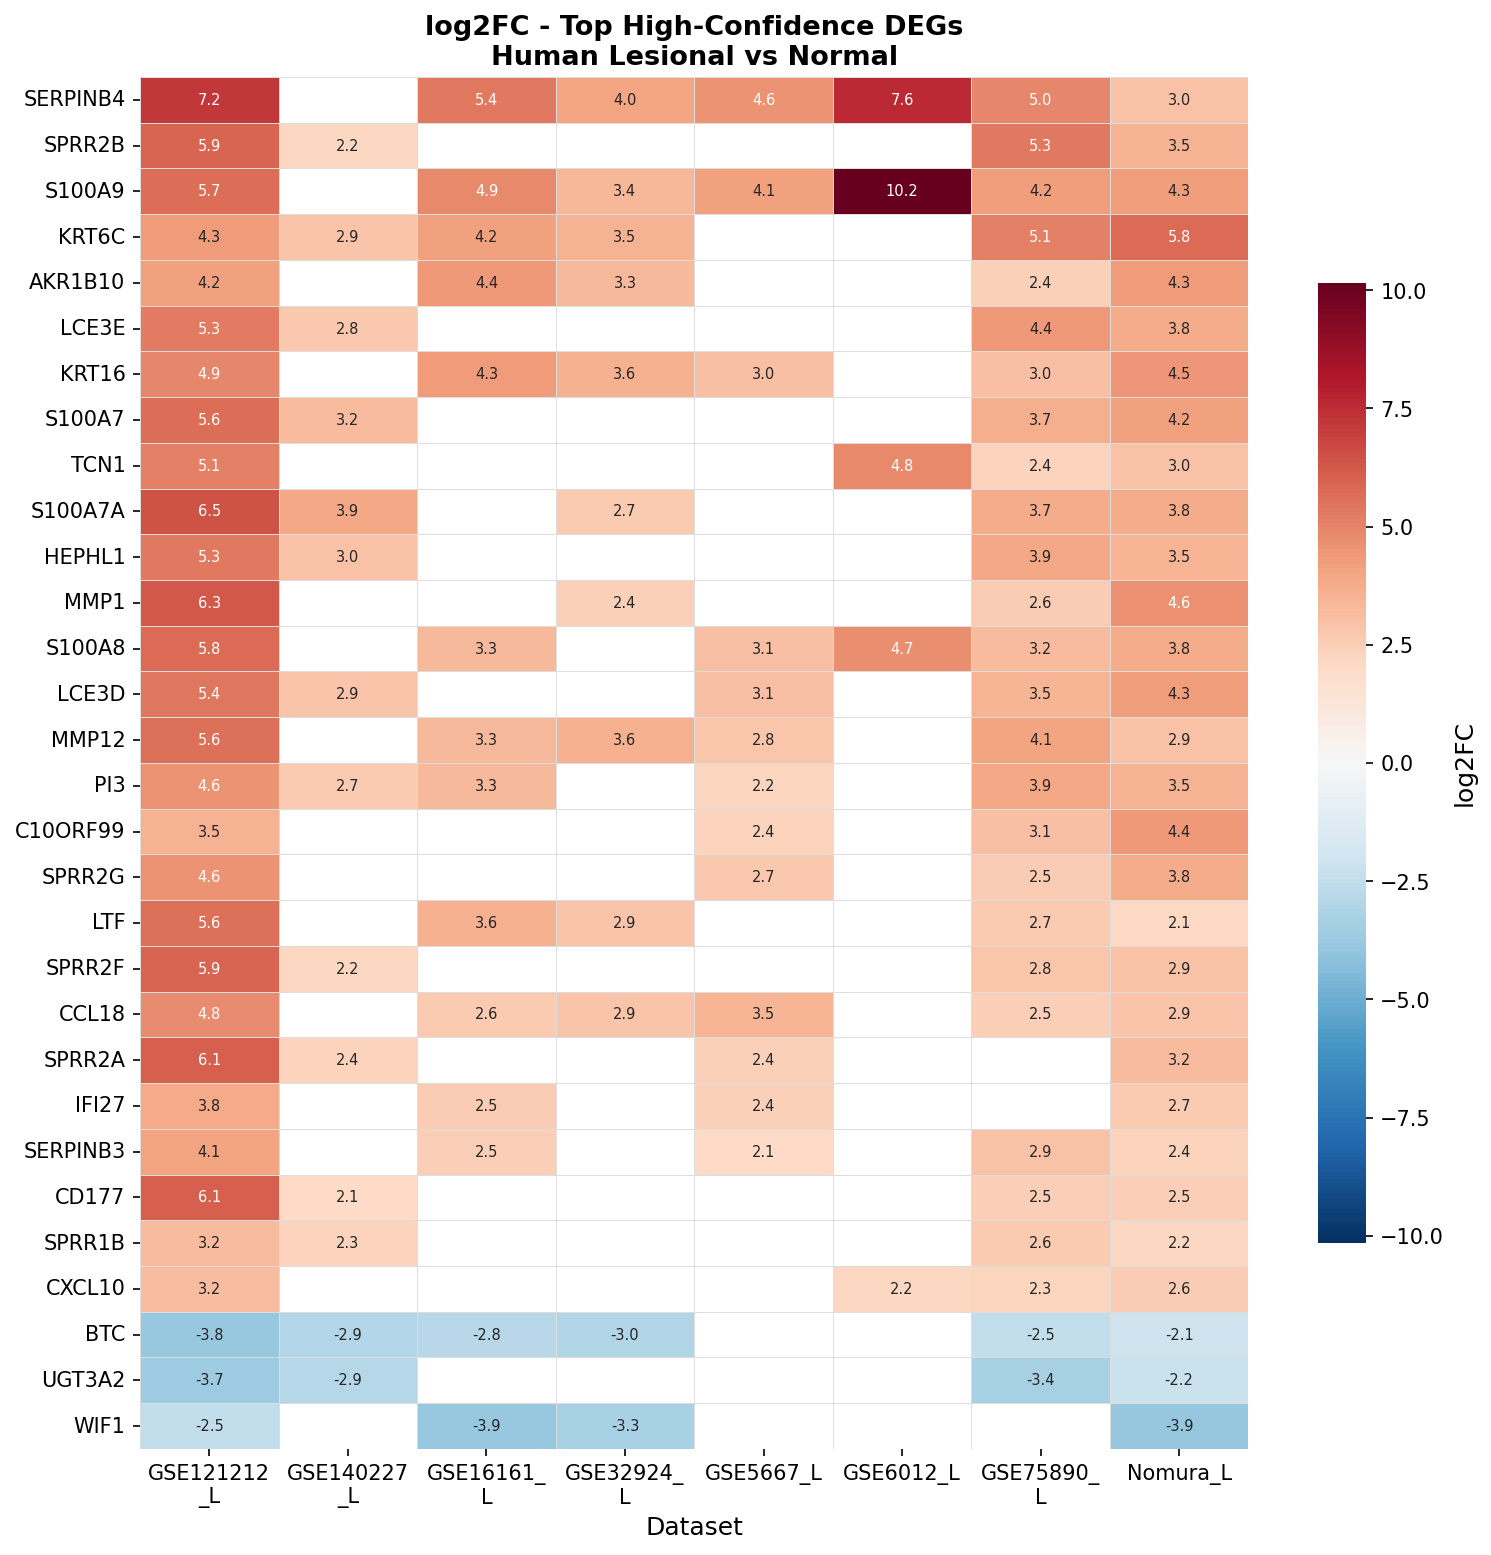

  Figure saved → figures/Fig07_log2FC_heatmap_highconf_Human_Lesional_vs_Normal.pdf
  Figure saved → figures/Fig07_log2FC_heatmap_highconf_Human_Lesional_vs_Normal.svg
  No high-confidence genes for Human_Nonlesional_vs_Normal — skipping
  Figure saved → figures/Fig07_log2FC_heatmap_highconf_Human_Lesional_vs_Nonlesional.png


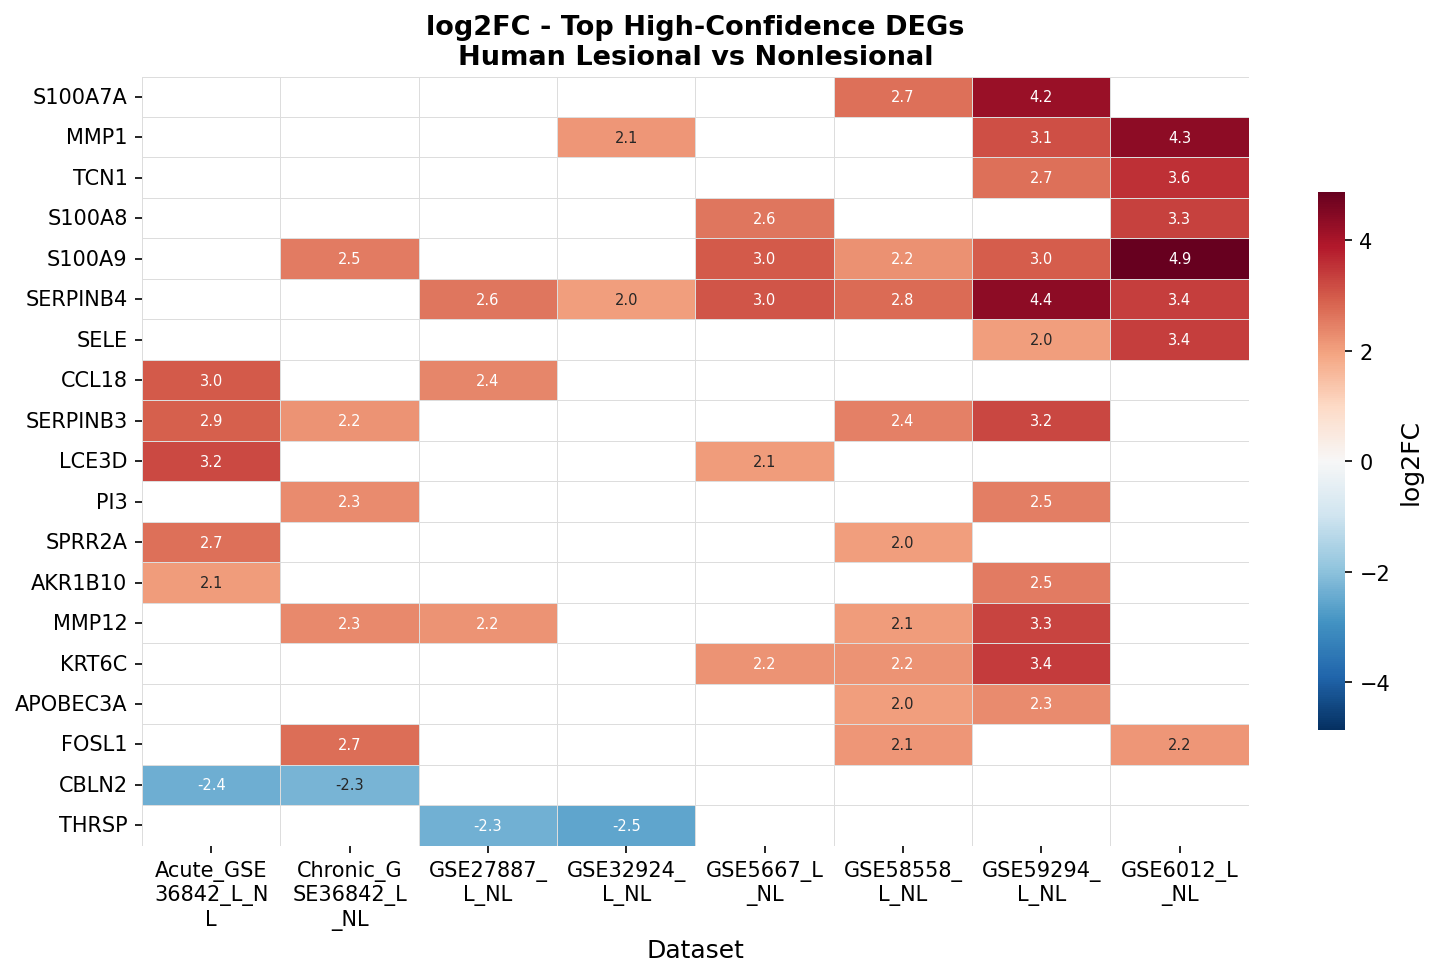

  Figure saved → figures/Fig07_log2FC_heatmap_highconf_Human_Lesional_vs_Nonlesional.pdf
  Figure saved → figures/Fig07_log2FC_heatmap_highconf_Human_Lesional_vs_Nonlesional.svg
  Figure saved → figures/Fig07_log2FC_heatmap_highconf_Canine_AD_vs_Healthy.png


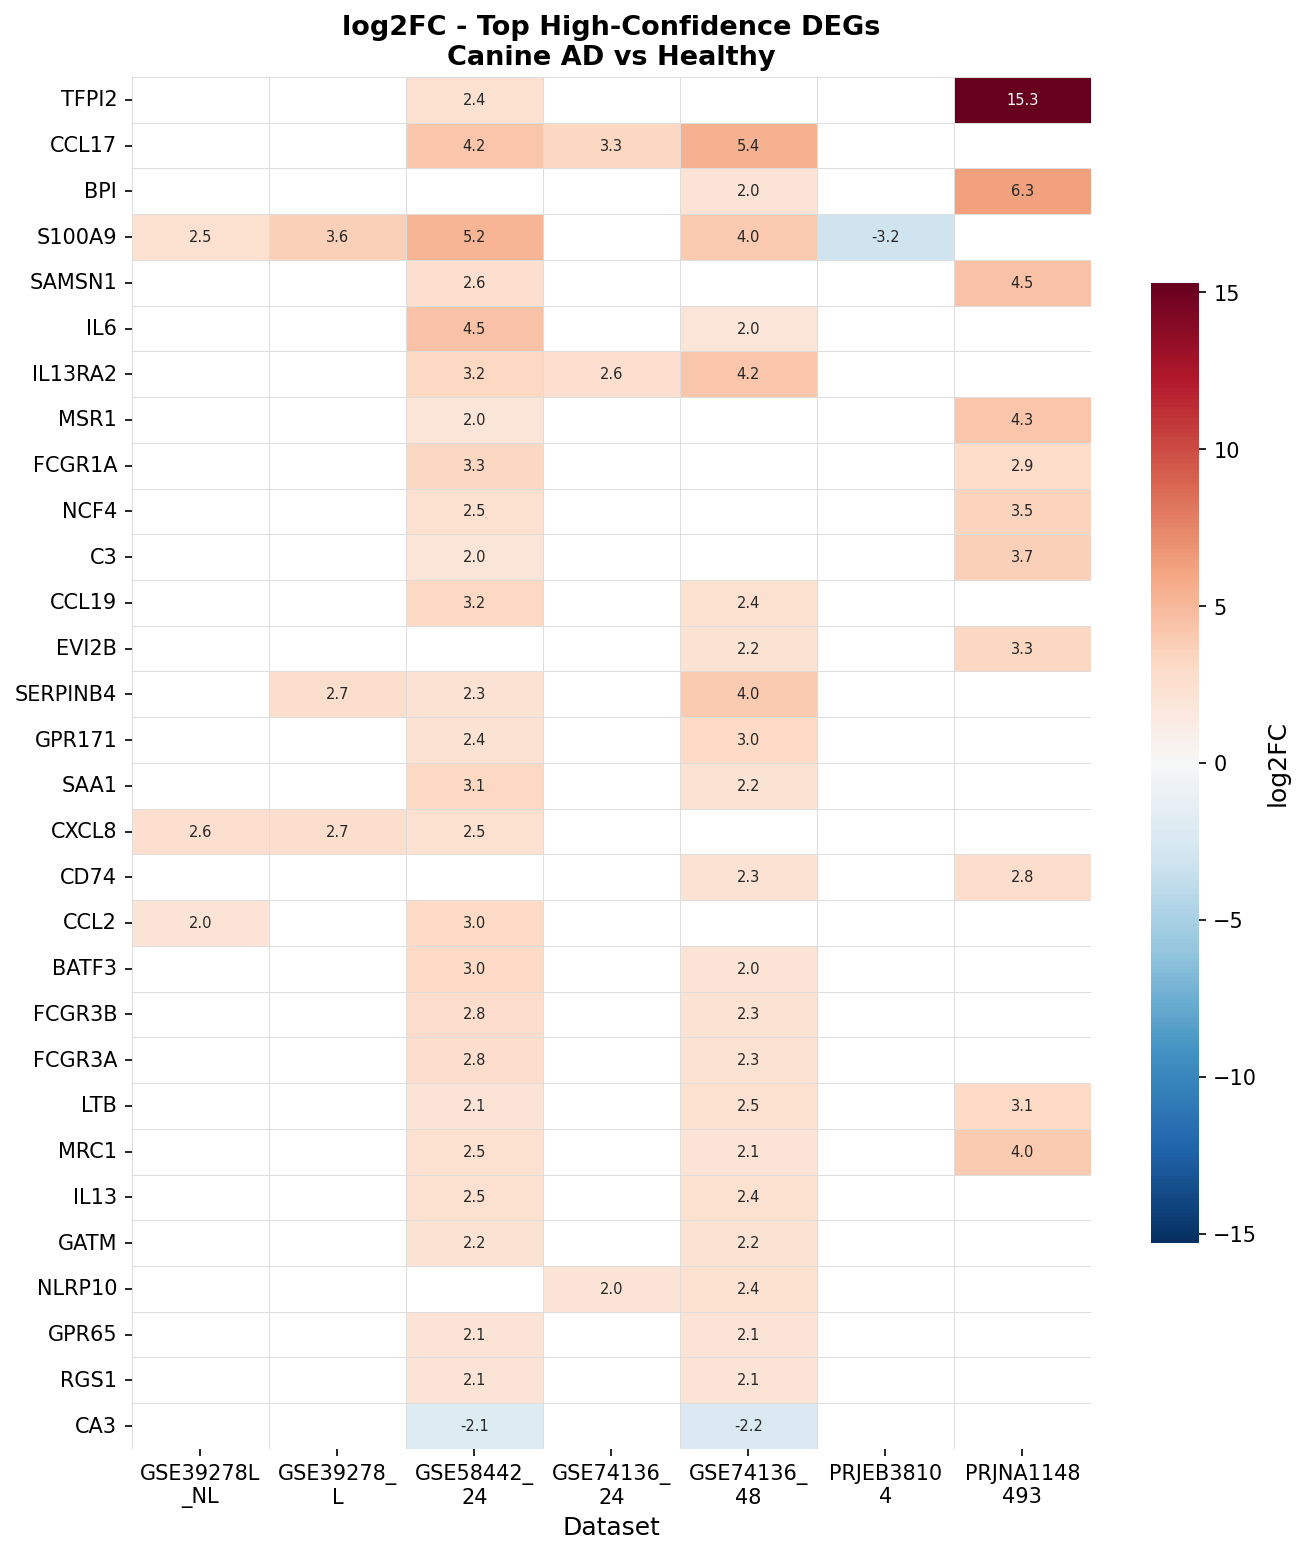

  Figure saved → figures/Fig07_log2FC_heatmap_highconf_Canine_AD_vs_Healthy.pdf
  Figure saved → figures/Fig07_log2FC_heatmap_highconf_Canine_AD_vs_Healthy.svg


In [60]:
# Helper function for formatting labels with line breaks
def _format_label_with_breaks(label, max_len=9):
    if len(label) <= max_len:
        return label
    parts = []
    for i in range(0, len(label), max_len):
        parts.append(label[i:i+max_len])
    return '\n'.join(parts)

for comp_name, comp_df in all_cleaned.items():
    if comp_name not in meta_summaries:
        continue
    summary = meta_summaries[comp_name]
    hc = summary[(summary['DEG_confidence']=='High-confidence') &
                 (~summary['exclude_viz'])]
    if len(hc) == 0:
        print(f'  No high-confidence genes for {comp_name} — skipping')
        continue

    top_genes = hc.head(30)['Gene_Symbol'].tolist()
    cdf       = comp_df[~comp_df['exclude_viz']]
    datasets  = sorted(cdf['dataset'].unique())

    mat = pd.DataFrame(np.nan, index=top_genes, columns=datasets)
    for ds in datasets:
        dsdf = cdf[cdf['dataset']==ds].set_index('Gene_Symbol')
        for g in top_genes:
            if g in dsdf.index:
                mat.loc[g, ds] = dsdf.loc[g,'log2FC']

    mat['_med'] = mat.median(axis=1)
    mat = mat.sort_values('_med', ascending=False).drop(columns='_med')
    vmax = np.nanmax(np.abs(mat.values)) if not np.all(np.isnan(mat.values)) else 1

    fig, ax = plt.subplots(figsize=(max(5, len(datasets)*1.3),
                                     max(6, len(mat)*0.35)))
    sns.heatmap(mat.astype(float), cmap='RdBu_r', center=0,
                vmin=-vmax, vmax=vmax,
                linewidths=0.4, linecolor='#dddddd',
                cbar_kws={'label':'log2FC','shrink':0.7},
                annot=True, # Changed from len(mat)<=20 to True to always show values
                fmt='.1f', # Changed from conditional formatting to always '.1f'
                annot_kws={'size':7}, ax=ax)
    ax.set_title(
        f'log2FC - Top High-Confidence DEGs\n{comp_name.replace("_"," ")}',
        fontweight='bold')
    ax.set_xlabel('Dataset')
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=10)

    # Apply line breaks to x-axis labels from the 'datasets' list
    formatted_xlabels = [_format_label_with_breaks(label, max_len=9) for label in datasets]

    # Set new x-tick labels with desired rotation (0 degrees for horizontal) and alignment
    ax.set_xticks(np.arange(len(datasets)) + 0.5) # +0.5 to center ticks for heatmap cells
    ax.set_xticklabels(formatted_xlabels, rotation=0, ha='center', fontsize=10)

    fig.tight_layout()

    # Save as PNG
    png_filename = f'Fig07_log2FC_heatmap_highconf_{comp_name}.png'
    save_fig(fig, png_filename)

    # Save as PDF
    pdf_filename = f'Fig07_log2FC_heatmap_highconf_{comp_name}.pdf'
    pdf_path = os.path.join(DIR_FIG, pdf_filename)
    fig.savefig(pdf_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'  Figure saved → figures/{pdf_filename}')

    # Save as SVG
    svg_filename = f'Fig07_log2FC_heatmap_highconf_{comp_name}.svg'
    svg_path = os.path.join(DIR_FIG, svg_filename)
    fig.savefig(svg_path, bbox_inches='tight', facecolor='white')
    print(f'  Figure saved → figures/{svg_filename}')

    plt.close(fig) # Close the figure to free up memory

### **Figure 8 - DEG Confidence Category Breakdown**


  Figure saved → figures/Fig08_confidence_breakdown_vote.png


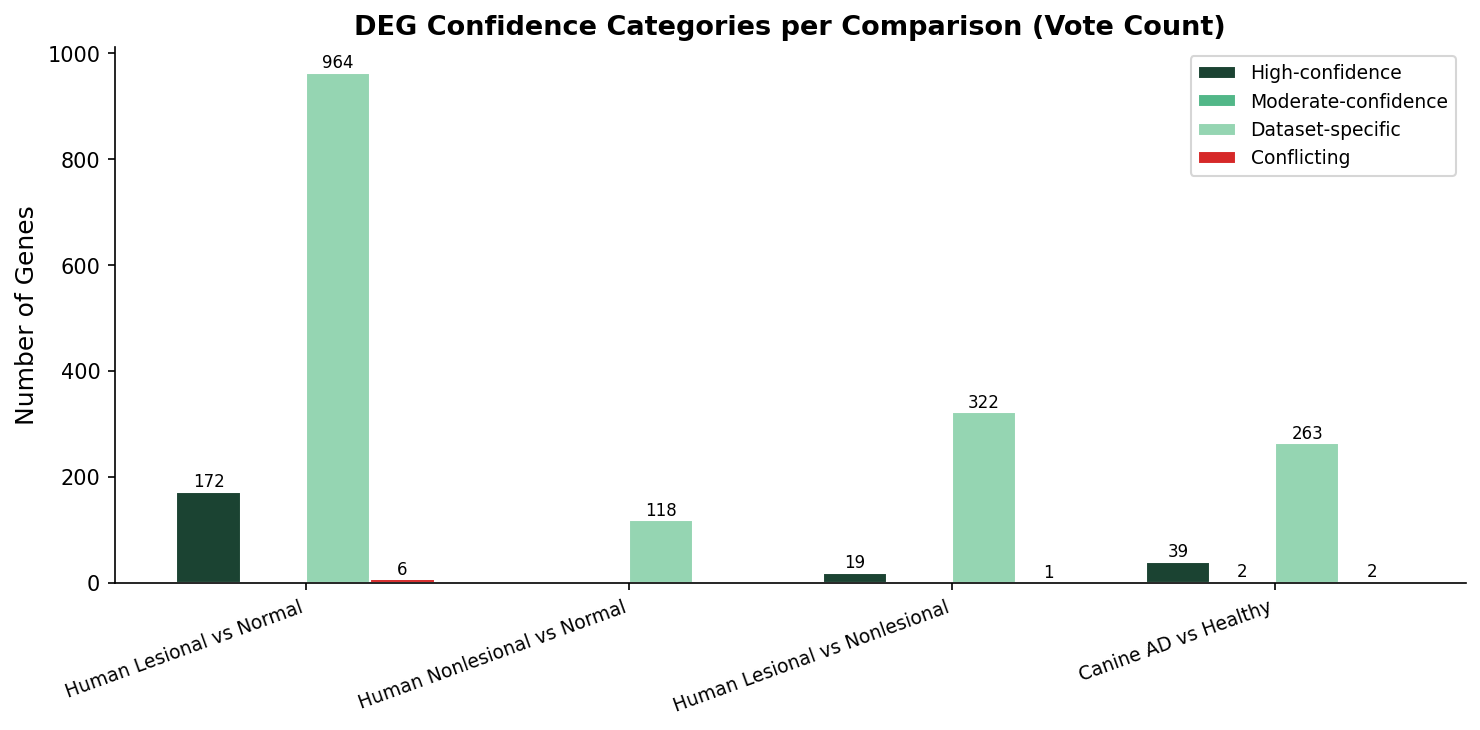

In [29]:
conf_order  = ['High-confidence','Moderate-confidence','Dataset-specific','Conflicting']
comp_labels = list(meta_summaries.keys())
x     = np.arange(len(comp_labels))
width = 0.2

fig, ax = plt.subplots(figsize=(max(9, len(comp_labels)*2.5), 5))
for i, tier in enumerate(conf_order):
    counts = [((meta_summaries[c]['DEG_confidence']==tier) &
               (~meta_summaries[c]['exclude_viz'])).sum()
              for c in comp_labels]
    bars = ax.bar(x+i*width, counts, width,
                  label=tier, color=CONF_COLORS[tier], edgecolor='white')
    for bar, val in zip(bars, counts):
        if val > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                    str(val), ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels([c.replace('_',' ') for c in comp_labels],
                   rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Number of Genes')
ax.set_title('DEG Confidence Categories per Comparison (Vote Count)',
             fontweight='bold')
ax.legend(framealpha=0.8, fontsize=9)
fig.tight_layout()
save_fig(fig, 'Fig08_confidence_breakdown_vote.png')


### **Figure 9 - Dataset Support vs Median log2FC (Bubble Plot)**


  Figure saved → figures/Fig09_bubble_support_vs_FC_Human_Lesional_vs_Normal.png


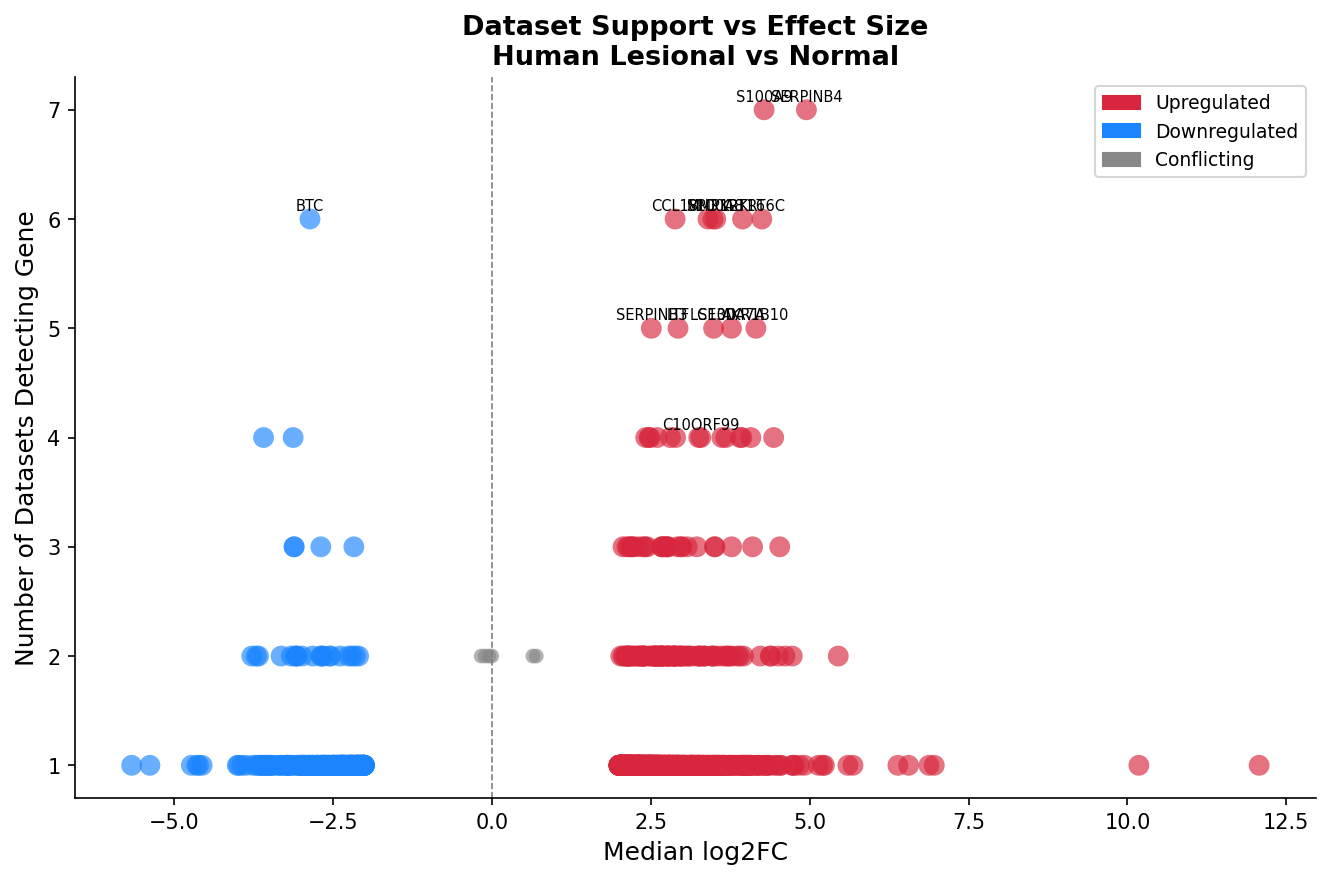

  Figure saved → figures/Fig09_bubble_support_vs_FC_Human_Nonlesional_vs_Normal.png


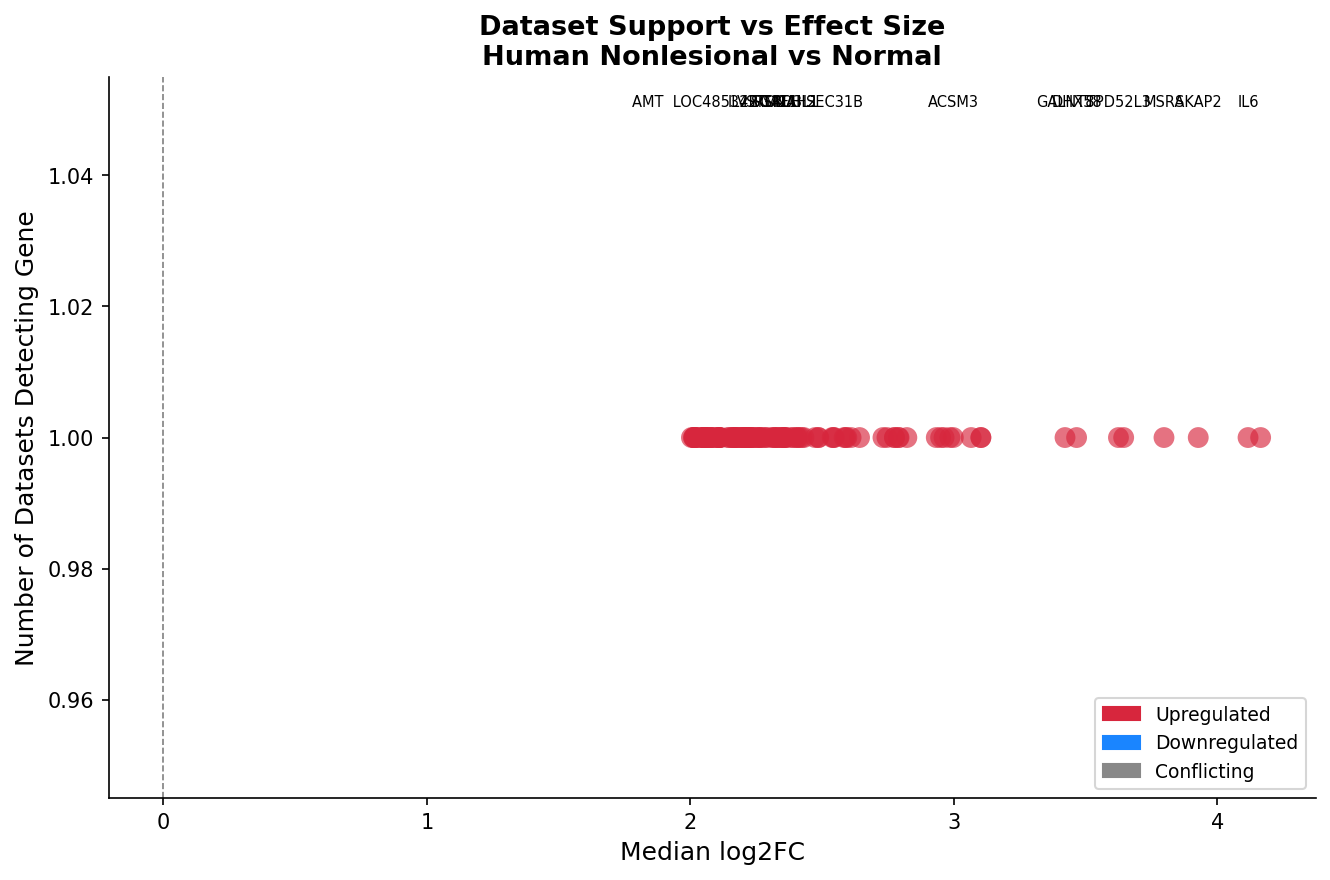

  Figure saved → figures/Fig09_bubble_support_vs_FC_Human_Lesional_vs_Nonlesional.png


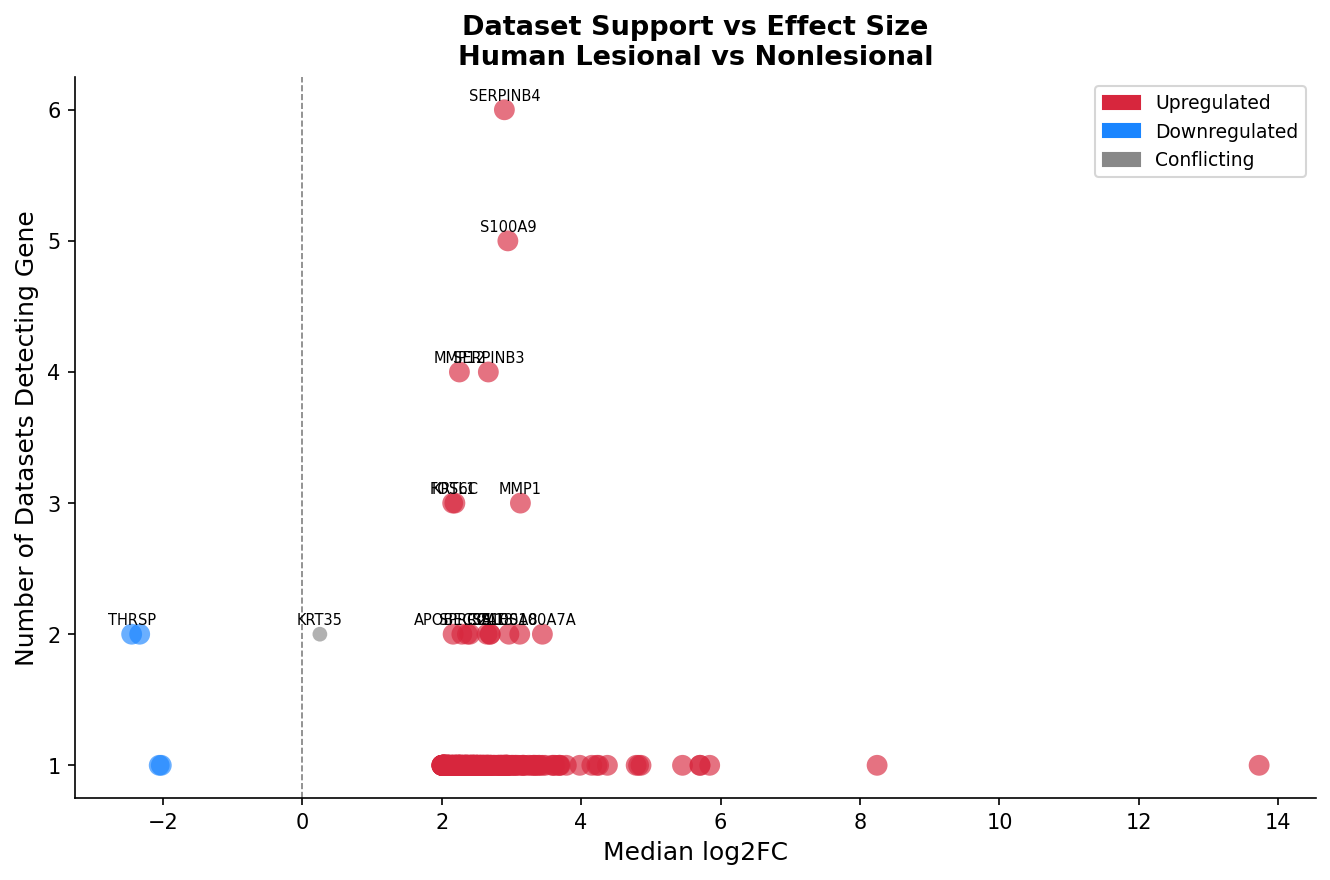

  Figure saved → figures/Fig09_bubble_support_vs_FC_Canine_AD_vs_Healthy.png


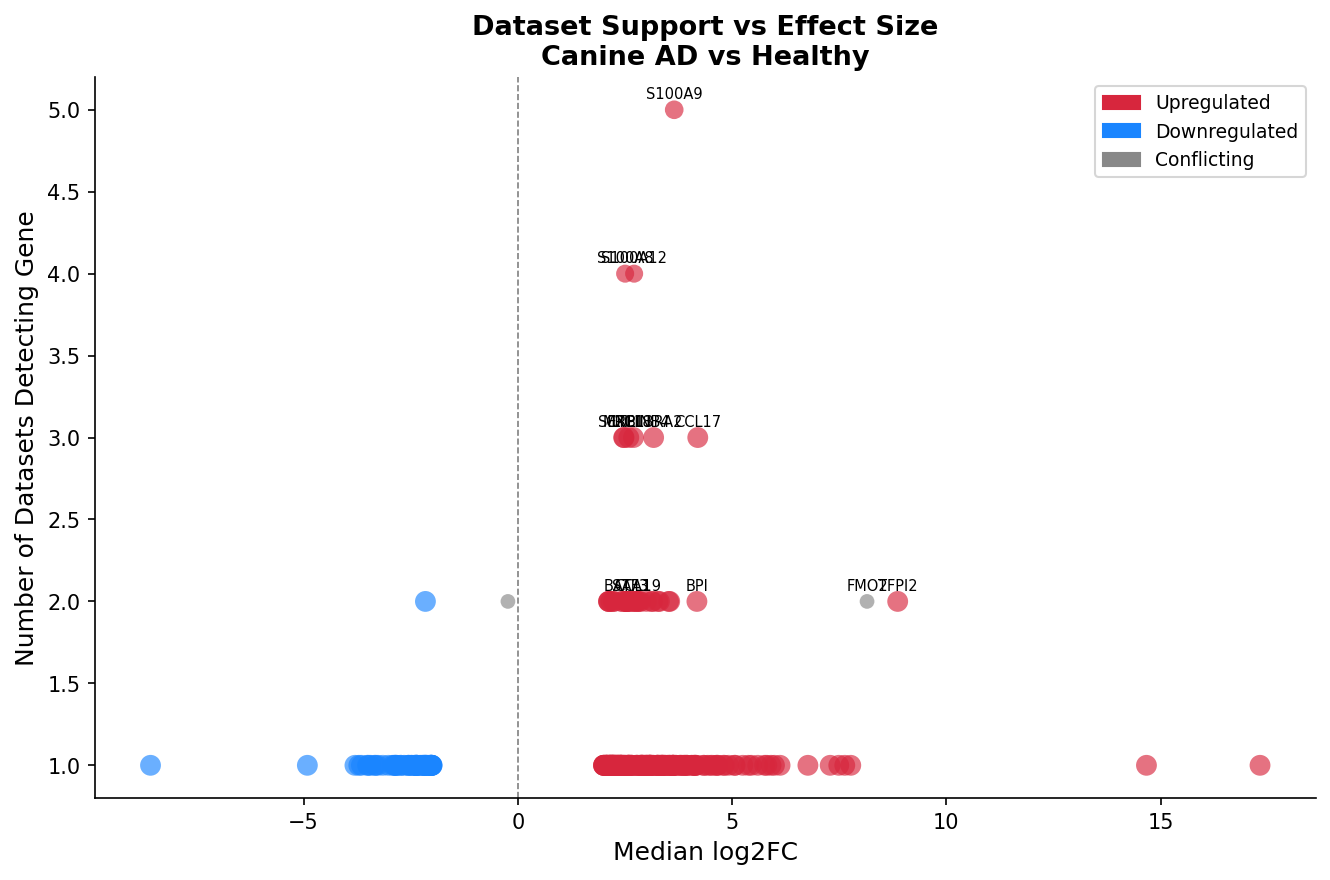

In [30]:
for comp_name, summary in meta_summaries.items():
    s = summary[~summary['exclude_viz']].copy()
    if len(s) == 0:
        continue
    s['color'] = s['consensus_direction'].map({
        'Upregulated'  : PALETTE['Upregulated'],
        'Downregulated': PALETTE['Downregulated'],
        'Conflicting'  : '#888888',
    }).fillna('#888888')
    sizes = (s['direction_consistency']*100).clip(lower=10)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(s['median_log2FC'], s['n_datasets_detected'],
               c=s['color'], s=sizes, alpha=0.65, linewidths=0)
    top15 = s.nlargest(15, 'n_datasets_detected')
    for _, row in top15.iterrows():
        ax.text(row['median_log2FC'], row['n_datasets_detected']+0.05,
                row['Gene_Symbol'], fontsize=7, ha='center', va='bottom')
    ax.axvline(0, color='grey', lw=0.8, linestyle='--')
    ax.set_xlabel('Median log2FC')
    ax.set_ylabel('Number of Datasets Detecting Gene')
    ax.set_title(
        f'Dataset Support vs Effect Size\n{comp_name.replace("_"," ")}',
        fontweight='bold')
    patches = [mpatches.Patch(color=PALETTE['Upregulated'],   label='Upregulated'),
               mpatches.Patch(color=PALETTE['Downregulated'], label='Downregulated'),
               mpatches.Patch(color='#888888',                label='Conflicting')]
    ax.legend(handles=patches, framealpha=0.8, fontsize=9)
    fig.tight_layout()
    save_fig(fig, f'Fig09_bubble_support_vs_FC_{comp_name}.png')


### **Figure 10 - Direction Consistency Score Distribution**

  Figure saved → figures/Fig10_direction_consistency.png


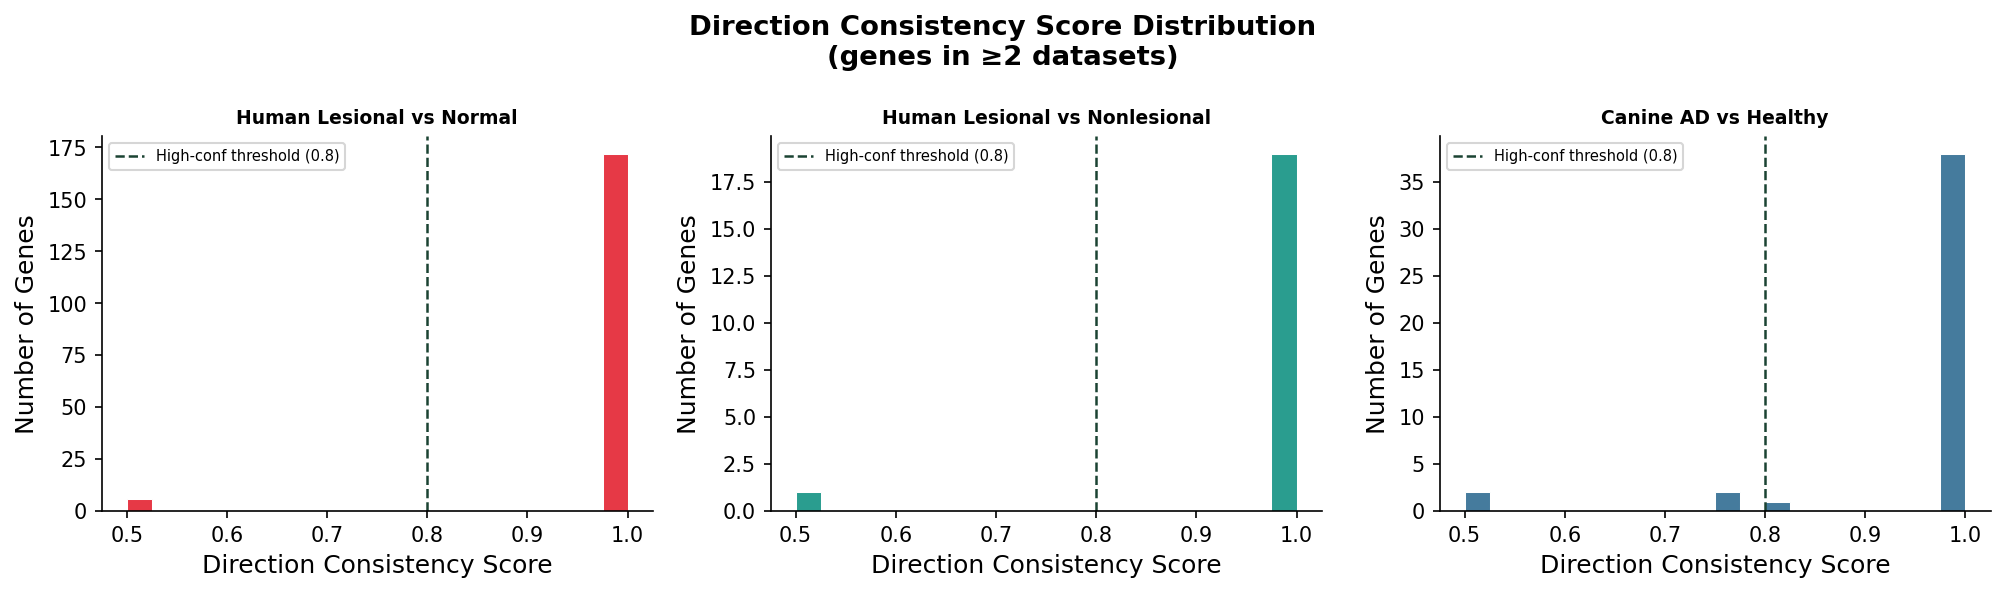

In [31]:
comps_multi = {k: v for k,v in meta_summaries.items()
               if int(v['total_datasets'].iloc[0]) >= 2}

if comps_multi:
    n = len(comps_multi)
    fig, axes = plt.subplots(1, n, figsize=(n*4.5, 4), sharey=False)
    if n == 1:
        axes = [axes]
    for ax, (comp_name, summary) in zip(axes, comps_multi.items()):
        s = summary[(summary['n_datasets_detected'] >= 2) &
                    (~summary['exclude_viz'])]
        if len(s) == 0:
            ax.set_visible(False)
            continue
        ax.hist(s['direction_consistency'], bins=20,
                color=COMP_COLORS.get(comp_name,'#888'),
                edgecolor='white', linewidth=0.5)
        ax.axvline(0.8, color='#1B4332', linestyle='--', lw=1.2,
                   label='High-conf threshold (0.8)')
        ax.set_title(comp_name.replace('_',' '), fontsize=9, fontweight='bold')
        ax.set_xlabel('Direction Consistency Score')
        ax.set_ylabel('Number of Genes')
        ax.legend(fontsize=7)
    fig.suptitle(
        'Direction Consistency Score Distribution\n(genes in ≥2 datasets)',
        fontweight='bold')
    fig.tight_layout()
    save_fig(fig, 'Fig10_direction_consistency.png')


## **Step 10 - Fisher + Stouffer Meta-Analysis**

### **Why meta-analysis on top of vote-counting?**

Vote-counting (Step 9) is transparent and useful for supplementary tables,
but it ignores the actual p-value magnitudes.  A gene with p=0.001 in 2 datasets
is ranked the same as p=0.049 in 2 datasets. Meta-analysis fixes this:

**Fisher's combined test** — omnibus: did *any* dataset detect a real signal?
> χ² = −2 × Σ ln(pᵢ),  df = 2k  → one p-value per gene

**Stouffer's Z** — direction-aware: do datasets *agree* on the direction?
> Z = Σ [sign(FCᵢ) × Φ⁻¹(1−pᵢ/2)] / √k

If a gene goes up in half the datasets and down in the other half, the Z-scores
cancel → not significant. Vote-counting would score this as "Conflicting" but
still show it as replicated; Stouffer correctly kills it statistically.

**π-value** = |Median log2FC| × −log₁₀(Stouffer FDR)  
Combines effect size with significance for ranked gene lists.

**Unified confidence tier** (replaces vote-count tier for final output):
- **High-confidence** : ≥2 datasets, both FDR<0.05, consistency ≥0.8
- **Moderate-confidence**: ≥2 datasets, both FDR<0.05, consistency 0.6–0.79
- **Conflicting** : ≥2 datasets, both FDR<0.05, but consistency <0.6
- **Not-significant** : ≥2 datasets but FDR failed
- **Dataset-specific** : seen in only 1 dataset

> ⚠ **Human NLN (2 datasets):** Fisher/Stouffer are mathematically valid
> but interpret results cautiously given the low dataset count.


In [32]:
def _signed_z(p, fc):
    """Convert a p-value + fold change sign into a signed Z-score."""
    p = np.clip(float(p), 1e-300, 1-1e-15)
    z = stats.norm.ppf(1 - p/2)
    return z * np.sign(float(fc))

def run_meta_analysis(comp_name, min_ds=2):
    """
    Fisher + Stouffer meta-analysis for one comparison.
    Returns DataFrame with one row per gene present in >= min_ds datasets.
    """
    pmat  = matrices[comp_name]['pvalue']
    fcmat = matrices[comp_name]['log2FC']
    n_total_datasets = pmat.shape[1]

    print(f'\n{"="*60}')
    print(f'  {comp_name}')
    print(f'  Datasets ({n_total_datasets}): {list(pmat.columns)}')
    if n_total_datasets == 2:
        print(f'  ⚠  Only 2 datasets — results valid but interpret with caution')

    records = []
    for gene in pmat.index:
        pr   = pmat.loc[gene]
        fcr  = fcmat.loc[gene]
        mask = pr.notna() & fcr.notna()
        n    = int(mask.sum())
        if n < min_ds:
            continue

        pv = pr[mask].astype(float).values
        fc = fcr[mask].astype(float).values
        ds = list(pr[mask].index)

        # Fisher combined test
        fish_stat = float(-2 * np.sum(np.log(np.clip(pv, 1e-300, 1))))
        fish_p    = float(stats.chi2.sf(fish_stat, df=2*n))

        # Stouffer Z (direction-aware)
        zs     = [_signed_z(p, f) for p, f in zip(pv, fc)]
        stou_z = float(np.sum(zs) / np.sqrt(n))
        stou_p = float(2 * stats.norm.sf(abs(stou_z)))

        n_up   = int(np.sum(fc > 0))
        n_down = int(n - n_up)
        cons   = float(max(n_up, n_down) / n)

        records.append({
            'Gene_Symbol'          : gene,
            'n_datasets_detected'  : n,
            'total_datasets'       : n_total_datasets,
            'pct_datasets'         : round(100*n/n_total_datasets, 1),
            'datasets'             : ';'.join(ds),
            'n_up'                 : n_up,
            'n_down'               : n_down,
            'direction_consistency': round(cons, 3),
            'consensus_direction'  : ('Upregulated' if n_up > n_down else
                                      'Downregulated' if n_down > n_up else
                                      'Conflicting'),
            'median_log2FC'        : round(float(np.median(fc)), 4),
            'mean_log2FC'          : round(float(np.mean(fc)),   4),
            'min_p_value'          : float(np.min(pv)),
            'median_p_value'       : float(np.median(pv)),
            'Fisher_stat'          : round(fish_stat, 4),
            'Fisher_p'             : fish_p,
            'Stouffer_Z'           : round(stou_z, 4),
            'Stouffer_p'           : stou_p,
        })

    if not records:
        print('  No genes found in ≥2 datasets')
        return pd.DataFrame()

    df = pd.DataFrame(records)

    # BH FDR correction
    _, fadj, _, _ = multipletests(df['Fisher_p'],   method='fdr_bh')
    _, sadj, _, _ = multipletests(df['Stouffer_p'], method='fdr_bh')
    df['Fisher_padj']   = fadj
    df['Stouffer_padj'] = sadj

    # Significance: BOTH FDR < 0.05
    df['meta_significant'] = (df['Fisher_padj'] < 0.05) & (df['Stouffer_padj'] < 0.05)

    # π-value
    df['pi_value'] = (df['median_log2FC'].abs() *
                      (-np.log10(df['Stouffer_padj'].clip(lower=1e-300)))).round(4)

    # Unified confidence tier
    def _tier(row):
        sig  = row['meta_significant']
        n    = row['n_datasets_detected']
        cons = row['direction_consistency']
        if n >= 2 and sig and cons >= 0.8:
            return 'High-confidence'
        elif n >= 2 and sig and cons >= 0.6:
            return 'Moderate-confidence'
        elif n >= 2 and sig and cons < 0.6:
            return 'Conflicting'
        elif n >= 2 and not sig:
            return 'Not-significant'
        else:
            return 'Dataset-specific'

    df['DEG_confidence'] = df.apply(_tier, axis=1)
    df['exclude_viz']    = df['Gene_Symbol'].apply(exclude_from_viz)

    # Sort: significant first, then by π-value descending
    df = (df.sort_values(['meta_significant','pi_value'], ascending=[False,False])
            .reset_index(drop=True))

    # Print summary
    n_sig = int(df['meta_significant'].sum())
    n_up  = int(df[df['meta_significant'] &
                    (df['consensus_direction']=='Upregulated')].shape[0])
    n_dn  = int(df[df['meta_significant'] &
                    (df['consensus_direction']=='Downregulated')].shape[0])
    tiers = df[~df['exclude_viz']]['DEG_confidence'].value_counts()

    print(f'  Genes tested (≥{min_ds} datasets)       : {len(df):,}')
    print(f'  Meta-significant (both FDR<0.05) : {n_sig}')
    print(f'    ↑ Upregulated   : {n_up}')
    print(f'    ↓ Downregulated : {n_dn}')
    print(f'  Confidence tiers (viz-eligible):')
    for tier in TIER_ORDER:
        print(f'    {tier:<25}: {tiers.get(tier,0)}')
    if n_sig > 0:
        top5 = (df[df['meta_significant'] & ~df['exclude_viz']]
                .head(5)[['Gene_Symbol','n_datasets_detected','median_log2FC',
                           'consensus_direction','Stouffer_padj','pi_value']])
        print(f'  Top 5 by π-value:')
        print(top5.to_string(index=False))
    return df

print('Meta-analysis function defined.')


Meta-analysis function defined.


### **Run Meta-Analysis - All 4 Comparisons**


In [33]:
meta_results = {}

for comp_name in COMPARISONS:
    if comp_name not in matrices:
        print(f'⚠  {comp_name}: no matrix — skipping')
        continue
    meta_results[comp_name] = run_meta_analysis(comp_name, min_ds=2)

# Overall summary table
print('\n' + '='*70)
print('META-ANALYSIS SUMMARY')
print('='*70)
summary_rows = []
for comp_name, df in meta_results.items():
    if df.empty:
        continue
    n_sig = int(df['meta_significant'].sum())
    n_up  = int(df[df['meta_significant'] &
                    (df['consensus_direction']=='Upregulated')].shape[0])
    n_dn  = int(df[df['meta_significant'] &
                    (df['consensus_direction']=='Downregulated')].shape[0])
    n_hc  = int(((df['DEG_confidence']=='High-confidence') &
                  ~df['exclude_viz']).sum())
    summary_rows.append({
        'Comparison'      : comp_name.replace('_',' '),
        'Datasets'        : int(df['total_datasets'].iloc[0]),
        'Genes_tested'    : len(df),
        'Meta_sig'        : n_sig,
        'Upregulated'     : n_up,
        'Downregulated'   : n_dn,
        'High_confidence' : n_hc,
    })
meta_summary_df = pd.DataFrame(summary_rows)
print(meta_summary_df.to_string(index=False))



  Human_Lesional_vs_Normal
  Datasets (8): ['GSE121212_L', 'GSE140227_L', 'GSE16161_L', 'GSE32924_L', 'GSE5667_L', 'GSE6012_L', 'GSE75890_L', 'Nomura_L']
  Genes tested (≥2 datasets)       : 181
  Meta-significant (both FDR<0.05) : 176
    ↑ Upregulated   : 147
    ↓ Downregulated : 28
  Confidence tiers (viz-eligible):
    High-confidence          : 172
    Moderate-confidence      : 0
    Conflicting              : 1
    Not-significant          : 5
    Dataset-specific         : 0
  Top 5 by π-value:
Gene_Symbol  n_datasets_detected  median_log2FC consensus_direction  Stouffer_padj  pi_value
      ISG15                    2         5.4510         Upregulated            0.0   1635.30
   SERPINB4                    7         4.9500         Upregulated            0.0   1485.00
       IL26                    2         4.6118         Upregulated            0.0   1383.54
      LCE3A                    3         4.5300         Upregulated            0.0   1359.00
       IL20              

## **Step 11 - Meta-Analysis Visualizations (Figs 11–14)**


### **Figure 11 - Meta-Volcano Plots**
x = median log2FC, y = −log10(Stouffer FDR). Colour = confidence tier. Top genes labelled.


  Figure saved → figures/Fig11_Meta_volcano_plots.png


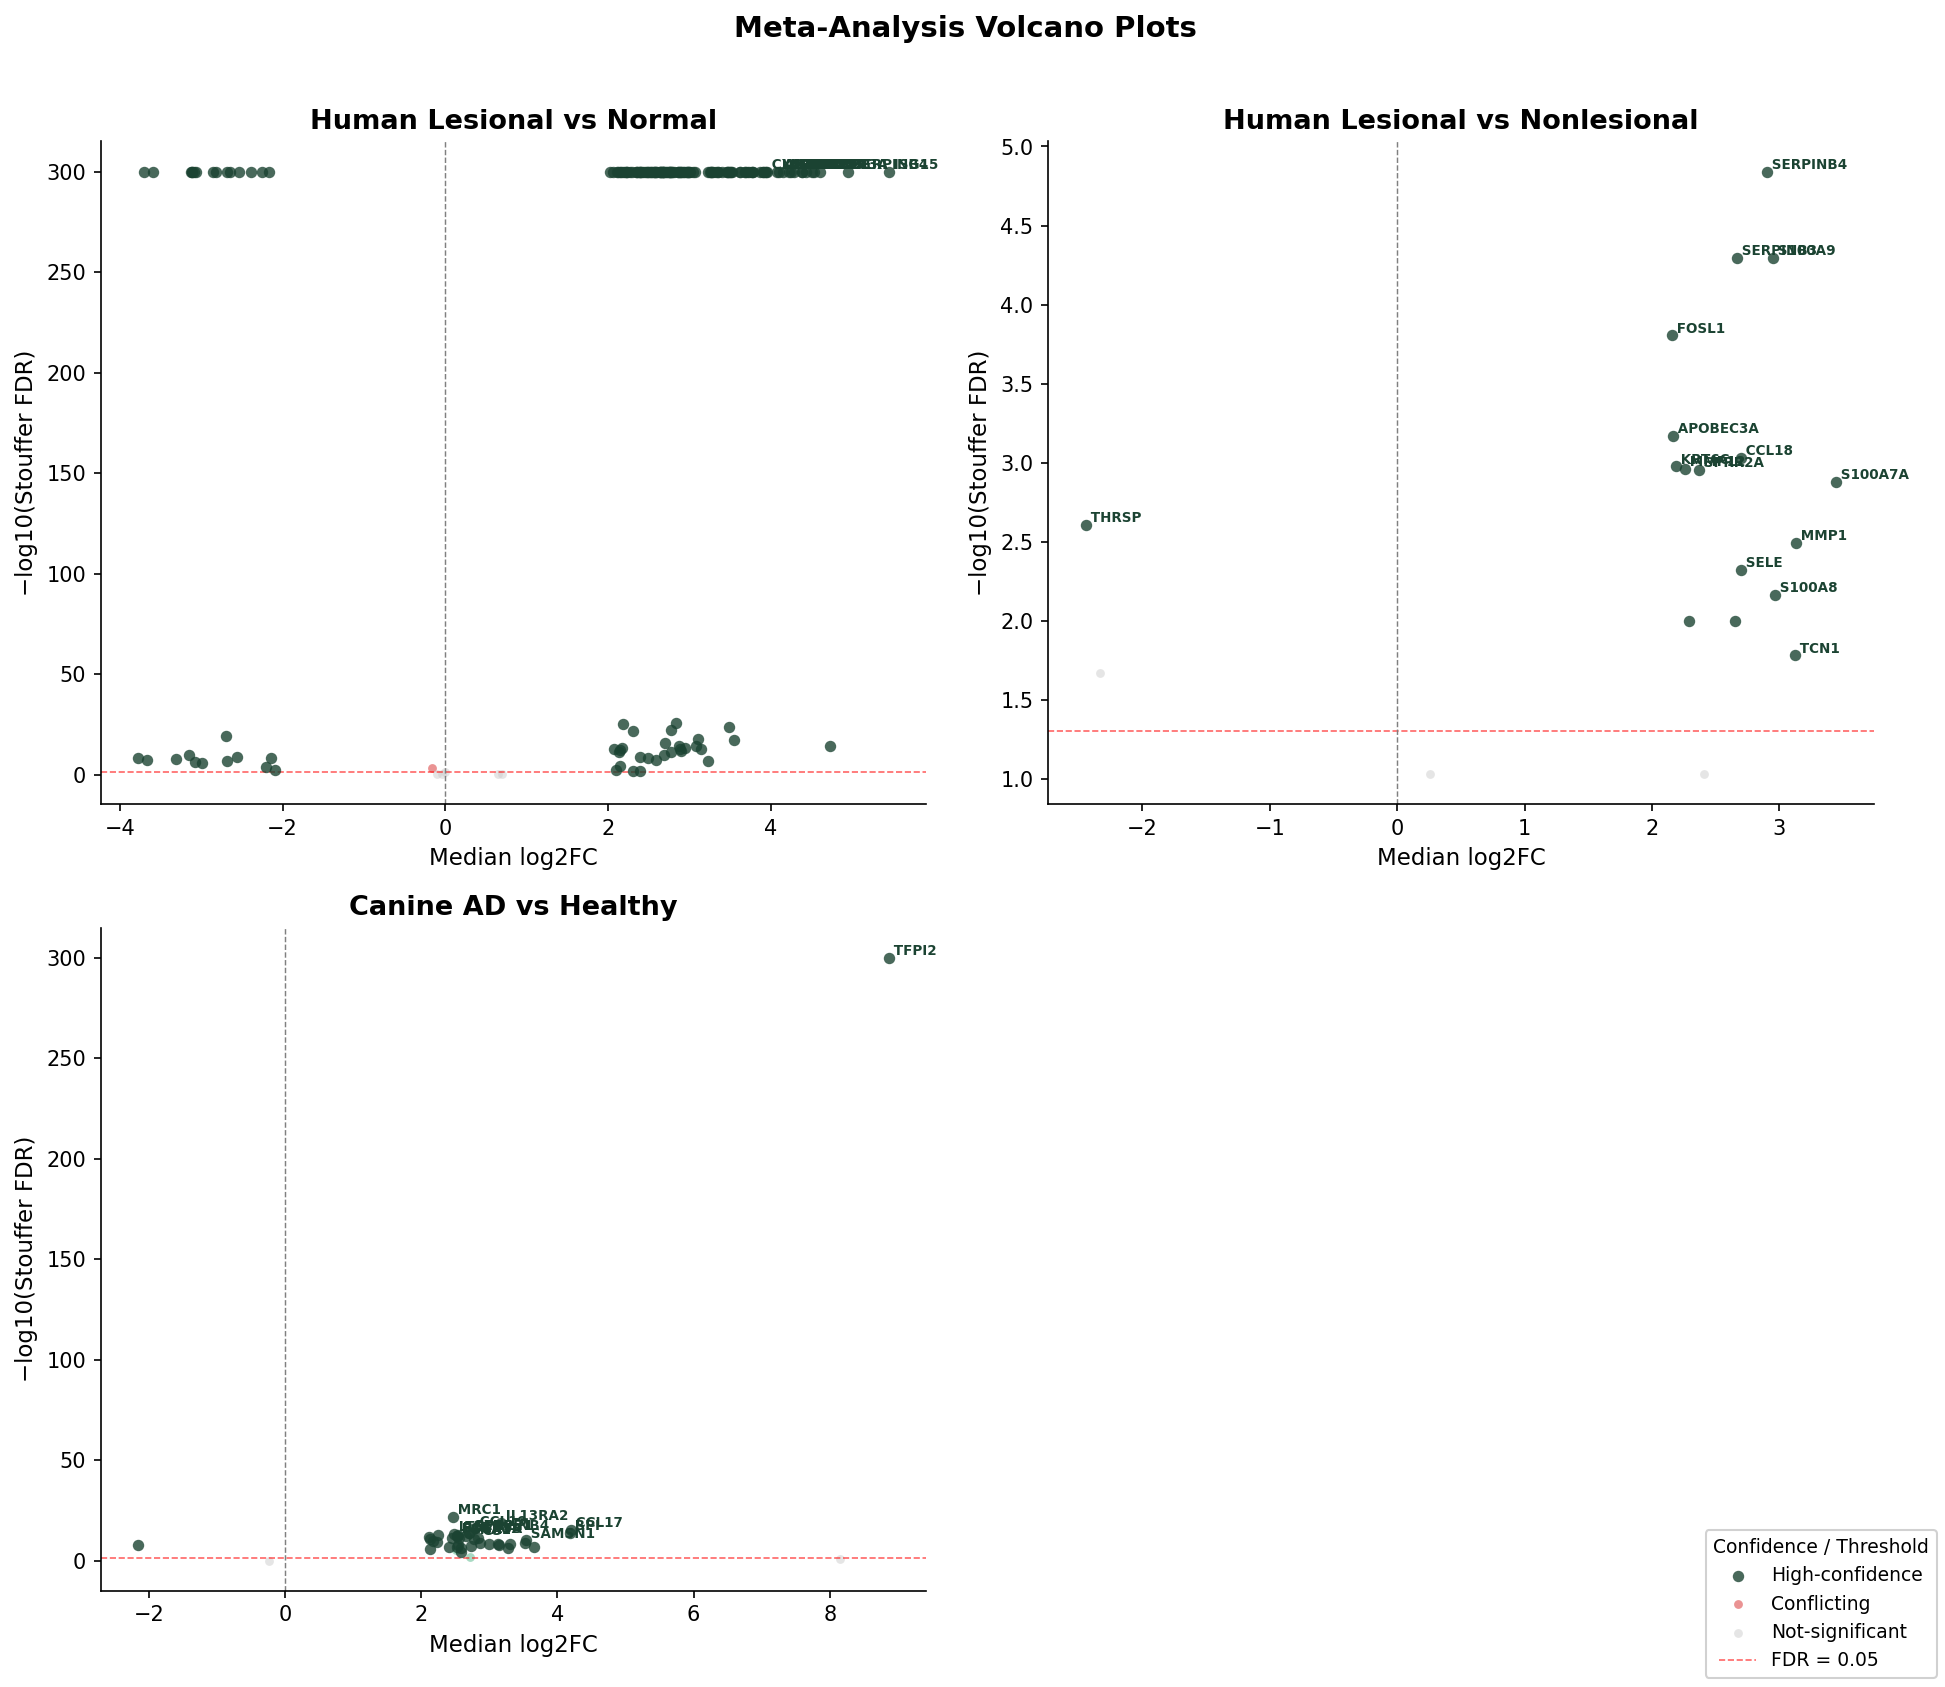

In [34]:
tier_colors = {
    'High-confidence'    : '#1B4332',
    'Moderate-confidence': '#52B788',
    'Not-significant'    : '#cccccc',
    'Conflicting'        : '#D62828',
    'Dataset-specific'   : '#aaaaaa',
}

n_comps = sum(1 for df in meta_results.values() if not df.empty)
ncols   = 2
nrows   = int(np.ceil(n_comps / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6.5, nrows*5.5))
axes_flat  = axes.flatten() if n_comps > 1 else [axes]

plot_idx = 0
for comp_name, df in meta_results.items():
    if df.empty:
        continue
    ax     = axes_flat[plot_idx]
    df_viz = df[~df['exclude_viz']].copy()
    df_viz['nlp'] = -np.log10(df_viz['Stouffer_padj'].clip(lower=1e-300))

    for tier in TIER_ORDER:
        sub = df_viz[df_viz['DEG_confidence']==tier]
        if len(sub) == 0:
            continue
        ax.scatter(sub['median_log2FC'], sub['nlp'],
                   c=tier_colors.get(tier,'#999'),
                   s=30 if tier=='High-confidence' else 18,
                   alpha=0.8 if tier=='High-confidence' else 0.5,
                   linewidths=0, label=tier, zorder=3 if tier=='High-confidence' else 2)

    # Label top 15 high-confidence genes
    top = df_viz[df_viz['DEG_confidence']=='High-confidence'].head(15)
    for _, row in top.iterrows():
        ax.text(row['median_log2FC'], row['nlp'],
                f" {row['Gene_Symbol']}", fontsize=6.5, va='bottom',
                color='#1B4332', fontweight='bold')

    fdr_line = -np.log10(0.05)
    ax.axhline(fdr_line, color='red', lw=0.8, ls='--', alpha=0.6,
               label='FDR = 0.05')
    ax.axvline(0, color='grey', lw=0.7, ls='--')
    ax.set_xlabel('Median log2FC', fontsize=11)
    ax.set_ylabel('−log10(Stouffer FDR)', fontsize=11)
    ax.set_title(comp_name.replace('_',' '), fontweight='bold')
    plot_idx += 1

for j in range(plot_idx, len(axes_flat)):
    axes_flat[j].set_visible(False)

# Shared legend (from last axis)
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=9,
           framealpha=0.9, title='Confidence / Threshold', title_fontsize=9)
fig.suptitle('Meta-Analysis Volcano Plots', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
save_fig(fig, 'Fig11_Meta_volcano_plots.png')


In [35]:
!pip install adjustText

from adjustText import adjust_text
print('adjustText installed.')


adjustText installed.


### **Figure 12 - Ranked Dot Plot: Top 20 Meta-Significant DEGs**
Bubble size = number of datasets; colour = direction; x-axis = π-value.


  Figure saved → figures/Fig12_ranked_dot_Human_Lesional_vs_Normal.png


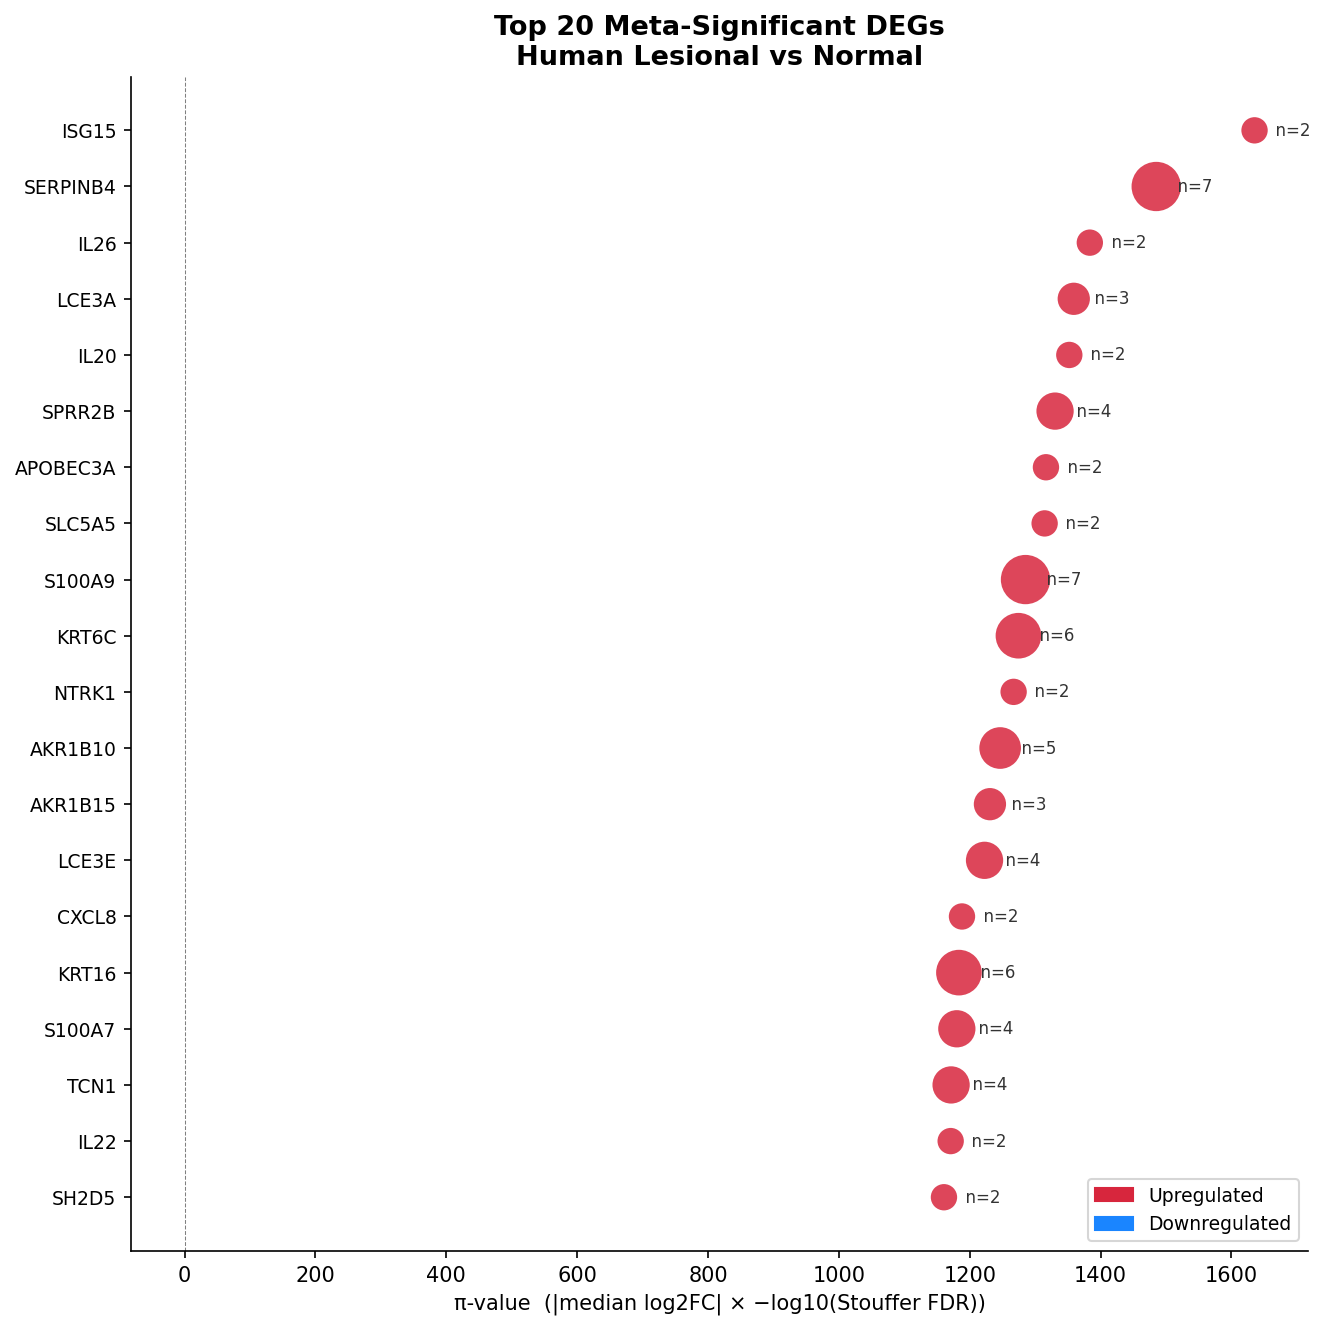

  Figure saved → figures/Fig12_ranked_dot_Human_Lesional_vs_Nonlesional.png


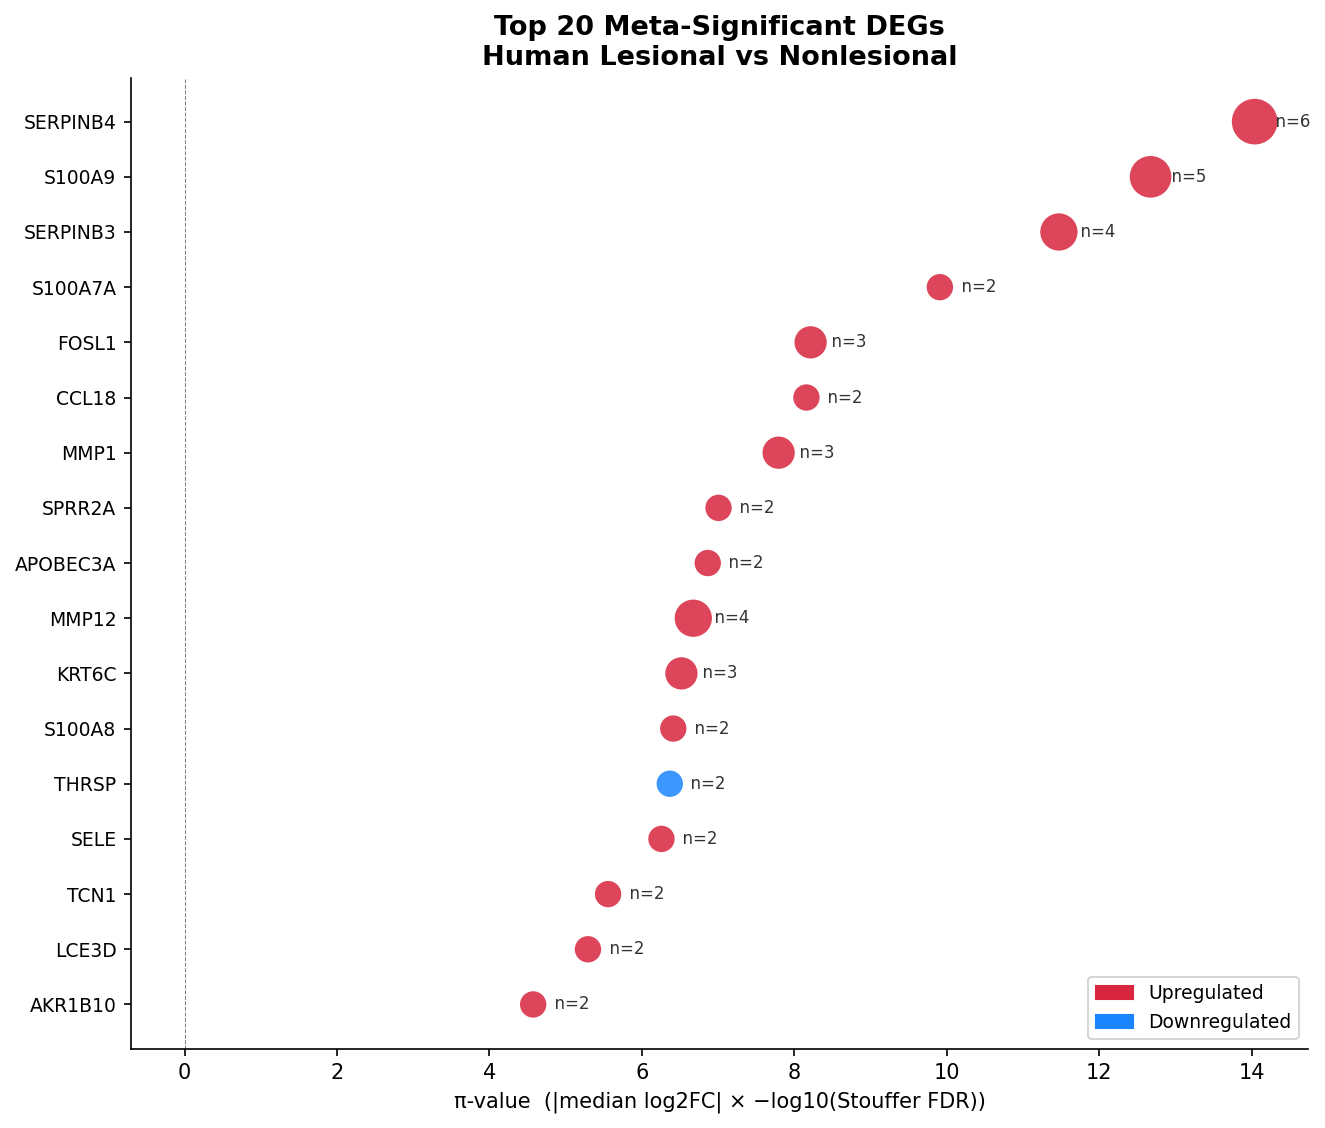

  Figure saved → figures/Fig12_ranked_dot_Canine_AD_vs_Healthy.png


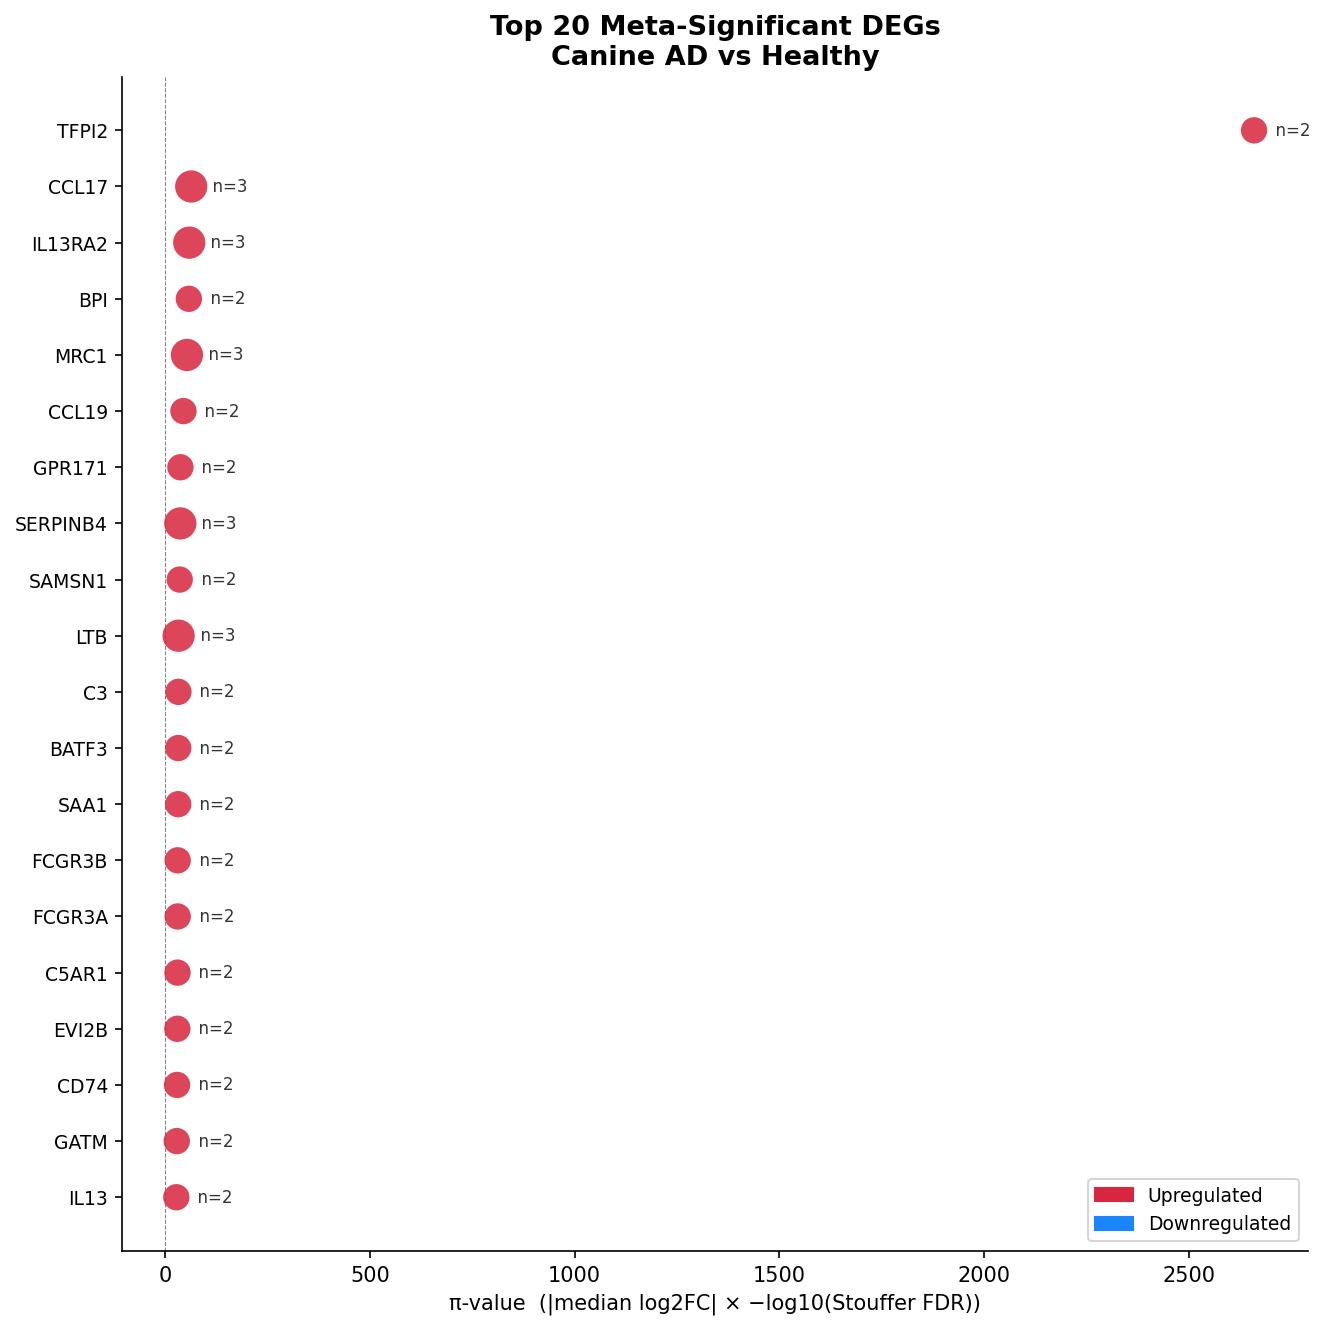

In [36]:
for comp_name, df in meta_results.items():
    if df.empty:
        continue
    plot_df = df[df['meta_significant'] & ~df['exclude_viz']].copy()
    if len(plot_df) == 0:
        print(f'  No meta-significant viz-eligible genes for {comp_name}')
        continue
    plot_df = (plot_df.nlargest(20, 'pi_value')
                      .sort_values('pi_value', ascending=True))

    colors = [PALETTE.get(d, '#888888') for d in plot_df['consensus_direction']]
    sizes  = (plot_df['n_datasets_detected'] * 80).clip(lower=40)

    fig, ax = plt.subplots(figsize=(9, max(5, len(plot_df)*0.45)))
    ax.scatter(plot_df['pi_value'], range(len(plot_df)),
               c=colors, s=sizes, alpha=0.85, linewidths=0, zorder=3)

    # Dataset count annotation
    x_max = plot_df['pi_value'].max()
    for yi, (_, row) in enumerate(plot_df.iterrows()):
        ax.text(row['pi_value'] + x_max*0.01, yi,
                f"  n={int(row['n_datasets_detected'])}",
                va='center', fontsize=8, color='#333')

    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df['Gene_Symbol'], fontsize=9)
    ax.set_xlabel('π-value  (|median log2FC| × −log10(Stouffer FDR))', fontsize=10)
    ax.set_title(
        f'Top 20 Meta-Significant DEGs\n{comp_name.replace("_"," ")}',
        fontweight='bold')
    ax.axvline(0, color='grey', lw=0.5, ls='--')

    patches = [mpatches.Patch(color=v, label=k) for k,v in PALETTE.items()]
    ax.legend(handles=patches, fontsize=9, framealpha=0.8,
              loc='lower right')
    fig.tight_layout()
    save_fig(fig, f'Fig12_ranked_dot_{comp_name}.png')


### **Figure 13 - Forest Plots: Top High-Confidence Genes**
Per-dataset log2FC with 95% CI (estimated from p-value) for top 10 high-confidence genes.


  Figure saved → figures/Fig13_forest_plot_Human_Lesional_vs_Normal.png


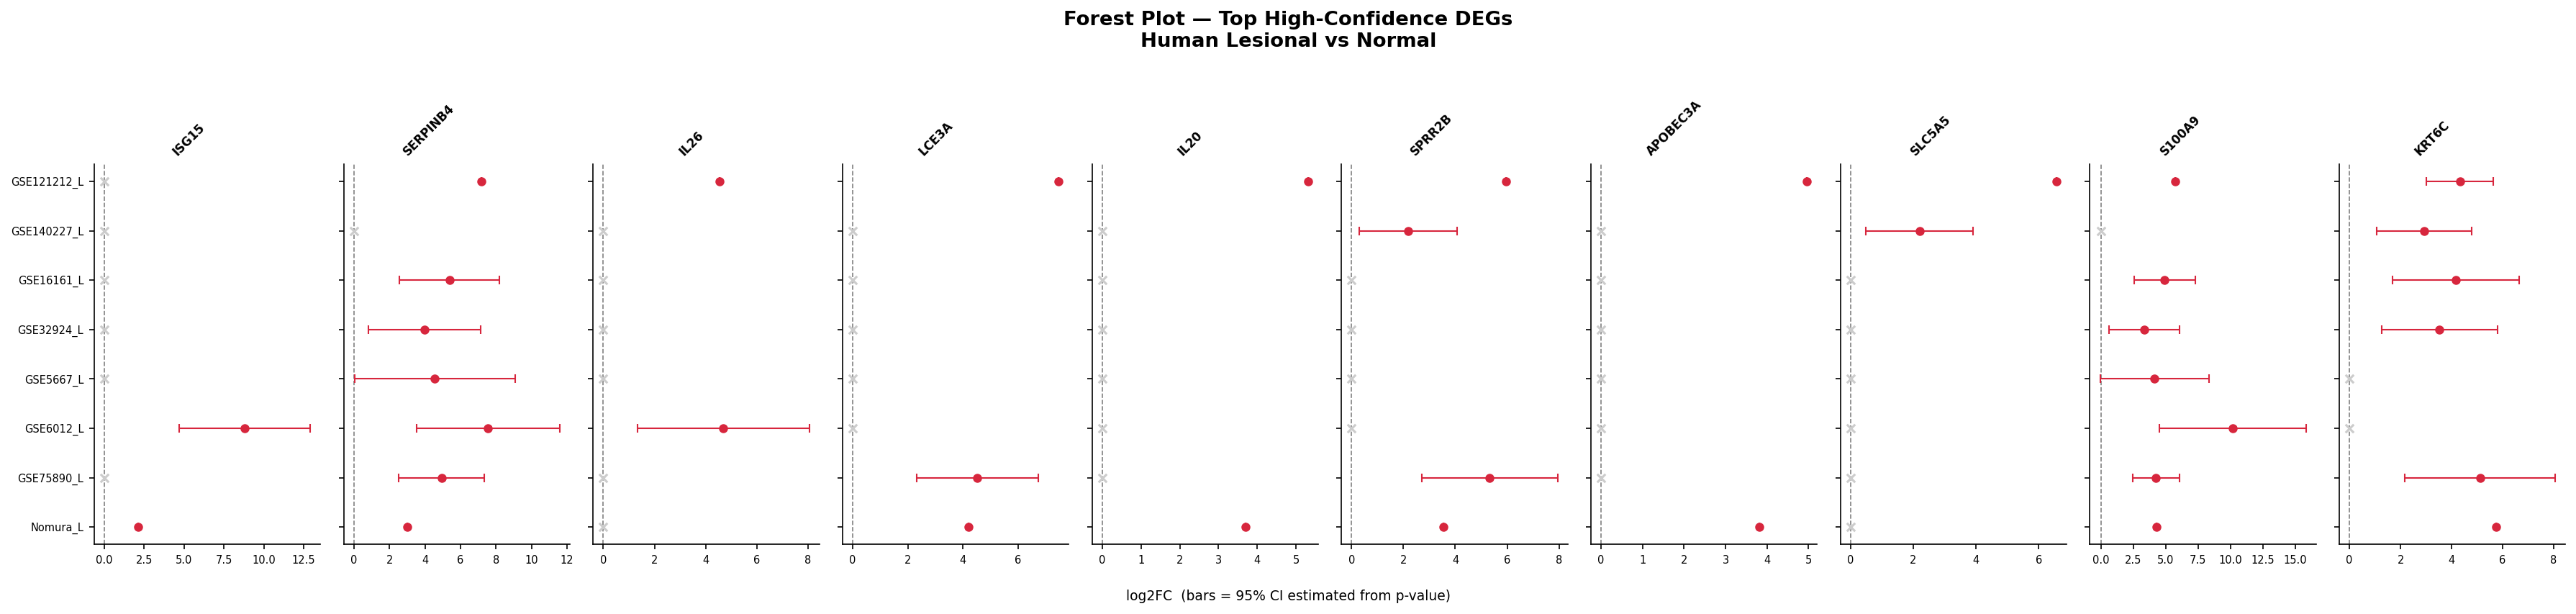

  Figure saved → figures/Fig13_forest_plot_Human_Lesional_vs_Nonlesional.png


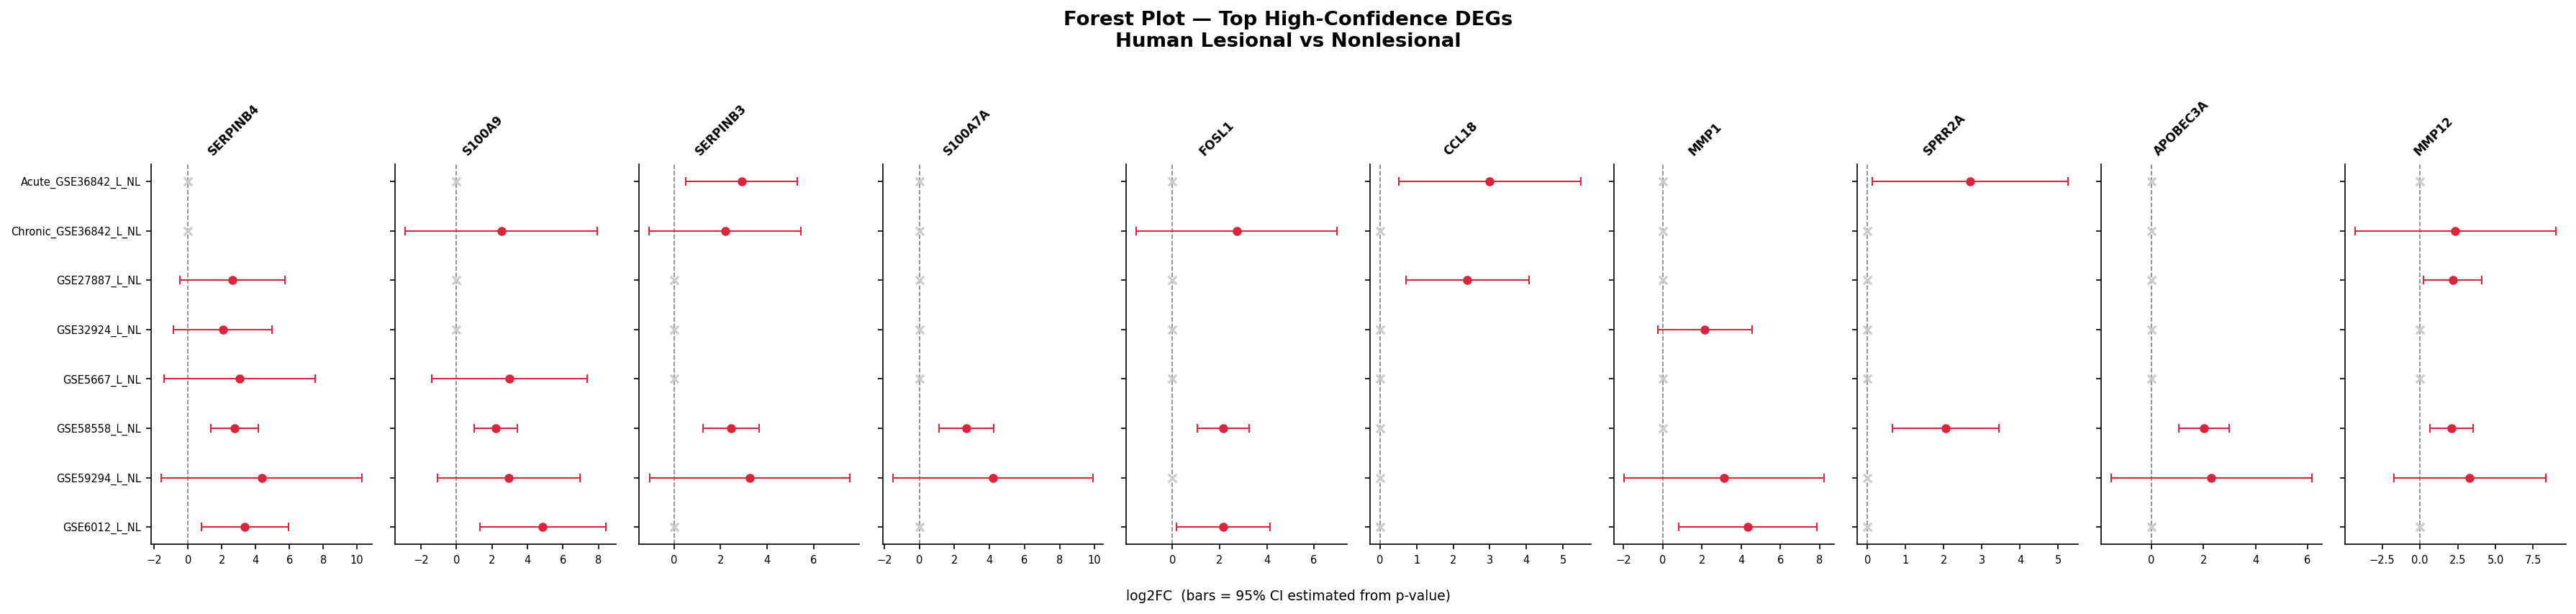

  Figure saved → figures/Fig13_forest_plot_Canine_AD_vs_Healthy.png


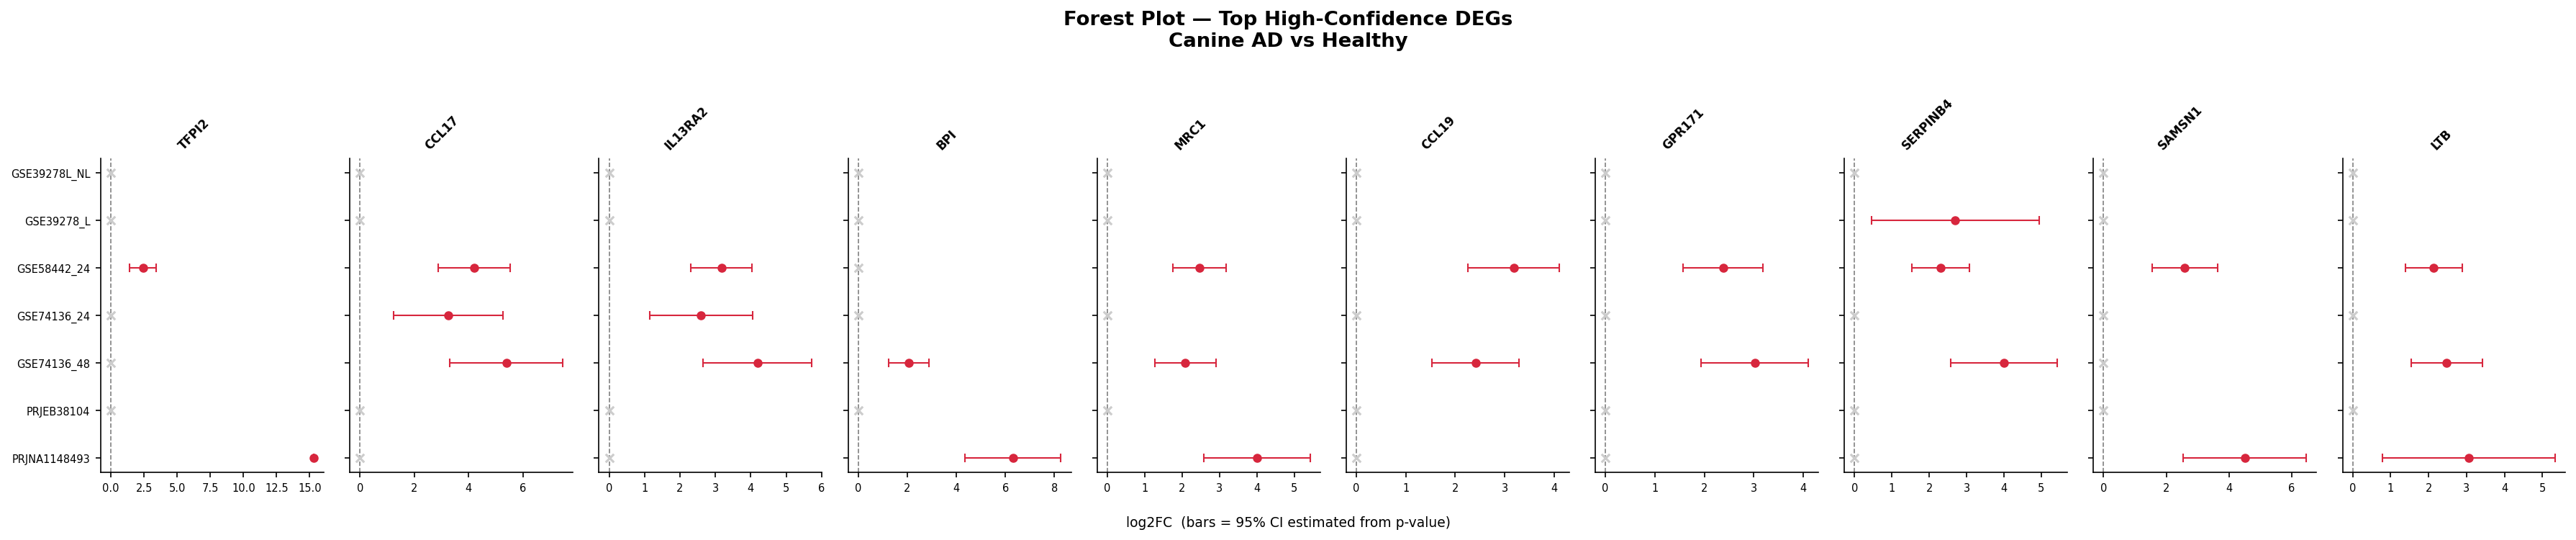

In [37]:
def _approx_se(p, fc):
    """Estimate SE from p-value for forest plot 95% CI bars."""
    p = np.clip(float(p), 1e-300, 1-1e-15)
    z = stats.norm.ppf(1 - p/2)
    return abs(float(fc)) / max(z, 0.01)

for comp_name, df in meta_results.items():
    if df.empty:
        continue
    hc = df[(df['DEG_confidence']=='High-confidence') & ~df['exclude_viz']]
    if len(hc) == 0:
        print(f'  No high-confidence viz-eligible genes for {comp_name}')
        continue

    top_genes = hc.head(10)['Gene_Symbol'].tolist()
    cdf       = all_cleaned[comp_name]
    datasets  = sorted(cdf['dataset'].unique())
    n_ds      = len(datasets)

    fig, axes = plt.subplots(1, len(top_genes),
                              figsize=(len(top_genes)*2.4, max(4, n_ds*0.65)),
                              sharey=True)
    if len(top_genes) == 1:
        axes = [axes]

    ds_rev = list(reversed(datasets))   # bottom-to-top layout
    for ax, gene in zip(axes, top_genes):
        for yi, ds in enumerate(ds_rev):
            gdf = cdf[(cdf['Gene_Symbol']==gene) & (cdf['dataset']==ds)]
            if len(gdf) > 0:
                fc  = float(gdf.iloc[0]['log2FC'])
                pv  = float(gdf.iloc[0]['p_value'])
                se  = _approx_se(pv, fc)
                col = PALETTE['Upregulated'] if fc>0 else PALETTE['Downregulated']
                ax.errorbar(fc, yi, xerr=se*1.96, fmt='o',
                            color=col, markersize=5, capsize=3, linewidth=1.2,
                            elinewidth=1, zorder=3)
            else:
                ax.scatter(0, yi, marker='x', color='#cccccc', s=30, zorder=2)

        ax.axvline(0, color='grey', lw=0.8, ls='--', zorder=1)
        ax.set_title(gene, fontsize=8, fontweight='bold', rotation=45, ha='right')
        ax.set_yticks(range(n_ds))
        ax.set_yticklabels(ds_rev, fontsize=7)
        ax.tick_params(axis='x', labelsize=7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'Forest Plot — Top High-Confidence DEGs\n{comp_name.replace("_"," ")}',
        fontweight='bold', y=1.02)
    fig.text(0.5, -0.03,
             'log2FC  (bars = 95% CI estimated from p-value)',
             ha='center', fontsize=9)
    fig.tight_layout()
    save_fig(fig, f'Fig13_forest_plot_{comp_name}.png')


### **Figure 14 - Cross-Species Overlap (Human LN ↔ Canine AD)**
Venn diagram + log2FC correlation for high-confidence DEGs shared between species.


Cross-species high-confidence DEG overlap:
  Human LN only  : 161
  Canine AD only : 28
  Shared         : 11
  Shared genes   : CCL17, CCL19, CCL2, CXCL8, IL13, IL13RA2, IL6, RGS1, S100A9, SAMSN1, SERPINB4
  Figure saved → figures/Fig14a_CrossSpecies_Venn.png


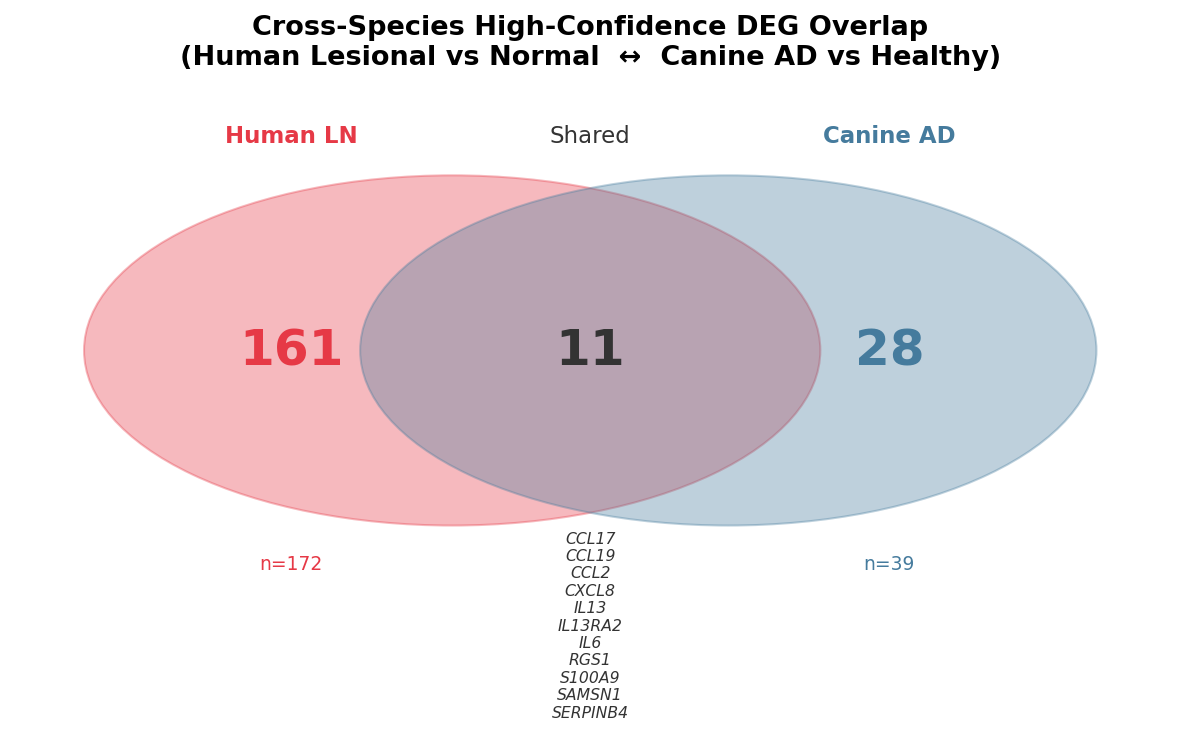

  Figure saved → figures/Fig14a_CrossSpecies_Venn.pdf
  Figure saved → figures/Fig14b_CrossSpecies_FC_correlation.png


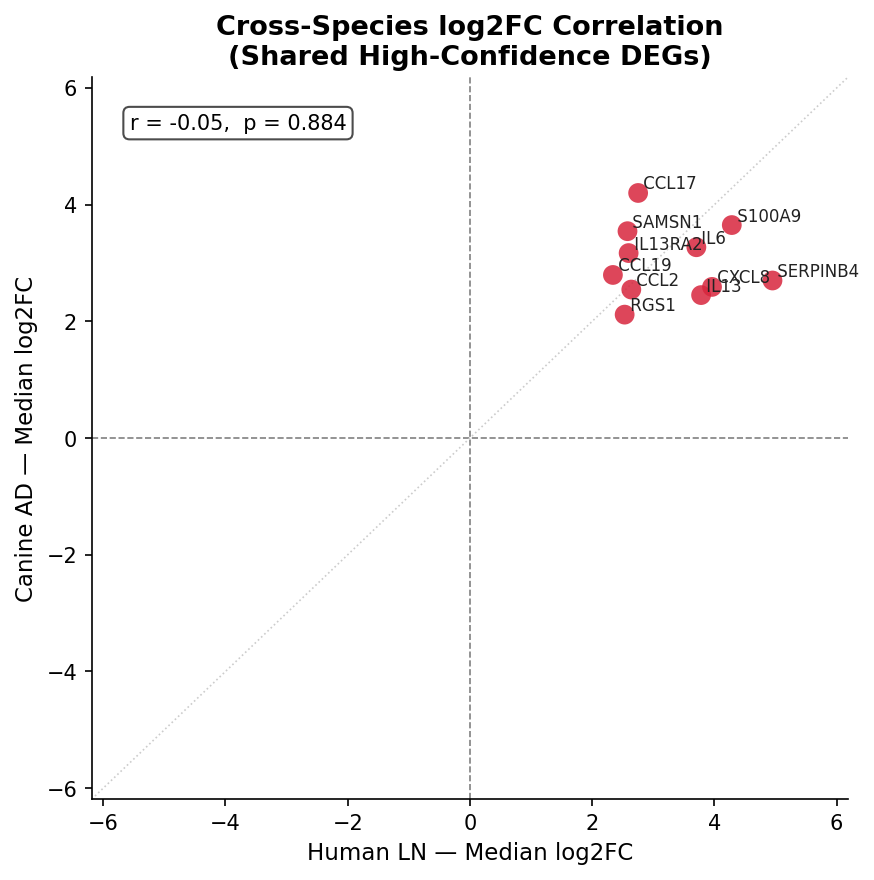

  Figure saved → figures/Fig14b_CrossSpecies_FC_correlation.pdf


In [51]:
h_comp = 'Human_Lesional_vs_Normal'
c_comp = 'Canine_AD_vs_Healthy'

if h_comp in meta_results and c_comp in meta_results:
    h_df = meta_results[h_comp]
    c_df = meta_results[c_comp]

    h_hc = set(h_df[(h_df['DEG_confidence']=='High-confidence') &
                     ~h_df['exclude_viz']]['Gene_Symbol'])
    c_hc = set(c_df[(c_df['DEG_confidence']=='High-confidence') &
                     ~c_df['exclude_viz']]['Gene_Symbol'])

    shared      = h_hc & c_hc
    human_only  = h_hc - c_hc
    canine_only = c_hc - h_hc

    print(f'Cross-species high-confidence DEG overlap:')
    print(f'  Human LN only  : {len(human_only)}')
    print(f'  Canine AD only : {len(canine_only)}')
    print(f'  Shared         : {len(shared)}')
    if shared:
        print(f'  Shared genes   : {", ".join(sorted(shared))}')

    # ── Venn diagram ─────────────────────────────────────────
    from matplotlib.patches import Circle
    fig, ax = plt.subplots(figsize=(8, 5))
    c1 = Circle((0.38,0.5), 0.32, color='#E63946', alpha=0.35)
    c2 = Circle((0.62,0.5), 0.32, color='#457B9D', alpha=0.35)
    ax.add_patch(c1); ax.add_patch(c2)
    ax.text(0.24, 0.5,  str(len(human_only)),  ha='center', va='center',
            fontsize=24, fontweight='bold', color='#E63946')
    ax.text(0.5,  0.5,  str(len(shared)),       ha='center', va='center',
            fontsize=24, fontweight='bold', color='#333333')
    ax.text(0.76, 0.5,  str(len(canine_only)),  ha='center', va='center',
            fontsize=24, fontweight='bold', color='#457B9D')
    ax.text(0.24, 0.88, 'Human LN',  ha='center', fontsize=11,
            color='#E63946', fontweight='bold')
    ax.text(0.5,  0.88, 'Shared',    ha='center', fontsize=11, color='#333333')
    ax.text(0.76, 0.88, 'Canine AD', ha='center', fontsize=11,
            color='#457B9D', fontweight='bold')
    ax.text(0.24, 0.1, f'n={len(h_hc)}', ha='center', fontsize=9,
            color='#E63946')
    ax.text(0.76, 0.1, f'n={len(c_hc)}', ha='center', fontsize=9,
            color='#457B9D')
    if shared and len(shared) <= 20:
        ax.text(0.5, 0.17, '\n'.join(sorted(shared)),
                ha='center', fontsize=7.5, color='#333',
                style='italic', va='top')
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    ax.set_title(
        'Cross-Species High-Confidence DEG Overlap\n'
        '(Human Lesional vs Normal  ↔  Canine AD vs Healthy)',
        fontweight='bold')
    fig.tight_layout()
    save_fig(fig, 'Fig14a_CrossSpecies_Venn.png')

    # Save as PDF
    pdf_filename_venn = 'Fig14a_CrossSpecies_Venn.pdf'
    pdf_path_venn = os.path.join(DIR_FIG, pdf_filename_venn)
    fig.savefig(pdf_path_venn, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'  Figure saved → figures/{pdf_filename_venn}')
    plt.close(fig) # Close the figure to free up memory

    # ── log2FC correlation scatter ────────────────────────────
    h_sum = meta_results[h_comp].set_index('Gene_Symbol')
    c_sum = meta_results[c_comp].set_index('Gene_Symbol')
    shared_viz = sorted(
        g for g in shared
        if not h_sum.loc[g,'exclude_viz'] and not c_sum.loc[g,'exclude_viz'])

    if len(shared_viz) >= 2:
        xv   = [h_sum.loc[g,'median_log2FC'] for g in shared_viz]
        yv   = [c_sum.loc[g,'median_log2FC'] for g in shared_viz]
        cols = ['#D7263D' if x>0 and y>0 else
                '#1A85FF' if x<0 and y<0 else '#888888'
                for x,y in zip(xv,yv)]

        fig2, ax2 = plt.subplots(figsize=(6,6))
        ax2.scatter(xv, yv, c=cols, s=90, alpha=0.85, linewidths=0, zorder=3)
        for g, x, y in zip(shared_viz, xv, yv):
            ax2.text(x, y, f' {g}', fontsize=8, va='bottom', color='#222')
        lim = max(abs(min(xv+yv)), abs(max(xv+yv))) * 1.25
        ax2.axhline(0, color='grey', lw=0.8, ls='--')
        ax2.axvline(0, color='grey', lw=0.8, ls='--')
        ax2.plot([-lim,lim],[-lim,lim], color='#ccc', lw=0.8, ls=':',
                 label='y = x')
        ax2.set_xlim(-lim,lim); ax2.set_ylim(-lim,lim)
        ax2.set_xlabel('Human LN — Median log2FC', fontsize=11)
        ax2.set_ylabel('Canine AD — Median log2FC', fontsize=11)
        ax2.set_title(
            'Cross-Species log2FC Correlation\n(Shared High-Confidence DEGs)',
            fontweight='bold')
        if len(xv) >= 3:
            from scipy.stats import pearsonr
            r, p_val = pearsonr(xv, yv)
            ax2.text(0.05, 0.95, f'r = {r:.2f},  p = {p_val:.3f}',
                     transform=ax2.transAxes, fontsize=10, va='top',
                     bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
        fig2.tight_layout()
        save_fig(fig2, 'Fig14b_CrossSpecies_FC_correlation.png')

        # Save as PDF
        pdf_filename_corr = 'Fig14b_CrossSpecies_FC_correlation.pdf'
        pdf_path_corr = os.path.join(DIR_FIG, pdf_filename_corr)
        fig2.savefig(pdf_path_corr, dpi=300, bbox_inches='tight', facecolor='white')
        print(f'  Figure saved → figures/{pdf_filename_corr}')
        plt.close(fig2) # Close the figure to free up memory

    else:
        print(f'  Only {len(shared_viz)} shared viz-eligible genes '
              f'— skipping correlation plot (need ≥2)')
else:
    print('Human LN or Canine AD comparison not loaded — skipping cross-species plots.')


## **Step 10b - Heterogeneity Assessment: Cochran's Q and I²**

Fisher and Stouffer assume all datasets measure the same underlying effect.
Cochran's Q tests whether between-study variability exceeds chance.
I² expresses the proportion of total variability due to true heterogeneity.

| I² | Interpretation |
|---|---|
| <25% | Low — pooling appropriate |
| 25–75% | Moderate — interpret with caution |
| >75% | High — pooled estimate may mislead |

**This does NOT change any existing Fisher/Stouffer results, FDR values,
confidence tiers, or gene lists.** It adds interpretive metadata columns.


In [39]:
def compute_heterogeneity(fc_arr, se_arr):
    fc  = np.array(fc_arr, dtype=float)
    se  = np.clip(np.array(se_arr, dtype=float), 1e-10, None)
    k   = len(fc)
    if k < 2:
        return np.nan, np.nan, np.nan, np.nan
    w   = 1.0 / se**2
    mu  = np.sum(w * fc) / np.sum(w)
    Q   = float(np.sum(w * (fc - mu)**2))
    df  = k - 1
    I2  = max(0.0, (Q - df) / Q * 100) if Q > 0 else 0.0
    Qp  = float(stats.chi2.sf(Q, df=df))
    c   = np.sum(w) - np.sum(w**2) / np.sum(w)
    tau2= max(0.0, (Q - df) / c) if c > 0 else 0.0
    return round(Q, 4), round(I2, 1), round(Qp, 6), round(tau2, 6)

def i2_label(i2):
    if np.isnan(i2): return 'N/A'
    if i2 < 25:      return 'Low'
    if i2 <= 75:     return 'Moderate'
    return 'High'

print('Computing heterogeneity for all meta-significant genes...\n')
for comp_name, df in meta_results.items():
    if df.empty:
        continue
    pmat  = matrices[comp_name]['pvalue']
    fcmat = matrices[comp_name]['log2FC']
    Q_l, I2_l, Qp_l, tau2_l = [], [], [], []
    for gene in df['Gene_Symbol']:
        pr  = pmat.loc[gene]  if gene in pmat.index  else pd.Series(dtype=float)
        fcr = fcmat.loc[gene] if gene in fcmat.index else pd.Series(dtype=float)
        mask = pr.notna() & fcr.notna()
        if mask.sum() < 2:
            Q_l.append(np.nan); I2_l.append(np.nan)
            Qp_l.append(np.nan); tau2_l.append(np.nan)
            continue
        pv = pr[mask].astype(float).values
        fc = fcr[mask].astype(float).values
        se = np.array([_approx_se(p, f) for p, f in zip(pv, fc)])
        Q, I2, Qp, tau2 = compute_heterogeneity(fc, se)
        Q_l.append(Q); I2_l.append(I2); Qp_l.append(Qp); tau2_l.append(tau2)
    meta_results[comp_name]['Q_stat']   = Q_l
    meta_results[comp_name]['I2']       = I2_l
    meta_results[comp_name]['Q_pvalue'] = Qp_l
    meta_results[comp_name]['tau2']     = tau2_l
    meta_results[comp_name]['I2_label'] = [i2_label(v) for v in I2_l]

    sig_viz = meta_results[comp_name][
        (meta_results[comp_name]['meta_significant']==True) &
        (~meta_results[comp_name]['exclude_viz'])].copy()
    if len(sig_viz) == 0:
        continue
    low = (sig_viz['I2'] < 25).sum()
    mod = ((sig_viz['I2'] >= 25) & (sig_viz['I2'] <= 75)).sum()
    hig = (sig_viz['I2'] > 75).sum()
    print(f'{comp_name}')
    print(f'  Meta-sig genes: {len(sig_viz)} | Median I²: {sig_viz["I2"].median():.1f}%')
    print(f'  Low (<25%): {low}  Moderate (25-75%): {mod}  High (>75%): {hig}')
    print(f'  Top high-confidence genes:')
    hc_top = sig_viz[sig_viz['DEG_confidence']=='High-confidence'].head(8)
    for _, row in hc_top.iterrows():
        print(f'    {row["Gene_Symbol"]:<14} n={int(row["n_datasets_detected"])}  '
              f'I2={row["I2"]:.1f}%  tau2={row["tau2"]:.4f}  ({row["I2_label"]})')
    print()
print('Columns added: Q_stat, I2, Q_pvalue, tau2, I2_label')


Computing heterogeneity for all meta-significant genes...

Human_Lesional_vs_Normal
  Meta-sig genes: 173 | Median I²: 76.0%
  Low (<25%): 62  Moderate (25-75%): 22  High (>75%): 89
  Top high-confidence genes:
    ISG15          n=2  I2=90.1%  tau2=0.0000  (High)
    SERPINB4       n=7  I2=100.0%  tau2=8.7037  (High)
    IL26           n=2  I2=0.0%  tau2=0.0000  (Low)
    LCE3A          n=3  I2=100.0%  tau2=5.3620  (High)
    IL20           n=2  I2=100.0%  tau2=1.2884  (High)
    SPRR2B         n=4  I2=100.0%  tau2=2.8800  (High)
    APOBEC3A       n=2  I2=100.0%  tau2=0.6630  (High)
    SLC5A5         n=2  I2=96.0%  tau2=0.0000  (High)

Human_Lesional_vs_Nonlesional
  Meta-sig genes: 17 | Median I²: 0.0%
  Low (<25%): 17  Moderate (25-75%): 0  High (>75%): 0
  Top high-confidence genes:
    SERPINB4       n=6  I2=0.0%  tau2=0.0000  (Low)
    S100A9         n=5  I2=0.0%  tau2=0.0000  (Low)
    SERPINB3       n=4  I2=0.0%  tau2=0.0000  (Low)
    S100A7A        n=2  I2=0.0%  tau2=0.0000

## **Step 10c - DerSimonian–Laird Random-Effects Pooled Effect Size**

Fisher/Stouffer combine p-values but give no pooled effect size with CI.
DL computes an inverse-variance weighted mean log₂FC that accounts for
between-study variance (τ²). Adds: pooled_log2FC, pooled_SE, CI_lower_95,
CI_upper_95. Significance calls and gene lists are **unchanged**.


In [40]:
def dersimonians_laird(fc_arr, se_arr):
    fc   = np.array(fc_arr, dtype=float)
    se   = np.clip(np.array(se_arr, dtype=float), 1e-10, None)
    k    = len(fc)
    if k < 2:
        return np.nan, np.nan, np.nan, np.nan, np.nan
    # Fixed-effects
    w_fe  = 1.0 / se**2
    mu_fe = np.sum(w_fe * fc) / np.sum(w_fe)
    Q     = np.sum(w_fe * (fc - mu_fe)**2)
    df    = k - 1
    c     = np.sum(w_fe) - np.sum(w_fe**2) / np.sum(w_fe)
    tau2  = max(0.0, (Q - df) / c) if c > 0 else 0.0
    # Random-effects
    w_re  = 1.0 / (se**2 + tau2)
    mu_re = float(np.sum(w_re * fc) / np.sum(w_re))
    se_re = float(np.sqrt(1.0 / np.sum(w_re)))
    return (round(mu_re,4), round(se_re,4), round(tau2,6),
            round(mu_re - 1.96*se_re, 4), round(mu_re + 1.96*se_re, 4))

print('Computing DerSimonian-Laird pooled effect sizes...\n')
for comp_name, df in meta_results.items():
    if df.empty:
        continue
    pmat  = matrices[comp_name]['pvalue']
    fcmat = matrices[comp_name]['log2FC']
    pfc_l, pse_l, clo_l, chi_l = [], [], [], []
    for gene in df['Gene_Symbol']:
        pr  = pmat.loc[gene]  if gene in pmat.index  else pd.Series(dtype=float)
        fcr = fcmat.loc[gene] if gene in fcmat.index else pd.Series(dtype=float)
        mask = pr.notna() & fcr.notna()
        if mask.sum() < 2:
            pfc_l.append(np.nan); pse_l.append(np.nan)
            clo_l.append(np.nan); chi_l.append(np.nan)
            continue
        pv = pr[mask].astype(float).values
        fc = fcr[mask].astype(float).values
        se = np.array([_approx_se(p, f) for p, f in zip(pv, fc)])
        mu_re, se_re, tau2, clo, chi = dersimonians_laird(fc, se)
        pfc_l.append(mu_re); pse_l.append(se_re)
        clo_l.append(clo); chi_l.append(chi)
    meta_results[comp_name]['pooled_log2FC'] = pfc_l
    meta_results[comp_name]['pooled_SE']     = pse_l
    meta_results[comp_name]['CI_lower_95']   = clo_l
    meta_results[comp_name]['CI_upper_95']   = chi_l

    sig_viz = meta_results[comp_name][
        (meta_results[comp_name]['meta_significant']==True) &
        (~meta_results[comp_name]['exclude_viz'])].copy()
    print(f'{comp_name} — median vs pooled FC for top HC genes:')
    print(f'  {"Gene":<14} {"n":>3}  {"Median FC":>10}  {"Pooled FC":>10}  {"95% CI":>22}')
    print(f'  {"-"*65}')
    for _, row in sig_viz[sig_viz['DEG_confidence']=='High-confidence'].head(8).iterrows():
        ci = f'[{row["CI_lower_95"]:.2f}, {row["CI_upper_95"]:.2f}]'
        print(f'  {row["Gene_Symbol"]:<14} {int(row["n_datasets_detected"]):>3}  '
              f'{row["median_log2FC"]:>10.3f}  {row["pooled_log2FC"]:>10.3f}  {ci:>22}')
    print()
print('Columns added: pooled_log2FC, pooled_SE, CI_lower_95, CI_upper_95')


Computing DerSimonian-Laird pooled effect sizes...

Human_Lesional_vs_Normal — median vs pooled FC for top HC genes:
  Gene             n   Median FC   Pooled FC                  95% CI
  -----------------------------------------------------------------
  ISG15            2       5.451       2.109            [2.11, 2.11]
  SERPINB4         7       4.950       5.193            [2.78, 7.61]
  IL26             2       4.612       4.532            [4.53, 4.53]
  LCE3A            3       4.530       5.464            [2.76, 8.17]
  IL20             2       4.507       4.507            [2.93, 6.08]
  SPRR2B           4       4.435       4.275            [2.46, 6.09]
  APOBEC3A         2       4.388       4.388            [3.26, 5.52]
  SLC5A5           2       4.382       6.563            [6.56, 6.56]

Human_Lesional_vs_Nonlesional — median vs pooled FC for top HC genes:
  Gene             n   Median FC   Pooled FC                  95% CI
  ----------------------------------------------------

### **Figure 13 - Forest Plots with DerSimonian–Laird 95% CI**


Generating revised forest plots with DL random-effects CI...

  Figure saved → figures/Fig13_forest_DL_Human_Lesional_vs_Normal.png


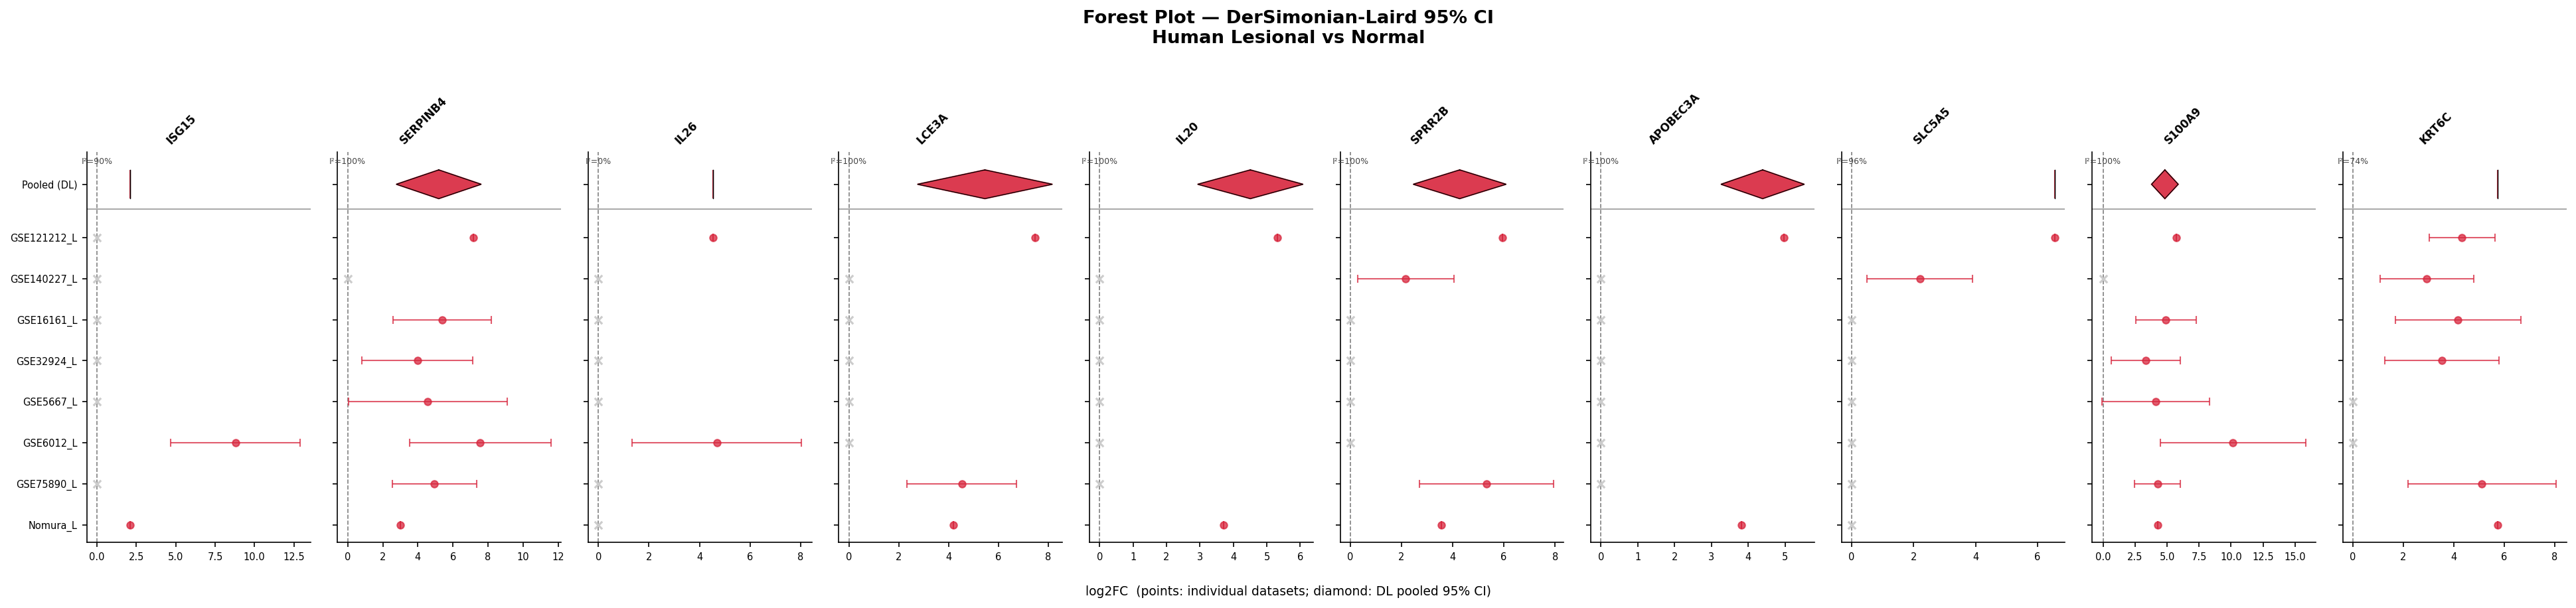

  Figure saved → figures/Fig13_forest_DL_Human_Lesional_vs_Nonlesional.png


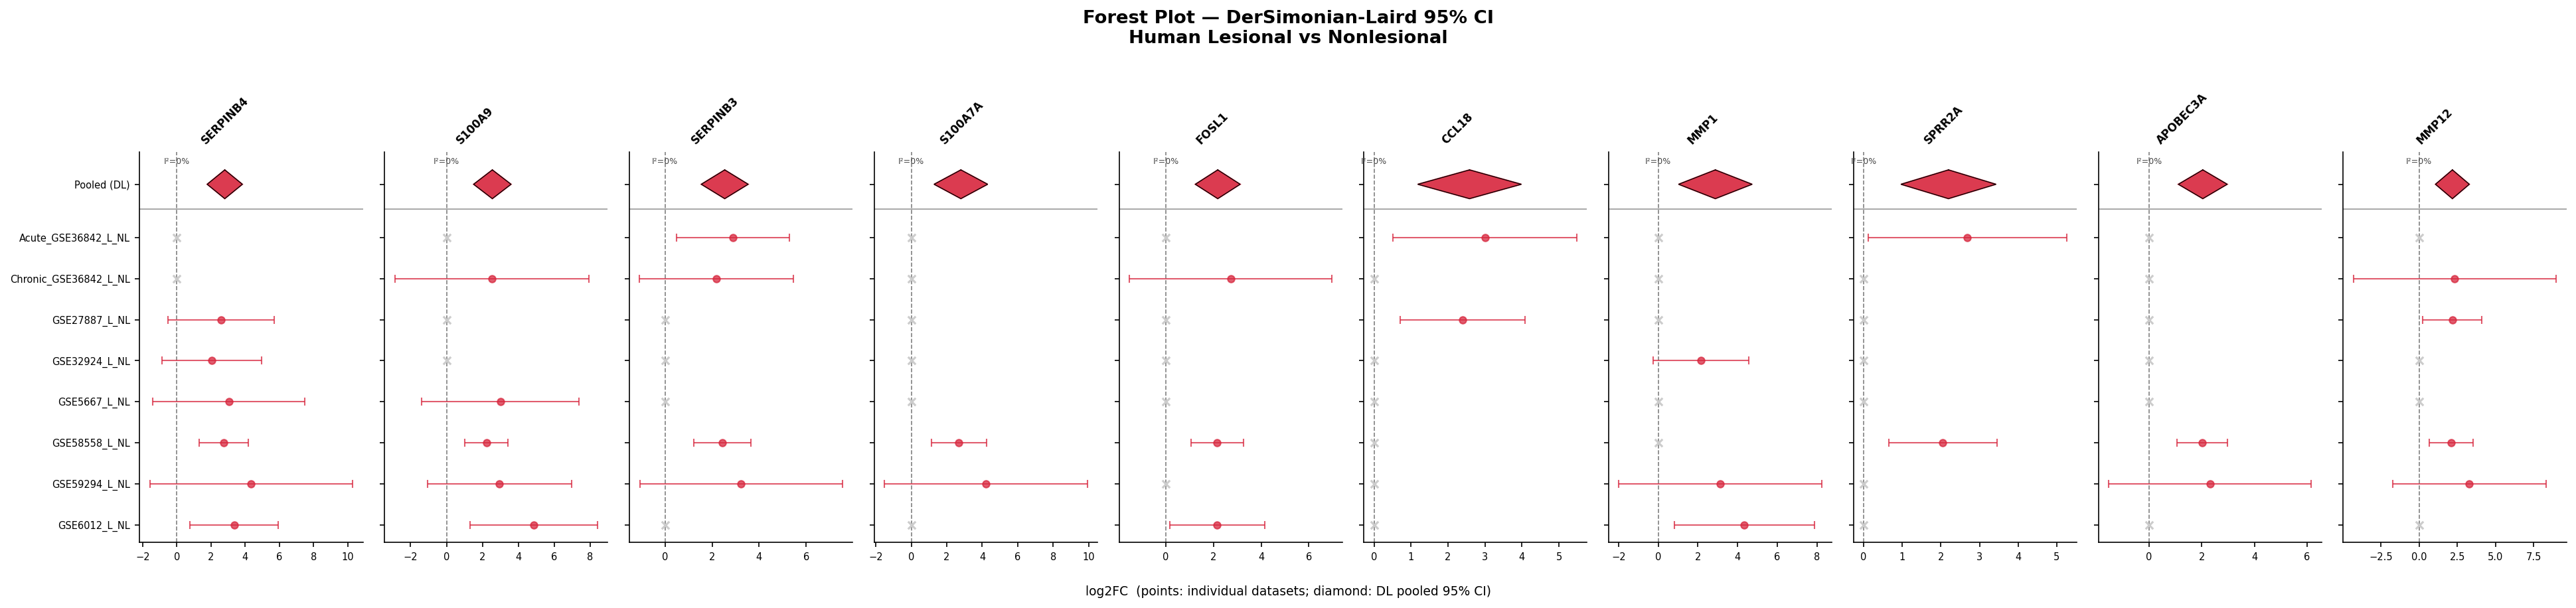

  Figure saved → figures/Fig13_forest_DL_Canine_AD_vs_Healthy.png


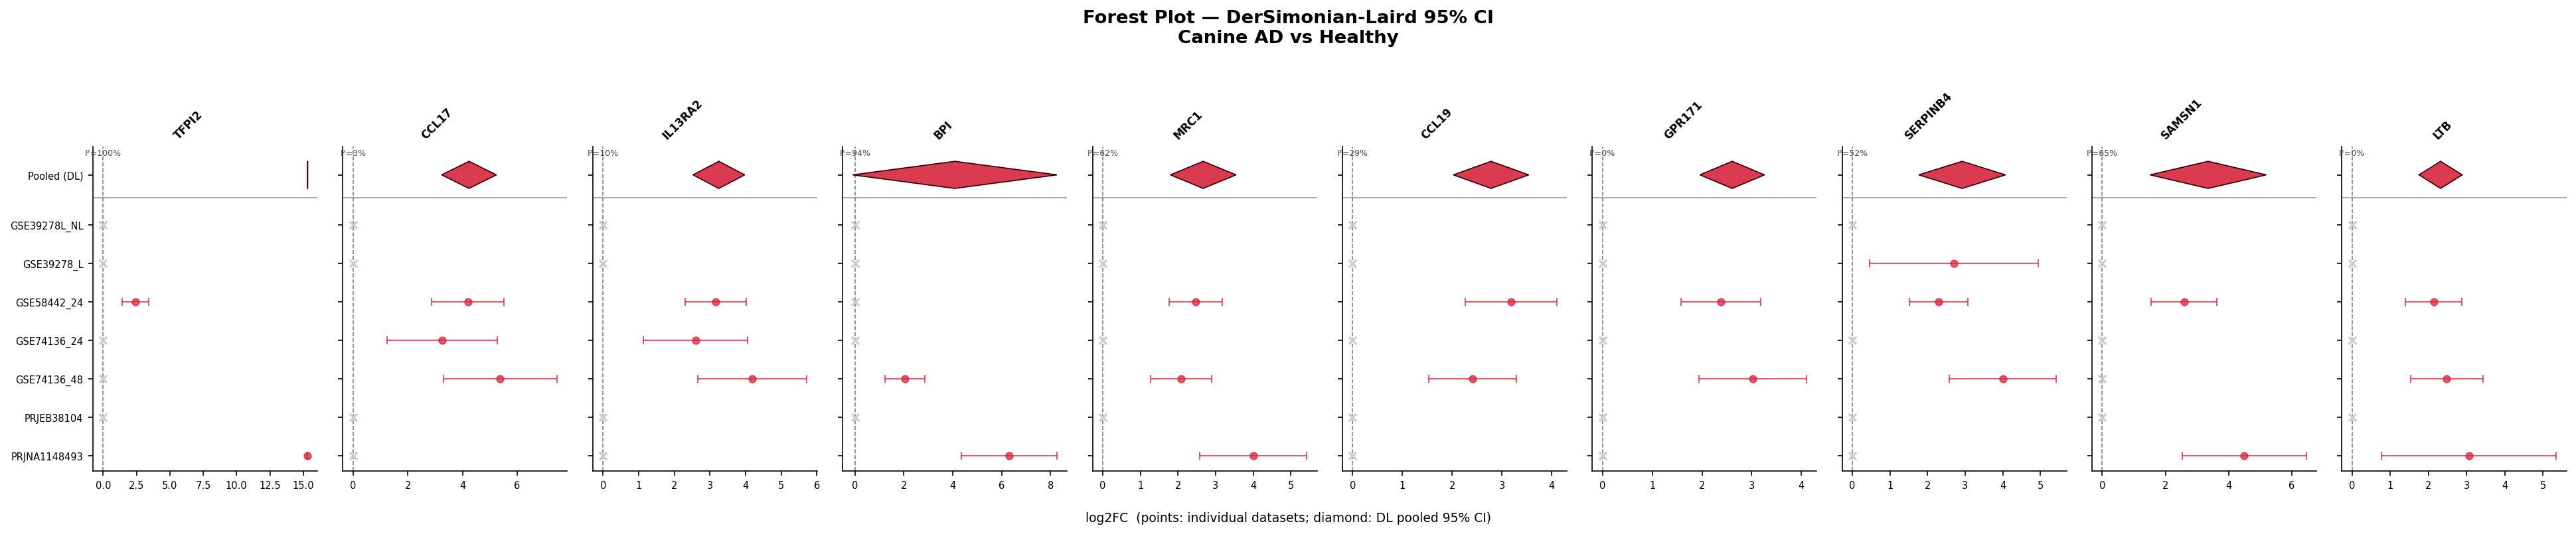

In [41]:
print('Generating revised forest plots with DL random-effects CI...\n')
for comp_name, df in meta_results.items():
    if df.empty:
        continue
    hc = df[(df['DEG_confidence']=='High-confidence') & ~df['exclude_viz']]
    if len(hc) == 0:
        continue
    top_genes = hc.head(10)['Gene_Symbol'].tolist()
    cdf       = all_cleaned[comp_name]
    datasets  = sorted(cdf['dataset'].unique())
    n_ds      = len(datasets)
    ds_rev    = list(reversed(datasets))

    fig, axes = plt.subplots(1, len(top_genes),
                              figsize=(len(top_genes)*2.6, max(4, n_ds*0.7)),
                              sharey=True)
    if len(top_genes) == 1:
        axes = [axes]

    for ax, gene in zip(axes, top_genes):
        for yi, ds in enumerate(ds_rev):
            gdf = cdf[(cdf['Gene_Symbol']==gene) & (cdf['dataset']==ds)]
            if len(gdf) > 0:
                fc  = float(gdf.iloc[0]['log2FC'])
                pv  = float(gdf.iloc[0]['p_value'])
                se  = _approx_se(pv, fc)
                col = PALETTE['Upregulated'] if fc>0 else PALETTE['Downregulated']
                ax.errorbar(fc, yi, xerr=se*1.96, fmt='o', color=col,
                            markersize=5, capsize=3, linewidth=1.2,
                            elinewidth=1, zorder=3, alpha=0.75)
            else:
                ax.scatter(0, yi, marker='x', color='#cccccc', s=30, zorder=2)

        # DL pooled diamond
        grow = df[df['Gene_Symbol']==gene]
        if len(grow) > 0:
            pfc  = float(grow.iloc[0]['pooled_log2FC']) if 'pooled_log2FC' in grow.columns else np.nan
            clo  = float(grow.iloc[0]['CI_lower_95'])   if 'CI_lower_95' in grow.columns else np.nan
            chi  = float(grow.iloc[0]['CI_upper_95'])   if 'CI_upper_95' in grow.columns else np.nan
            i2   = float(grow.iloc[0]['I2'])             if 'I2' in grow.columns else np.nan
            if not np.isnan(pfc):
                yd = n_ds + 0.3
                dh = 0.35
                dx = [pfc, chi, pfc, clo, pfc]
                dy = [yd+dh, yd, yd-dh, yd, yd+dh]
                col_d = PALETTE['Upregulated'] if pfc>0 else PALETTE['Downregulated']
                ax.fill(dx, dy, color=col_d, alpha=0.9, zorder=4)
                ax.plot(dx, dy, color='black', lw=0.6, zorder=5)
                if not np.isnan(i2):
                    ax.text(0, yd+dh+0.1, f'I²={i2:.0f}%',
                            ha='center', fontsize=6, color='#444', va='bottom')

        ax.axvline(0, color='grey', lw=0.8, ls='--', zorder=1)
        ax.axhline(n_ds-0.3, color='black', lw=0.8, ls='-', alpha=0.4)
        ax.set_title(gene, fontsize=8, fontweight='bold', rotation=45, ha='right')
        ax.set_yticks(list(range(n_ds)) + [n_ds+0.3])
        ax.set_yticklabels(ds_rev + ['Pooled (DL)'], fontsize=7)
        ax.tick_params(axis='x', labelsize=7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'Forest Plot — DerSimonian-Laird 95% CI\n{comp_name.replace("_"," ")}',
        fontweight='bold', y=1.02)
    fig.text(0.5, -0.03,
             'log2FC  (points: individual datasets; diamond: DL pooled 95% CI)',
             ha='center', fontsize=9)
    fig.tight_layout()
    save_fig(fig, f'Fig13_forest_DL_{comp_name}.png')


## **Step 10d - Cross-Species Analysis with Ensembl Compara Ortholog Mapping**

Direct symbol matching (current approach) misses genes whose human and dog
symbols differ slightly. Ensembl Compara one-to-one orthologs are used to
find additional conserved genes. The 11 genes already found are retained;
additional genes may be added.


In [42]:
import requests, time, io

def fetch_dog_human_orthologs(cache_path=None):
    if cache_path and os.path.exists(cache_path):
        print(f'  Loading cached ortholog table: {cache_path}')
        return pd.read_csv(cache_path)
    print('  Querying Ensembl BioMart for dog-human one-to-one orthologs...')
    print('  (This takes ~30-60 s)')
    # BioMart XML query — built as a plain string (no nested quotes)
    xml = (
        '<?xml version="1.0" encoding="UTF-8"?>'
        '<!DOCTYPE Query>'
        '<Query virtualSchemaName="default" formatter="TSV" header="1" '
        'uniqueRows="1" count="" datasetConfigVersion="0.6">'
        '<Dataset name="clfamiliaris_gene_ensembl" interface="default">'
        '<Attribute name="external_gene_name"/>'
        '<Attribute name="hsapiens_homolog_associated_gene_name"/>'
        '<Attribute name="hsapiens_homolog_orthology_type"/>'
        '<Attribute name="hsapiens_homolog_perc_id"/>'
        '<Attribute name="hsapiens_homolog_perc_id_r1"/>'
        '</Dataset>'
        '</Query>'
    )
    url = 'https://www.ensembl.org/biomart/martservice'
    try:
        r = requests.get(url, params={'query': xml}, timeout=180)
        if r.status_code != 200:
            print(f'  BioMart status {r.status_code} — skipping')
            return pd.DataFrame()
        ortho = pd.read_csv(io.StringIO(r.text), sep='\t')
        ortho.columns = ['dog_symbol','human_symbol',
                         'orthology_type','pct_id_dog','pct_id_human']
        ortho = ortho.dropna(subset=['dog_symbol','human_symbol'])
        ortho = ortho[(ortho['dog_symbol'].str.strip() != '') &
                      (ortho['human_symbol'].str.strip() != '')]
        ortho['dog_symbol']   = ortho['dog_symbol'].str.upper().str.strip()
        ortho['human_symbol'] = ortho['human_symbol'].str.upper().str.strip()
        if cache_path:
            ortho.to_csv(cache_path, index=False)
            print(f'  Cached to {cache_path}')
        one2one = ortho[ortho['orthology_type']=='ortholog_one2one']
        print(f'  Total pairs: {len(ortho):,}  |  One-to-one: {len(one2one):,}')
        return ortho
    except Exception as e:
        print(f'  BioMart failed: {e}')
        return pd.DataFrame()

cache = os.path.join(DIR_COMBINED, 'dog_human_orthologs_ensembl.csv')
ortho_df = fetch_dog_human_orthologs(cache_path=cache)

dog2human, human2dog = {}, {}
if not ortho_df.empty:
    one2one   = ortho_df[ortho_df['orthology_type']=='ortholog_one2one']
    dog2human = dict(zip(one2one['dog_symbol'], one2one['human_symbol']))
    human2dog = dict(zip(one2one['human_symbol'], one2one['dog_symbol']))
    print(f'Lookup built: {len(dog2human):,} dog->human  |  {len(human2dog):,} human->dog')
else:
    print('No ortholog table — will use direct symbol matching only.')


  Loading cached ortholog table: /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB01/Tables/dog_human_orthologs_ensembl.csv
Lookup built: 15,318 dog->human  |  15,821 human->dog


ORTHOLOG-AWARE CROSS-SPECIES INTERSECTION
Human LN HC genes : 172
Canine AD HC genes: 39

Method 1 - Direct symbol match  : 11 shared genes
Method 2 - Ortholog-aware match  : 11 shared pairs
  Direct symbol matches          : 11
  Added via ortholog mapping     : 0
Human-specific: 161 | Canine-specific: 28

Saved: cross_species_ortholog_shared.csv
Concordant: 11/11  |  Discordant: 0/11
  Figure saved → figures/Fig14a_CrossSpecies_Venn_ortholog.png


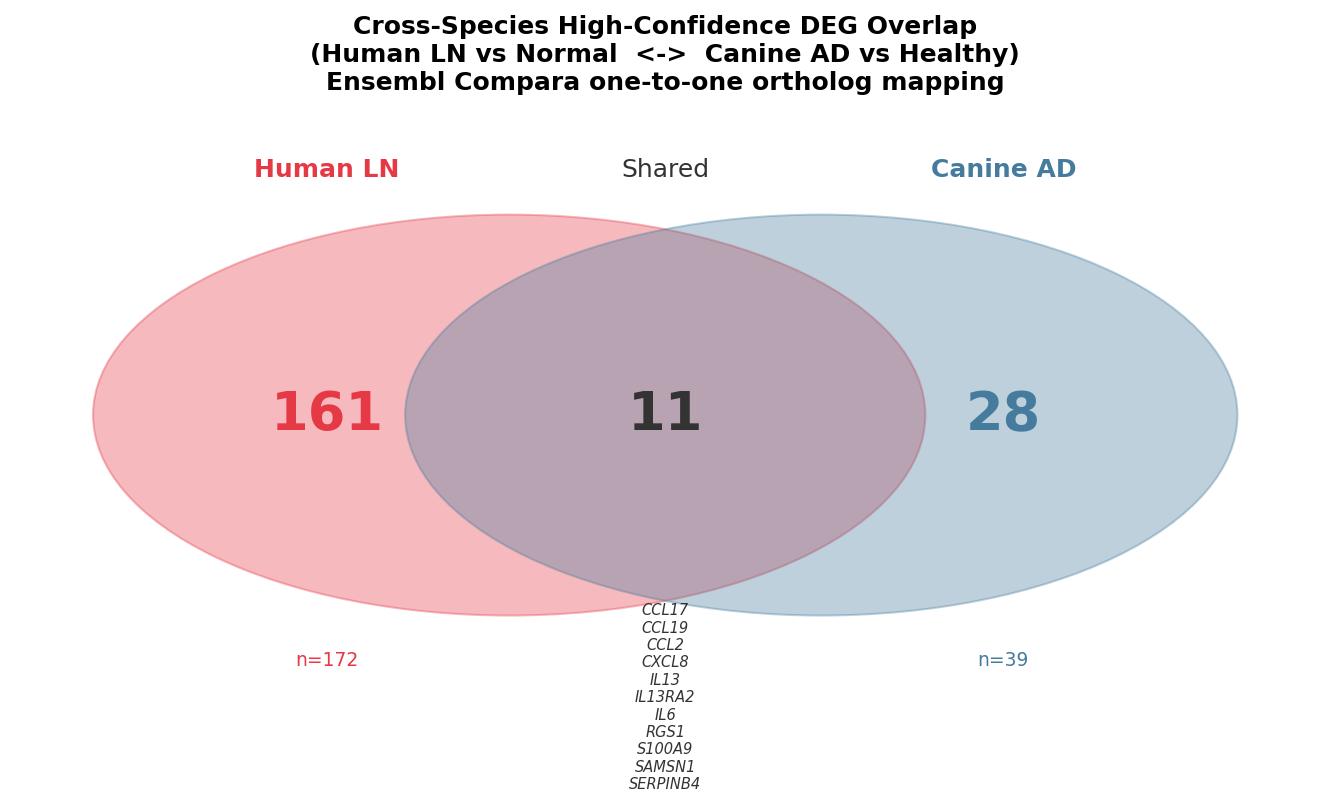

  Figure saved → figures/Fig14b_CrossSpecies_FC_ortholog.png


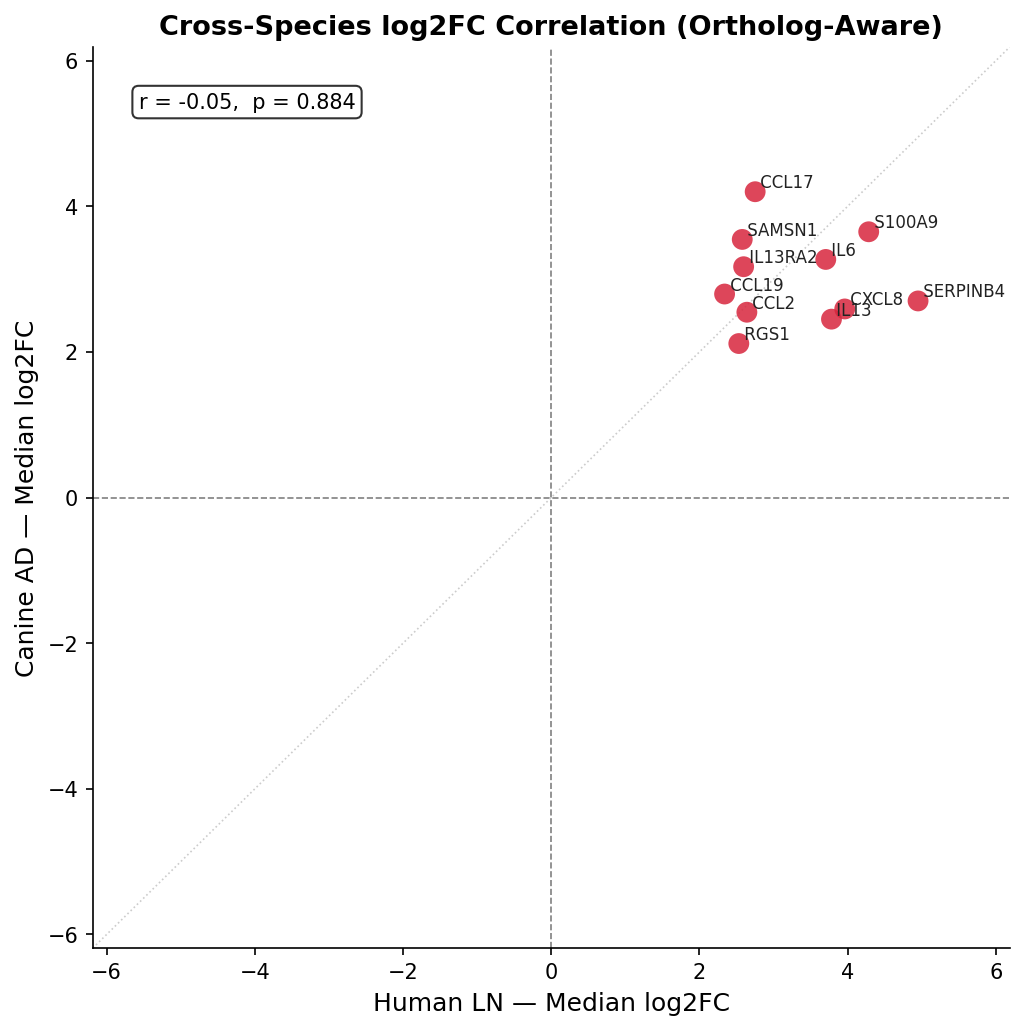

In [43]:
h_comp = 'Human_Lesional_vs_Normal'
c_comp = 'Canine_AD_vs_Healthy'

if h_comp not in meta_results or c_comp not in meta_results:
    print('Comparison not available — skipping cross-species analysis.')
else:
    h_df = meta_results[h_comp]
    c_df = meta_results[c_comp]
    h_hc = set(h_df[(h_df['DEG_confidence']=='High-confidence') &
                     ~h_df['exclude_viz']]['Gene_Symbol'])
    c_hc = set(c_df[(c_df['DEG_confidence']=='High-confidence') &
                     ~c_df['exclude_viz']]['Gene_Symbol'])

    print('='*60)
    print('ORTHOLOG-AWARE CROSS-SPECIES INTERSECTION')
    print('='*60)
    print(f'Human LN HC genes : {len(h_hc)}')
    print(f'Canine AD HC genes: {len(c_hc)}')

    # Direct match
    direct_shared = h_hc & c_hc
    print(f'\nMethod 1 - Direct symbol match  : {len(direct_shared)} shared genes')

    # Ortholog-aware match
    shared_pairs = {}  # canine_gene -> human_gene
    for cg in c_hc:
        if cg in h_hc:
            shared_pairs[cg] = cg                          # direct
        elif cg in dog2human and dog2human[cg] in h_hc:
            shared_pairs[cg] = dog2human[cg]               # via ortholog
    for hg in h_hc:
        if hg in human2dog:
            cg_orth = human2dog[hg]
            if cg_orth in c_hc and cg_orth not in shared_pairs:
                shared_pairs[cg_orth] = hg

    via_orth  = [(c,h) for c,h in shared_pairs.items() if c != h]
    h_only    = h_hc - set(shared_pairs.values())
    c_only    = c_hc - set(shared_pairs.keys())

    print(f'Method 2 - Ortholog-aware match  : {len(shared_pairs)} shared pairs')
    print(f'  Direct symbol matches          : {len(shared_pairs)-len(via_orth)}')
    print(f'  Added via ortholog mapping     : {len(via_orth)}')
    if via_orth:
        print(f'  New pairs:')
        for cg, hg in sorted(via_orth):
            c_row = c_df[c_df['Gene_Symbol']==cg]
            h_row = h_df[h_df['Gene_Symbol']==hg]
            cdir = c_row.iloc[0]['consensus_direction'] if len(c_row) else '?'
            hdir = h_row.iloc[0]['consensus_direction'] if len(h_row) else '?'
            cfc  = c_row.iloc[0]['median_log2FC']       if len(c_row) else np.nan
            hfc  = h_row.iloc[0]['median_log2FC']       if len(h_row) else np.nan
            conc = 'CONCORDANT' if cdir==hdir else 'DISCORDANT'
            print(f'    Dog:{cg} <-> Human:{hg}  '
                  f'Dog({cdir},FC={cfc:.2f}) Human({hdir},FC={hfc:.2f}) {conc}')
    print(f'Human-specific: {len(h_only)} | Canine-specific: {len(c_only)}')

    # Build shared table
    shared_rows = []
    for cg, hg in sorted(shared_pairs.items()):
        c_row = c_df[c_df['Gene_Symbol']==cg]
        h_row = h_df[h_df['Gene_Symbol']==hg]
        if not len(c_row) or not len(h_row): continue
        cdir = c_row.iloc[0]['consensus_direction']
        hdir = h_row.iloc[0]['consensus_direction']
        cfc  = c_row.iloc[0]['median_log2FC']
        hfc  = h_row.iloc[0]['median_log2FC']
        shared_rows.append({
            'Canine_Gene'      : cg,
            'Human_Gene'       : hg,
            'Match_type'       : 'Direct' if cg==hg else 'Ortholog',
            'Canine_direction' : cdir,
            'Human_direction'  : hdir,
            'Canine_log2FC'    : cfc,
            'Human_log2FC'     : hfc,
            'Concordance'      : 'Concordant' if cdir==hdir else 'Discordant',
        })
    shared_df_out = pd.DataFrame(shared_rows)
    spath = os.path.join(DIR_META, 'cross_species_ortholog_shared.csv')
    shared_df_out.to_csv(spath, index=False)
    print(f'\nSaved: cross_species_ortholog_shared.csv')
    concordant = (shared_df_out['Concordance']=='Concordant').sum()
    print(f'Concordant: {concordant}/{len(shared_df_out)}  |  '
          f'Discordant: {len(shared_df_out)-concordant}/{len(shared_df_out)}')

    # Revised Venn
    from matplotlib.patches import Circle
    fig, ax = plt.subplots(figsize=(9, 5.5))
    c1 = Circle((0.38,0.5),0.32,color='#E63946',alpha=0.35)
    c2 = Circle((0.62,0.5),0.32,color='#457B9D',alpha=0.35)
    ax.add_patch(c1); ax.add_patch(c2)
    ax.text(0.24,0.5,str(len(h_only)),ha='center',va='center',
            fontsize=26,fontweight='bold',color='#E63946')
    ax.text(0.5, 0.5,str(len(shared_pairs)),ha='center',va='center',
            fontsize=26,fontweight='bold',color='#333')
    ax.text(0.76,0.5,str(len(c_only)),ha='center',va='center',
            fontsize=26,fontweight='bold',color='#457B9D')
    ax.text(0.24,0.88,'Human LN', ha='center',fontsize=12,
            color='#E63946',fontweight='bold')
    ax.text(0.5, 0.88,'Shared',   ha='center',fontsize=12,color='#333')
    ax.text(0.76,0.88,'Canine AD',ha='center',fontsize=12,
            color='#457B9D',fontweight='bold')
    ax.text(0.24,0.10,f'n={len(h_hc)}',ha='center',fontsize=9,color='#E63946')
    ax.text(0.76,0.10,f'n={len(c_hc)}',ha='center',fontsize=9,color='#457B9D')
    if len(shared_pairs) <= 20:
        labs = [cg if cg==hg else f'{cg}/{hg}' for cg,hg in sorted(shared_pairs.items())]
        ax.text(0.5,0.20,'\n'.join(labs),ha='center',fontsize=7,
                color='#333',style='italic',va='top')
    if via_orth:
        ax.text(0.5,0.02,
                f'Includes {len(via_orth)} pair(s) via Ensembl Compara ortholog mapping',
                ha='center',fontsize=7.5,color='#555',style='italic')
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    ax.set_title(
        'Cross-Species High-Confidence DEG Overlap\n'
        '(Human LN vs Normal  <->  Canine AD vs Healthy)\n'
        'Ensembl Compara one-to-one ortholog mapping',
        fontweight='bold',fontsize=12)
    fig.tight_layout()
    save_fig(fig, 'Fig14a_CrossSpecies_Venn_ortholog.png')

    # Correlation scatter
    if len(shared_rows) >= 2:
        sd  = pd.DataFrame(shared_rows)
        xv  = sd['Human_log2FC'].tolist()
        yv  = sd['Canine_log2FC'].tolist()
        cols= ['#D7263D' if x>0 and y>0 else
               '#1A85FF' if x<0 and y<0 else '#888' for x,y in zip(xv,yv)]
        labs= [r['Canine_Gene'] if r['Canine_Gene']==r['Human_Gene']
               else f'{r["Canine_Gene"]}/{r["Human_Gene"]}'
               for _,r in sd.iterrows()]
        fig2, ax2 = plt.subplots(figsize=(7,7))
        ax2.scatter(xv,yv,c=cols,s=100,alpha=0.85,linewidths=0,zorder=3)
        for lb,x,y in zip(labs,xv,yv):
            ax2.text(x,y,f' {lb}',fontsize=8,va='bottom',color='#222')
        lim = max(abs(min(xv+yv)),abs(max(xv+yv)))*1.25
        ax2.axhline(0,color='grey',lw=0.8,ls='--')
        ax2.axvline(0,color='grey',lw=0.8,ls='--')
        ax2.plot([-lim,lim],[-lim,lim],color='#ccc',lw=0.8,ls=':')
        ax2.set_xlim(-lim,lim); ax2.set_ylim(-lim,lim)
        ax2.set_xlabel('Human LN — Median log2FC',fontsize=12)
        ax2.set_ylabel('Canine AD — Median log2FC',fontsize=12)
        ax2.set_title('Cross-Species log2FC Correlation (Ortholog-Aware)',
                      fontweight='bold')
        if len(xv) >= 3:
            from scipy.stats import pearsonr
            r_val, p_val = pearsonr(xv, yv)
            ax2.text(0.05,0.95,f'r = {r_val:.2f},  p = {p_val:.3f}',
                     transform=ax2.transAxes,fontsize=10,va='top',
                     bbox=dict(boxstyle='round,pad=0.3',fc='white',alpha=0.8))
        fig2.tight_layout()
        save_fig(fig2, 'Fig14b_CrossSpecies_FC_ortholog.png')


## **Step 10e - Platform Effect Check: PCA of Dataset-Level log2FC Profiles**

Datasets span Affymetrix microarray and Illumina RNA-seq platforms.
This PCA checks whether datasets cluster by platform in effect-size space.
No platform separation → platform differences are not driving meta-analysis
results (a strength to report). Clear separation → note as a limitation.


  Figure saved → figures/Fig_PCA_platform_check.png


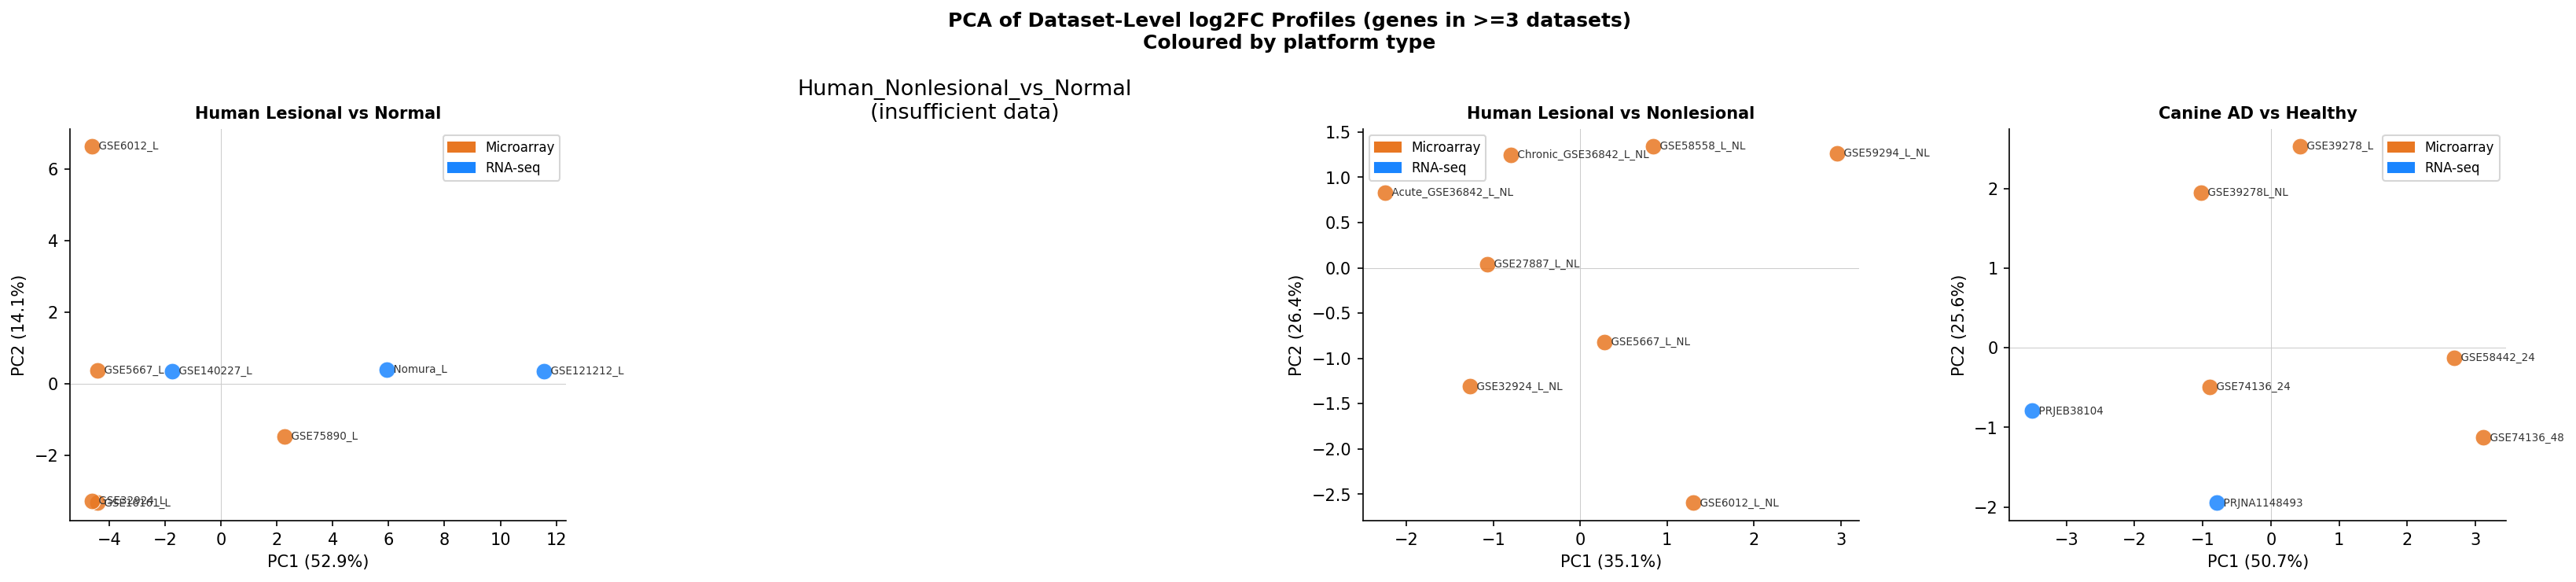

In [44]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

PLATFORM_MAP = {
    'GSE121212_L'       : 'RNA-seq',
    'GSE140227_L'       : 'RNA-seq',
    'GSE16161_L'        : 'Microarray',
    'GSE32924_L'        : 'Microarray',
    'GSE5667_L'         : 'Microarray',
    'GSE6012_L'         : 'Microarray',
    'GSE75890_L'        : 'Microarray',
    'Nomura_L'          : 'RNA-seq',
    'GSE27887_L_NL'     : 'Microarray',
    'GSE32924_L_NL'     : 'Microarray',
    'GSE5667_L_NL'      : 'Microarray',
    'GSE6012_L_NL'      : 'Microarray',
    'GSE58558_L_NL'     : 'Microarray',
    'GSE59294_L_NL'     : 'Microarray',
    'Acute_GSE36842_L_NL'  : 'Microarray',
    'Chronic_GSE36842_L_NL': 'Microarray',
    'GSE6012_NL'        : 'Microarray',
    'GSE39278_L'        : 'Microarray',
    'GSE39278L_NL'      : 'Microarray',
    'GSE58442_24'       : 'Microarray',
    'GSE74136_24'       : 'Microarray',
    'GSE74136_48'       : 'Microarray',
    'PRJNA1148493'      : 'RNA-seq',
    'PRJEB38104'        : 'RNA-seq',
}
PCOL = {'Microarray':'#E87722', 'RNA-seq':'#1A85FF', 'Unknown':'#888'}

comp_list = [c for c in COMPARISONS if c in matrices]
n_comps   = len(comp_list)
fig, axes = plt.subplots(1, n_comps, figsize=(n_comps*5.5, 5))
if n_comps == 1: axes = [axes]

for ax, comp_name in zip(axes, comp_list):
    fcmat = matrices[comp_name]['log2FC']
    min_ds = min(3, fcmat.shape[1])
    gmask  = fcmat.notna().sum(axis=1) >= min_ds
    mat_sub= fcmat.loc[gmask].fillna(0).T   # datasets x genes
    if mat_sub.shape[0] < 2 or mat_sub.shape[1] < 2:
        ax.set_title(f'{comp_name}\n(insufficient data)')
        ax.axis('off')
        continue
    X     = StandardScaler().fit_transform(mat_sub)
    pca   = PCA(n_components=min(2, mat_sub.shape[0]-1))
    sc    = pca.fit_transform(X)
    var   = pca.explained_variance_ratio_ * 100
    for j, ds in enumerate(mat_sub.index):
        plat = PLATFORM_MAP.get(ds, 'Unknown')
        col  = PCOL.get(plat, '#888')
        y_   = sc[j,1] if sc.shape[1] > 1 else 0
        ax.scatter(sc[j,0], y_, c=col, s=100, alpha=0.85,
                   edgecolors='white', linewidth=0.5, zorder=3)
        ax.text(sc[j,0], y_, f'  {ds}', fontsize=6.5,
                va='center', color='#333')
    ax.set_xlabel(f'PC1 ({var[0]:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2 ({var[1]:.1f}%)' if len(var)>1 else 'PC2', fontsize=10)
    ax.set_title(comp_name.replace('_',' '), fontweight='bold', fontsize=10)
    ax.axhline(0, color='#ccc', lw=0.5)
    ax.axvline(0, color='#ccc', lw=0.5)
    patches = [mpatches.Patch(color=v, label=k) for k,v in PCOL.items()
               if k != 'Unknown']
    ax.legend(handles=patches, fontsize=8, framealpha=0.8)

fig.suptitle('PCA of Dataset-Level log2FC Profiles (genes in >=3 datasets)\n'
             'Coloured by platform type', fontweight='bold', fontsize=12)
fig.tight_layout()
save_fig(fig, 'Fig_PCA_platform_check.png')


### **Save Enriched Meta-Analysis Tables**

The enriched tables now include I², Q, tau², pooled_log2FC, 95% CI columns.



In [45]:
# Enriched tables now saved in the final save cell below
print('Enriched meta tables will be saved in the final step.')

Enriched meta tables will be saved in the final step.


---
## Step 12 — Save All Meta-Analysis Results

Saves:
- One meta-analysis CSV per comparison → `Results/meta_summary/`
- Meta-analysis summary CSV
- **Supplementary Table S1 Complete** (5-tab Excel):
  - S1a: Homo sapiens raw DEGs
  - S1b: Canis lupus familiaris raw DEGs
  - S1c: Human meta-analysis results (all 3 human comparisons)
  - S1d: Canine meta-analysis results
  - S1e: High-confidence DEGs only (ready for pathway analysis)


In [46]:
# ── Individual meta-analysis CSVs (intermediate — shared with NB02) ─
print('Saving meta-analysis results...\n')
for comp_name, df in meta_results.items():
    if df.empty:
        continue
    path = os.path.join(DIR_META, f'meta_{comp_name}.csv')
    df.to_csv(path, index=False)
    n_sig = int(df['meta_significant'].sum())
    print(f'  ✓  meta_{comp_name}.csv  ({len(df):,} genes, {n_sig} meta-sig)')

meta_summary_df.to_csv(os.path.join(DIR_META, 'meta_analysis_summary.csv'), index=False)
print('  ✓  meta_analysis_summary.csv\n')

# ── Save enriched meta tables too ────────────────────────────────────
for comp_name, df in meta_results.items():
    if df.empty: continue
    path = os.path.join(DIR_META, f'meta_{comp_name}_enriched.csv')
    df.to_csv(path, index=False)

# ── Supplementary_File_1.xlsx — 5 sheets (Manuscript-ready) ─────────
suppl1_path = os.path.join(NB01_SUP, 'Supplementary_File_1.xlsx')
human_comps  = ['Human_Lesional_vs_Normal','Human_Nonlesional_vs_Normal',
                'Human_Lesional_vs_Nonlesional']
canine_comps = ['Canine_AD_vs_Healthy']

human_meta_df = pd.concat(
    [meta_results[c].assign(comparison=c) for c in human_comps
     if c in meta_results and not meta_results[c].empty], ignore_index=True)
canine_meta_df = pd.concat(
    [meta_results[c].assign(comparison=c) for c in canine_comps
     if c in meta_results and not meta_results[c].empty], ignore_index=True
) if any(c in meta_results and not meta_results[c].empty for c in canine_comps) else pd.DataFrame()

hc_master = pd.concat(
    [meta_results[c].assign(comparison=c)
     [meta_results[c]['DEG_confidence']=='High-confidence']
     for c in meta_results if not meta_results[c].empty], ignore_index=True)

master_df = pd.concat(all_cleaned.values(), ignore_index=True)
human_df  = master_df[master_df['species']=='Homo sapiens'].copy()
canine_df = master_df[master_df['species']=='Canis lupus familiaris'].copy()
drop_cols = ['exclude_viz']

with pd.ExcelWriter(suppl1_path, engine='openpyxl') as writer:
    human_df.drop(columns=drop_cols, errors='ignore').to_excel(
        writer, sheet_name='S1a_Human_Raw_DEGs', index=False)
    canine_df.drop(columns=drop_cols, errors='ignore').to_excel(
        writer, sheet_name='S1b_Canine_Raw_DEGs', index=False)
    if not human_meta_df.empty:
        human_meta_df.drop(columns=drop_cols, errors='ignore').to_excel(
            writer, sheet_name='S1c_Human_Meta_Analysis', index=False)
    if not canine_meta_df.empty:
        canine_meta_df.drop(columns=drop_cols, errors='ignore').to_excel(
            writer, sheet_name='S1d_Canine_Meta_Analysis', index=False)
    if not hc_master.empty:
        hc_master.drop(columns=drop_cols, errors='ignore').to_excel(
            writer, sheet_name='S1e_High_Confidence_DEGs', index=False)

print(f'✓  Supplementary_File_1.xlsx saved → NB01/Supplementary_Files/')
print(f'   S1a Human raw DEGs       : {len(human_df):,} rows')
print(f'   S1b Canine raw DEGs      : {len(canine_df):,} rows')
print(f'   S1c Human meta-analysis  : {len(human_meta_df):,} rows')
print(f'   S1d Canine meta-analysis : {len(canine_meta_df):,} rows')
print(f'   S1e High-confidence DEGs : {len(hc_master):,} rows')

# ── NB01/Tables/ — Consolidated meta summary Excel ──────────────────
meta_excel_path = os.path.join(NB01_TAB, 'Meta_Analysis_Summary.xlsx')
with pd.ExcelWriter(meta_excel_path, engine='openpyxl') as writer:
    meta_summary_df.to_excel(writer, sheet_name='Summary', index=False)
    for comp_name, df in meta_results.items():
        if df.empty: continue
        sheet = comp_name.replace('Human_','H_').replace('Canine_AD_vs_Healthy','Canine')[:31]
        df.drop(columns=drop_cols, errors='ignore').to_excel(writer, sheet_name=sheet, index=False)
print(f'✓  Meta_Analysis_Summary.xlsx saved → NB01/Tables/')

# ── Vote summaries (used by NB02) ────────────────────────────────────
for comp_name in list(all_cleaned.keys()):
    if comp_name in meta_results and not meta_results[comp_name].empty:
        continue
    if comp_name in meta_summaries:
        vote_path = os.path.join(DIR_META, f'{comp_name}_vote_summary.csv')
        meta_summaries[comp_name].to_csv(vote_path, index=False)
        if 'Nonlesional_vs_Normal' in comp_name and 'Human' in comp_name:
            special = os.path.join(DIR_META, 'Human_Nonlesional_vs_Normal_vote_summary.csv')
            meta_summaries[comp_name].to_csv(special, index=False)
            print(f'  ✓ Vote-summary: Human_Nonlesional_vs_Normal_vote_summary.csv')


Saving meta-analysis results...

  ✓  meta_Human_Lesional_vs_Normal.csv  (181 genes, 176 meta-sig)
  ✓  meta_Human_Lesional_vs_Nonlesional.csv  (20 genes, 17 meta-sig)
  ✓  meta_Canine_AD_vs_Healthy.csv  (43 genes, 41 meta-sig)
  ✓  meta_analysis_summary.csv

✓  Supplementary_File_1.xlsx saved → NB01/Supplementary_Files/
   S1a Human raw DEGs       : 2,182 rows
   S1b Canine raw DEGs      : 369 rows
   S1c Human meta-analysis  : 201 rows
   S1d Canine meta-analysis : 43 rows
   S1e High-confidence DEGs : 231 rows
✓  Meta_Analysis_Summary.xlsx saved → NB01/Tables/
  ✓ Vote-summary: Human_Nonlesional_vs_Normal_vote_summary.csv


## **Pipeline Complete - Output File Map**

```
Results/
├── cleaned_data/
│   ├── human_lesional_vs_normal_cleaned_DEGs.csv
│   ├── human_nonlesional_vs_normal_cleaned_DEGs.csv
│   ├── human_lesional_vs_nonlesional_cleaned_DEGs.csv
│   └── canine_AD_vs_healthy_cleaned_DEGs.csv
│
├── combined_data/
│   ├── master_DEG_table_all_comparisons.csv
│   ├── Supplementary_Table_S1_All_DEGs.xlsx     ← 2-tab (raw DEGs)
│   ├── Supplementary_Table_S1_Complete.xlsx      ← 5-tab (raw + meta + HC)
│   └── *_pvalue_matrix.csv / *_log2FC_matrix.csv
│
├── meta_summary/
│   ├── *_vote_summary.csv                        ← vote-count tiers
│   ├── meta_*.csv                                ← Fisher+Stouffer results
│   └── meta_analysis_summary.csv
│
└── figures/
    ├── Fig01  DEG count per dataset
    ├── Fig02  Up vs Down per dataset
    ├── Fig03  Volcano plots (all datasets)
    ├── Fig04  log2FC distributions
    ├── Fig05  Presence/absence heatmaps (per comparison)
    ├── Fig06  UpSet overlap plots (per comparison)
    ├── Fig07  log2FC heatmap — high-confidence genes (vote-count)
    ├── Fig08  Confidence category breakdown (vote-count)
    ├── Fig09  Bubble: dataset support vs FC (per comparison)
    ├── Fig10  Direction consistency histograms
    ├── Fig11  Meta-volcano plots (all comparisons)
    ├── Fig12  Ranked dot plots — top 20 meta-sig genes (per comparison)
    ├── Fig13  Forest plots — top 10 high-confidence genes (per comparison)
    └── Fig14  Cross-species Venn + FC correlation (Human LN ↔ Canine AD)
```

**Next notebook:** Pathway analysis using `meta_*.csv` and `S1e High-confidence DEGs` tab.


In [47]:
print('='*65)
print('  NB01 PIPELINE COMPLETE')
print('='*65)
print(f'  Comparisons  : {len(all_cleaned)}')
print(f'  Datasets     : {master_df["dataset"].nunique()}')
print(f'  Total DEGs   : {len(master_df):,}')
print(f'  Unique genes : {master_df["Gene_Symbol"].nunique():,}')
print()
print('  Meta-analysis results:')
for comp_name, df in meta_results.items():
    if df.empty: continue
    n_sig = int(df['meta_significant'].sum())
    n_hc  = int(((df['DEG_confidence']=='High-confidence') & ~df['exclude_viz']).sum())
    print(f'    {comp_name:<44}: {n_sig:>4} meta-sig | {n_hc:>3} high-confidence')
print()
print('Output structure:')
print(f'  Results/NB01/Figures/              — all figures (PNG + JPEG + PDF @ 300 DPI)')
print(f'  Results/NB01/Tables/               — Meta_Analysis_Summary.xlsx')
print(f'  Results/NB01/Supplementary_Files/  — Supplementary_File_1.xlsx (5-tab)')
print(f'  Results/meta_summary/              — intermediate CSVs used by NB02')
print()
print('  Next: Run NB02_Classification_Literature_IPA')


  NB01 PIPELINE COMPLETE
  Comparisons  : 4
  Datasets     : 24
  Total DEGs   : 2,551
  Unique genes : 1,774

  Meta-analysis results:
    Human_Lesional_vs_Normal                    :  176 meta-sig | 172 high-confidence
    Human_Lesional_vs_Nonlesional               :   17 meta-sig |  17 high-confidence
    Canine_AD_vs_Healthy                        :   41 meta-sig |  39 high-confidence

Output structure:
  Results/NB01/Figures/              — all figures (PNG + JPEG + PDF @ 300 DPI)
  Results/NB01/Tables/               — Meta_Analysis_Summary.xlsx
  Results/NB01/Supplementary_Files/  — Supplementary_File_1.xlsx (5-tab)
  Results/meta_summary/              — intermediate CSVs used by NB02

  Next: Run NB02_Classification_Literature_IPA
